<a href="https://colab.research.google.com/github/adrrasbru/RSTUDIO-GR-FICA-RELACI-N-ENTRE-PA-S-CANCELACI-N-Y-SEGMENTO-DE-MERCADO/blob/main/CODIGO_TFM_ADRIANRASERO_260524.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width: 100%; border-collapse: collapse;">
  <!-- Fila 1: Logo + datos institucionales -->
  <tr>
    <td style="width: 50%; vertical-align: middle; padding-bottom: 10px;">
      <img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
    </td>
    <td style="width: 50%; vertical-align: middle; padding-top: 22px; padding-bottom: 10px;">
      <p style="color: #00007d; margin: 0;">TFM</p>
      <p style="color: #00007d; margin: 0;">2026 · Máster universitario en Ciencia de datos (Data science)</p>
      <p style="color: #00007d; margin: 0;">Estudios de Informática, Multimedia y Telecomunicación</p>
    </td>
  </tr>
  <!-- Fila 2: Título a todo el ancho -->
  <tr>
    <td colspan="2" style="text-align: center; padding: 14px 0 4px 0;">
      <span style="font-size: 30px; font-weight: bold; color: #00007d; line-height: 1.5;">
        Anexo I. Notebook con código<br>    
      </span>
    </td>
  </tr>
</table>

## 1. Configuración del entorno

Antes de iniciar el desarrollo del pipeline de *User and Entity Behavior Analytics* (UEBA), se realiza la instalación de todas las librerías necesarias. Este paso es fundamental para asegurar que el entorno de ejecución en Google Colab disponga de todas las dependencias requeridas, evitando errores durante la ejecución de las distintas etapas del análisis.

### 1.1 Librerías empleadas

Las principales librerías utilizadas en este trabajo son las siguientes:

- **gdown**: herramienta utilizada para la descarga de archivos alojados en Google Drive. En este proyecto se emplea para obtener el dataset CERT.

- **numpy** y **pandas**: librerías esenciales para la manipulación y análisis de datos. Permiten trabajar de manera eficiente con estructuras como arrays y *DataFrames*.

- **scikit-learn**: utilizada en las fases de preprocesamiento y modelado. Incluye técnicas como:
  - Normalización de datos (*MinMaxScaler*, *StandardScaler*)
  - Reducción de dimensionalidad (*PCA*)
  - Algoritmos de clustering (*K-Means*)

- **tensorflow**: framework de aprendizaje profundo empleado para la construcción y entrenamiento de modelos secuenciales, concretamente redes GRU y Autoencoders basados en LSTM.

- **tqdm**: proporciona barras de progreso que facilitan el seguimiento del procesamiento de datos, especialmente útil al trabajar con grandes volúmenes mediante lectura por fragmentos (*chunks*).

- **seaborn** y **plotly**: librerías destinadas a la visualización de datos. Permiten generar gráficos estadísticos e interactivos que apoyan el análisis exploratorio.

---

In [ ]:
!pip install gdown numpy pandas scikit-learn tensorflow tqdm seaborn plotly



## 2. Configuración global y reproducibilidad

En esta fase se realiza la importación de las librerías necesarias y se establece una semilla de reproducibilidad común (*SEED = 42*), con el objetivo de garantizar la consistencia de los resultados obtenidos. Este procedimiento permite que las ejecuciones del notebook sean deterministas y, por tanto, replicables, lo cual constituye un requisito fundamental en el contexto de un Trabajo de Fin de Máster.

La fijación de la semilla permite controlar la aleatoriedad inherente a numerosos algoritmos de aprendizaje automático, asegurando que los resultados se mantengan constantes entre distintas ejecuciones. Cabe señalar que el valor específico de la semilla carece de relevancia técnica, siendo suficiente emplear cualquier valor entero fijo para garantizar la reproducibilidad.

In [ ]:
import os, random, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import tarfile

import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from scipy import stats

plt.style.use('ggplot')
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Configuración inicial del entorno:")
print(f"- Versión de TensorFlow: {tf.__version__}")
print(f"- Semilla de reproducibilidad: {SEED}")
print("- Entorno correctamente inicializado")

Configuración inicial del entorno:
- Versión de TensorFlow: 2.20.0
- Semilla de reproducibilidad: 42
- Entorno correctamente inicializado


## 3. Descarga y preparación del dataset

En esta etapa se realiza la descarga y descompresión del conjunto de datos *CERT Insider Threat Dataset v1*, el cual contiene registros anonimizados de actividad corporativa y constituye una referencia habitual en estudios de detección de amenazas internas.

La obtención del dataset se lleva a cabo desde Google Drive de forma automatizada, lo que permite integrar este proceso dentro del flujo de trabajo sin intervención manual. Posteriormente, el archivo comprimido es descomprimido en el entorno de ejecución, asegurando su disponibilidad para las fases posteriores del análisis.

Para el desarrollo de este Trabajo de Fin de Máster se utiliza exclusivamente el fichero correspondiente a los eventos de autenticación de usuarios (*logon.csv*), dado que este tipo de registros resulta especialmente adecuado para el análisis de comportamiento y la detección de anomalías en accesos al sistema.

In [ ]:
# -------------------------
# Descarga del dataset CERT
# -------------------------
file_id = "1fNIbkXDAwhLTIYsSaXjWuatJ5-WV98AL"
url = f"https://drive.google.com/uc?id={file_id}"

output = "cert_dataset.tar.bz2"
gdown.download(url, output, quiet=False)

# -------------------------
# Descompresión en /content/cert/
# -------------------------

os.makedirs("/content/cert", exist_ok=True)

with tarfile.open(output, "r:bz2") as tar:
    tar.extractall(path="/content/cert")

print("Dataset descomprimido en /content/cert/")


Downloading...
From (original): https://drive.google.com/uc?id=1fNIbkXDAwhLTIYsSaXjWuatJ5-WV98AL
From (redirected): https://drive.google.com/uc?id=1fNIbkXDAwhLTIYsSaXjWuatJ5-WV98AL&confirm=t&uuid=2c066681-3eb1-456e-8da0-a212834bf830
To: /content/cert_dataset.tar.bz2
100%|██████████| 87.5M/87.5M [00:04<00:00, 21.7MB/s]


Dataset descomprimido en /content/cert/


## 4. Exploración inicial y detección automática de columnas

En esta fase se realiza una exploración preliminar del conjunto de datos mediante la carga de una muestra inicial de 500 filas. Este enfoque permite analizar la estructura del archivo CSV de forma eficiente, evitando la necesidad de procesar el dataset completo en una etapa temprana.

A continuación, se aplica un procedimiento de detección automática de columnas a través de una función específica, cuyo objetivo es identificar las variables clave del dataset, como la marca temporal, el usuario, el equipo y el tipo de actividad. Para ello, se emplea una estrategia basada en la búsqueda de palabras clave dentro de los nombres de las columnas, previamente normalizados a minúsculas.

En concreto, la columna temporal se identifica a partir de términos como *date* o *time*, mientras que la columna de usuario se detecta mediante la palabra clave *user*. De forma análoga, la identificación del equipo se realiza a partir de términos como *pc*, *host* o *computer*, y la variable de actividad se reconoce mediante palabras como *logon*, *activity* o *auth*.

In [ ]:
LOGON_PATH = "/content/cert/r1/logon.csv"
assert os.path.exists(LOGON_PATH), "No se encontró el archivo logon.csv en la ruta especificada."

print("Verificación del dataset:")
print(f"- Ruta del archivo: {LOGON_PATH}")
print(f"- Tamaño: {os.path.getsize(LOGON_PATH) / (1024**2):.1f} MB")

sample = pd.read_csv(LOGON_PATH, nrows=500)
print("\nEstructura del dataset (muestra inicial):")
print(f"- Columnas disponibles: {list(sample.columns)}")

def detect_col(cols, keywords):
    for c in cols:
        if any(k in c.lower() for k in keywords):
            return c
    return None

time_col = detect_col(sample.columns, ["date", "time"])
user_col = detect_col(sample.columns, ["user"])
pc_col   = detect_col(sample.columns, ["pc", "host", "computer"])
act_col  = detect_col(sample.columns, ["logon", "activity", "auth"])

print("\nColumnas identificadas automáticamente:")
print(f"- Fecha: {time_col}")
print(f"- Usuario: {user_col}")
print(f"- Equipo: {pc_col}")
print(f"- Actividad: {act_col}")

sample.head()

Verificación del dataset:
- Ruta del archivo: /content/cert/r1/logon.csv
- Tamaño: 59.5 MB

Estructura del dataset (muestra inicial):
- Columnas disponibles: ['id', 'date', 'user', 'pc', 'activity']

Columnas identificadas automáticamente:
- Fecha: date
- Usuario: user
- Equipo: pc
- Actividad: activity


,id,date,user,pc,activity
0,{Y6O4-A7KC67IN-0899AOZK},01/04/2010 00:10:37,DTAA/KEE0997,PC-1914,Logon
1,{O5Y6-O7CJ02JC-6704RWBS},01/04/2010 00:52:16,DTAA/KEE0997,PC-1914,Logoff
2,{D2D1-C6EB14QJ-2100RSZO},01/04/2010 01:17:20,DTAA/KEE0997,PC-3363,Logon
3,{H9W1-X0MC70BT-6065RPAT},01/04/2010 01:28:34,DTAA/KEE0997,PC-3363,Logoff
4,{H3H4-S5AZ00AZ-9560IYHC},01/04/2010 01:57:30,DTAA/BJM0992,PC-3058,Logon


## 5. Pipeline ETL por bloques

En esta etapa se implementa un proceso ETL (*Extract, Transform, Load*) para el tratamiento completo del dataset. Dado el elevado volumen de datos, el archivo CSV se procesa de forma incremental en bloques de 300.000 filas, lo que permite optimizar el uso de memoria y evitar limitaciones del entorno de ejecución en Google Colab.

Sobre cada uno de estos bloques se aplica una secuencia de transformaciones orientadas a garantizar la calidad y consistencia de los datos. En primer lugar, se normalizan los nombres de las columnas, eliminando posibles espacios en blanco que podrían interferir con su correcta identificación. A continuación, se realiza la conversión de las variables temporales, gestionando posibles errores de formato mediante su transformación a valores nulos, lo que permite su posterior filtrado sin interrumpir el procesamiento.

Posteriormente, se restringe el análisis a un rango temporal coherente con el dataset original, comprendido entre los años 2009 y 2016, eliminando así posibles registros erróneos o inconsistentes. Tambiém, se normalizan los identificadores de usuario a mayúsculas con el objetivo de evitar duplicidades derivadas de diferencias en el formato del texto.

Luego, se filtran únicamente los eventos de autenticación relevantes, descartando aquellos que no aportan información significativa al análisis del comportamiento, y se eliminan registros duplicados que podrían distorsionar la actividad observada.

In [ ]:
print("Inicio del procesamiento del dataset por bloques.")
CHUNKSIZE = 300_000
chunks = []

for chunk in tqdm(pd.read_csv(LOGON_PATH, chunksize=CHUNKSIZE)):
    chunk.columns = [c.strip() for c in chunk.columns]
    chunk[time_col] = pd.to_datetime(chunk[time_col], errors="coerce")
    chunk = chunk.dropna(subset=[time_col, user_col])
    chunk = chunk[
        (chunk[time_col].dt.year >= 2009) &
        (chunk[time_col].dt.year <= 2016)
    ]
    chunk[user_col] = chunk[user_col].astype(str).str.strip().str.upper()
    if act_col:
        chunk[act_col] = chunk[act_col].astype(str).str.lower()
        chunk = chunk[chunk[act_col].str.contains("logon", na=False)]
    chunk = chunk.drop_duplicates()
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)

print("Procesamiento completado.")
print(f"Dimensión final del conjunto de datos: {df.shape}")
print(f"Número total de registros tras la limpieza: {df.shape[0]:,}")


Inicio del procesamiento del dataset por bloques.


3it [00:04,  1.35s/it]

Procesamiento completado.
Dimensión final del conjunto de datos: (470877, 5)
Número total de registros tras la limpieza: 470,877


## 6. Análisis Exploratorio Completo (EDA)

<p>
Se generan cuatro visualizaciones que permiten entender los patrones de comportamiento
normal antes de construir los modelos. Este paso es fundamental en UEBA:
sin conocer el comportamiento habitual, no es posible definir qué es anómalo.
</p>

<ul>
  <li><strong>Distribución por hora del día:</strong> revela el horario laboral típico (pico entre las 8–18h) e identifica si existe actividad nocturna generalizada o puntual.</li>
  <li><strong>Distribución por día de la semana:</strong> muestra la caída de actividad en fin de semana, que se usará como señal de comportamiento anómalo en celdas posteriores.</li>
  <li><strong>Top 15 usuarios más activos:</strong> detecta si existen usuarios con volumen de actividad desproporcionado que puedan sesgar los modelos.</li>
  <li><strong>Evolución mensual:</strong> identifica tendencias o estacionalidades en el dataset que podrían afectar al entrenamiento.</li>
</ul>

ANÁLISIS EXPLORATORIO DE DATOS CERT
Registros totales: 470,877
Usuarios únicos: 1,000
Inicio: 2010-01-04 00:10:37
Fin:    2011-05-14 05:40:53


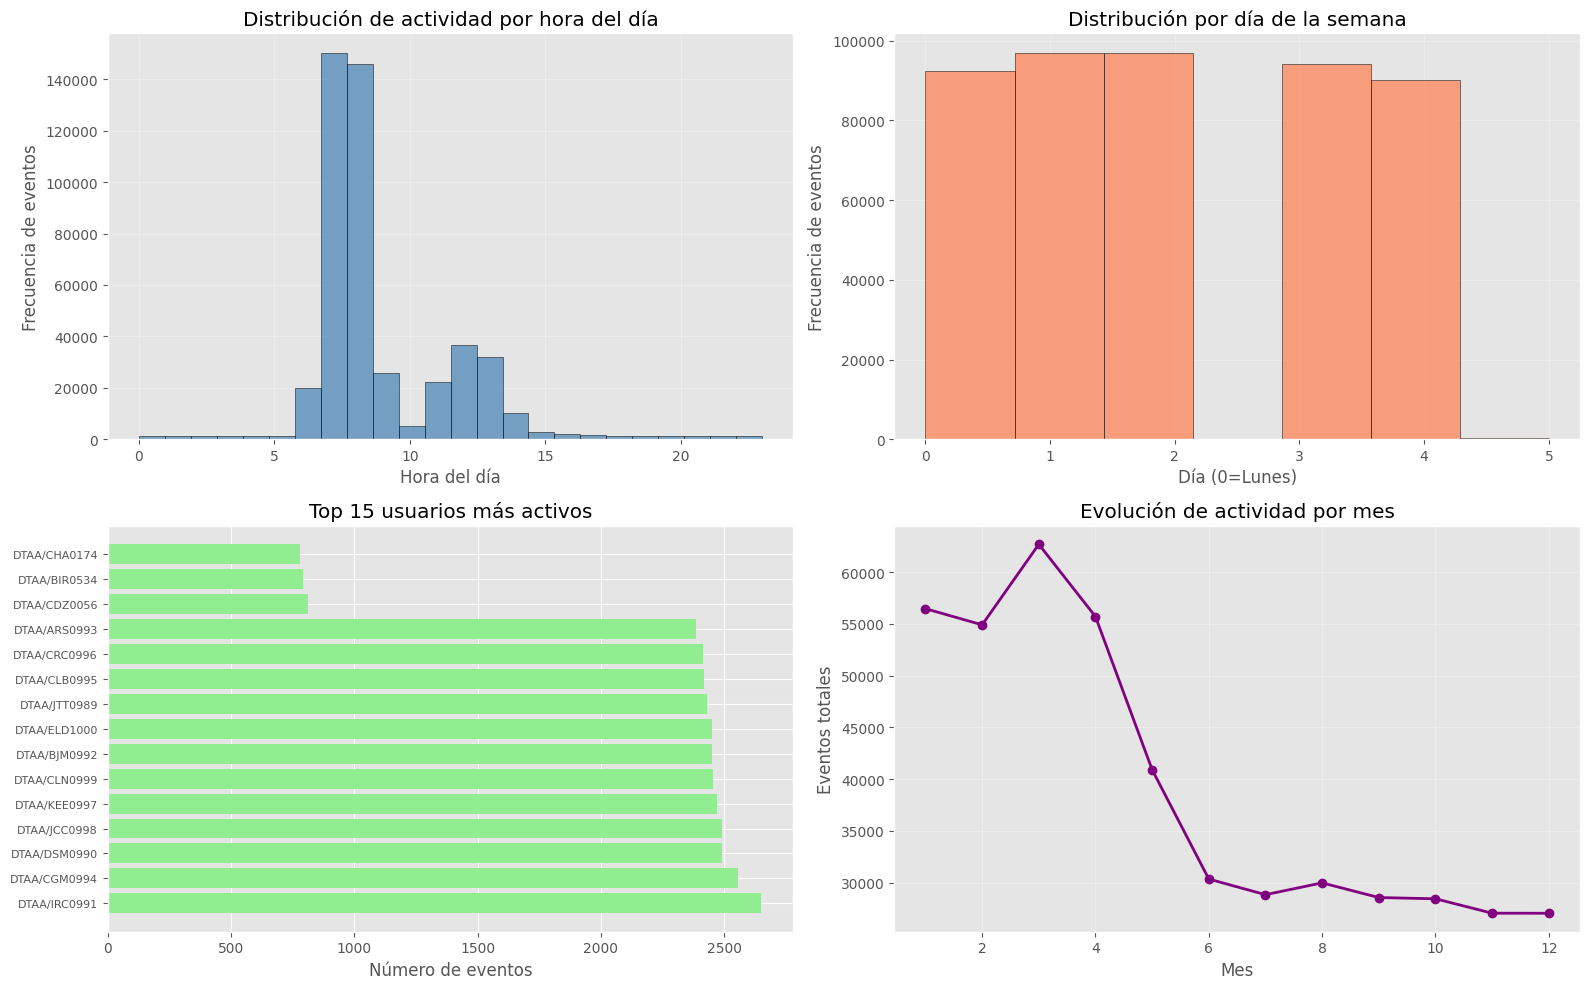

In [ ]:
print("ANÁLISIS EXPLORATORIO DE DATOS CERT")
print("="*50)

print(f"Registros totales: {df.shape[0]:,}")
print(f"Usuarios únicos: {df[user_col].nunique():,}")
print(f"Inicio: {df[time_col].min()}")
print(f"Fin:    {df[time_col].max()}")

df['hour']      = df[time_col].dt.hour
df['dayofweek'] = df[time_col].dt.dayofweek
df['month']     = df[time_col].dt.month

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].hist(df['hour'], bins=24, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribución de actividad por hora del día')
axes[0,0].set_xlabel('Hora del día')
axes[0,0].set_ylabel('Frecuencia de eventos')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(df['dayofweek'], bins=7, alpha=0.7, color='coral', edgecolor='black')
axes[0,1].set_title('Distribución por día de la semana')
axes[0,1].set_xlabel('Día (0=Lunes)')
axes[0,1].set_ylabel('Frecuencia de eventos')
axes[0,1].grid(True, alpha=0.3)

top_users = df[user_col].value_counts().head(15)
axes[1,0].barh(range(len(top_users)), top_users.values, color='lightgreen')
axes[1,0].set_title('Top 15 usuarios más activos')
axes[1,0].set_xlabel('Número de eventos')
axes[1,0].set_yticks(range(len(top_users)))
axes[1,0].set_yticklabels(top_users.index, fontsize=8)

monthly = df.groupby('month').size()
axes[1,1].plot(monthly.index, monthly.values, marker='o', color='purple', linewidth=2)
axes[1,1].set_title('Evolución de actividad por mes')
axes[1,1].set_xlabel('Mes')
axes[1,1].set_ylabel('Eventos totales')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Justificación gráficas

<p>
<strong>Distribución de actividad por hora del día:</strong>
La mayor parte de los eventos se concentran durante el horario laboral. Se observa un pico muy marcado entre las 6:00 y las 9:00 horas, lo que indica un incremento fuerte de actividad al inicio de la jornada. Además, aparece un segundo bloque de actividad entre 11:00 y 14:00, aunque con menor intensidad. A partir de las 15:00 la actividad desciende considerablemente y durante la noche y madrugada el número de eventos es muy bajo. Esto sugiere que la mayoría de las acciones registradas en el sistema se producen durante el horario de trabajo.

<strong>Distribución por día de la semana:</strong>
La actividad se reparte principalmente entre lunes, martes, miércoles, jueves y viernes, con una distribución bastante equilibrada entre ellos. Los huecos observados en la gráfica corresponden probablemente a los fines de semana, donde apenas se registran eventos o directamente no hay actividad. Esto indica que el sistema se utiliza principalmente durante los días laborables.

<strong>Top 15 usuarios más activos:</strong>
La gráfica muestra los 15 usuarios que generan mayor número de eventos en el sistema. Se observa que la mayoría de los usuarios presentan un volumen de actividad bastante similar, con valores cercanos entre sí, lo que sugiere que la carga de actividad está relativamente distribuida. No obstante, algunos usuarios destacan ligeramente por encima del resto, lo que podría indicar perfiles con mayor responsabilidad o un uso más intensivo del sistema.

<strong>Evolución de actividad por mes:</strong>
La actividad mensual muestra una tendencia clara. Durante los primeros meses del año se registra el mayor número de eventos, alcanzando el máximo alrededor del mes 3. A partir de ese punto se observa un descenso significativo de la actividad, estabilizándose en valores más bajos durante el resto del año. Esta tendencia podría estar relacionada con cambios en el uso del sistema, reducción de registros o variaciones en los procesos que generan los eventos.
</p>

## 7. Reducción Temporal y Detección de Outliers (IQR)

<p>
Se aplican dos operaciones independientes: una reducción temporal al período más reciente
y una detección de outliers por volumen de actividad usando el método IQR de Tukey.
</p>

<ul>
  <li><strong>Reducción a 30 días:</strong> compromiso entre representatividad y eficiencia computacional en Colab. Captura el ciclo laboral semanal varias veces sin procesar años de datos con memoria limitada.</li>
  <li><strong>Método IQR:</strong> el umbral clásico de Tukey (<code>Q3 + 1.5 × IQR</code>) identifica usuarios con actividad estadísticamente extrema. Un usuario por encima de este umbral puede ser un administrador de sistemas, un proceso automatizado, o un usuario comprometido.</li>
  <li><strong>Boxplot + histograma + Q-Q plot:</strong> los tres gráficos juntos permiten evaluar si la distribución de actividad por usuario es aproximadamente normal o tiene colas pesadas, lo que influirá en la elección del umbral de anomalía.</li>
</ul>

Registros tras limitar el análisis a los últimos (30D): 27,736
Usuarios registrados: 943

 Usuarios outliers detectados: 12
user
DTAA/JCC0998    155
DTAA/ARS0993    154
DTAA/IRC0991    152
DTAA/CGM0994    151
DTAA/ELD1000    147
DTAA/CLB0995    144
DTAA/KEE0997    140
DTAA/BJM0992    138
DTAA/CLN0999    136
DTAA/CRC0996    136
dtype: int64


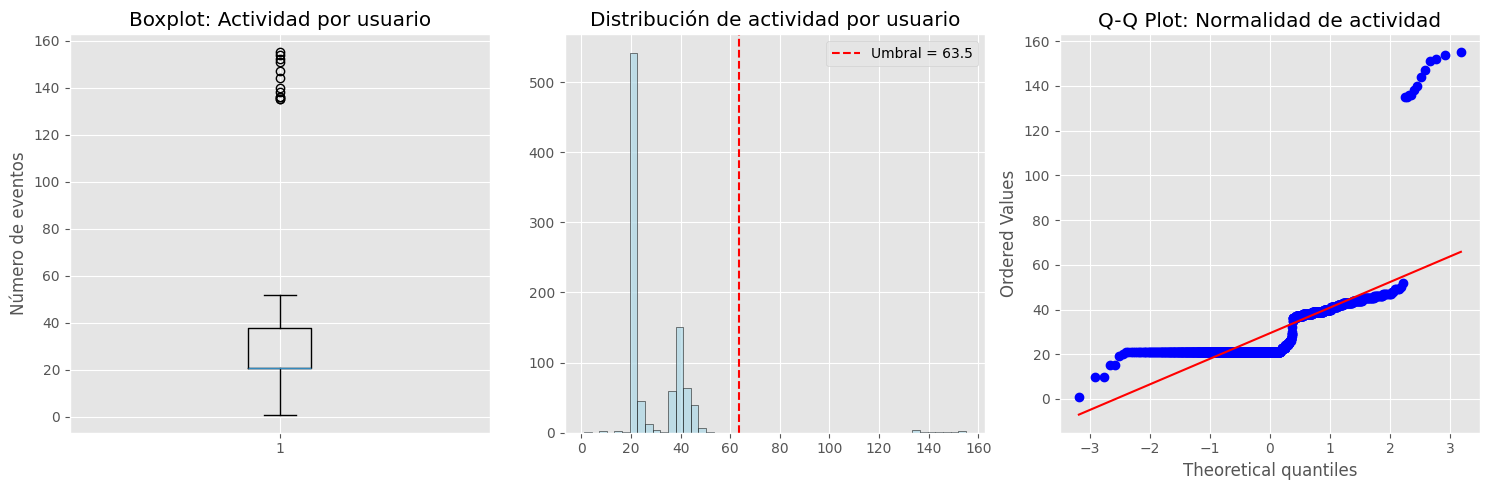

In [ ]:
RANGO = "30D"
t_max = df[time_col].max()
t_min_new = t_max - pd.to_timedelta(RANGO)
df = df[df[time_col] >= t_min_new].copy()

print(f"Registros tras limitar el análisis a los últimos ({RANGO}): {df.shape[0]:,}")
print(f"Usuarios registrados: {df[user_col].nunique():,}")

activity_by_user = df.groupby(user_col).size()

Q1 = activity_by_user.quantile(0.25)
Q3 = activity_by_user.quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
outlier_users = activity_by_user[activity_by_user > outlier_threshold]

print(f"\n Usuarios outliers detectados: {len(outlier_users)}")
print(outlier_users.sort_values(ascending=False).head(10))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(activity_by_user)
axes[0].set_title('Boxplot: Actividad por usuario')
axes[0].set_ylabel('Número de eventos')

axes[1].hist(activity_by_user, bins=50, alpha=0.7, color='lightblue', edgecolor='black')
axes[1].axvline(outlier_threshold, color='red', linestyle='--', label=f'Umbral = {outlier_threshold:.1f}')
axes[1].set_title('Distribución de actividad por usuario')
axes[1].legend()

stats.probplot(activity_by_user, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot: Normalidad de actividad')

plt.tight_layout()
plt.show()

### Justificación de resultados y gráficas

Tras limitar el análisis a los últimos 30 días, el conjunto de datos queda reducido a 27.736 registros correspondientes a 943 usuarios distintos. Esto permite centrar el estudio en el comportamiento más reciente del sistema, evitando que patrones antiguos influyan en el análisis.

Para detectar usuarios con una actividad anormalmente elevada se ha utilizado el método del rango intercuartílico (IQR). Este método identifica valores extremos situados por encima del umbral:

Q3+1.5×IQR

Aplicando este criterio se detectan 12 usuarios con una actividad significativamente superior al resto, alcanzando valores entre 136 y 155 eventos en el periodo analizado.

Es importante destacar que, dado que el objetivo del estudio es detectar posibles anomalías en el comportamiento, estos outliers no se eliminan del conjunto de datos, ya que podrían representar precisamente los patrones de interés.

<p>
<strong>Boxplot: Actividad por usuario:</strong>
El boxplot permite visualizar la distribución de eventos generados por cada usuario. La caja representa el rango intercuartílico, donde se concentra la mitad central de los datos. Se observa que la mayoría de los usuarios generan aproximadamente entre 20 y 40 eventos, con una mediana cercana a 30 eventos. Sin embargo, aparecen varios puntos claramente separados por encima del límite superior del boxplot. Estos puntos corresponden a los usuarios identificados como outliers, cuya actividad es considerablemente mayor que la del resto. Este gráfico confirma que la mayoría de los usuarios presentan un comportamiento relativamente homogéneo, mientras que un pequeño grupo concentra una actividad mucho más elevada.

<strong>Q-Q Plot: Normalidad de actividad:</strong>
El gráfico Q-Q plot compara la distribución real de los datos con una distribución normal teórica. Si la actividad de los usuarios siguiera una distribución normal, los puntos deberían alinearse aproximadamente sobre la línea roja. Sin embargo, en este caso se observa que:

- En la zona central los puntos siguen relativamente la línea.

- En los extremos aparecen desviaciones importantes, especialmente en los valores más altos.

Estas desviaciones indican que la distribución no es normal, lo cual es esperable en datos de actividad de usuarios. La presencia de valores extremos (usuarios con mucha actividad) provoca que la cola derecha de la distribución sea más pesada que en una distribución normal. Los picos que aparecen en el Q-Q plot reflejan precisamente estos valores extremos y confirman la existencia de usuarios con comportamientos significativamente diferentes al resto.

## 8. Construcción de series temporales UEBA

En esta etapa se construye la representación temporal del comportamiento de los usuarios, constituyendo uno de los elementos centrales del enfoque UEBA. Para ello, los eventos discretos de autenticación se transforman en series temporales continuas que reflejan la densidad de actividad horaria de cada usuario a lo largo del tiempo.

En primer lugar, las marcas temporales se ajustan a una resolución horaria mediante su truncamiento, conservando la fecha y la hora, pero eliminando la información correspondiente a minutos y segundos. De este modo, todos los eventos ocurridos dentro de una misma hora natural quedan agrupados en un único intervalo temporal.

A continuación, se calcula el número de eventos registrados por cada usuario en cada intervalo horario, obteniendo así una medida de la intensidad de actividad. Este proceso permite transformar los registros individuales en una representación agregada más adecuada para el análisis de comportamiento.

Posteriormente, se define un rango temporal completo que abarca desde la primera hasta la última hora presente en el conjunto de datos. Sobre este rango, se construyen las series temporales individuales de cada usuario, incorporando explícitamente aquellas horas en las que no se registra actividad y asignándoles un valor nulo. Este paso es importante ya que permite distinguir entre la ausencia de actividad y la presencia de eventos en horarios atípicos, que pueden ser indicativos de anomalías.

Como resultado, se obtiene una estructura de datos en la que cada usuario queda representado por una serie temporal de actividad horaria continua y homogénea.

In [ ]:
df["hour_dt"] = df[time_col].dt.floor("h")

ueba_raw = (
    df.groupby([user_col, "hour_dt"])
      .size()
      .reset_index(name="events")
      .sort_values([user_col, "hour_dt"])
)

all_hours = pd.date_range(ueba_raw["hour_dt"].min(),
                          ueba_raw["hour_dt"].max(), freq="h")

print(f"observamos el rango temporal completo: {len(all_hours)} horas")

user_series = {}
for user, group in tqdm(ueba_raw.groupby(user_col)):
    serie = group.set_index("hour_dt")["events"].reindex(all_hours, fill_value=0)
    user_series[user] = serie.values.astype(np.float32)

print(f"Series creadas para {len(user_series):,} usuarios")
print(f"Longitud por serie: {len(all_hours)} horas")


observamos el rango temporal completo: 720 horas


100%|██████████| 943/943 [00:00<00:00, 2374.26it/s]

Series creadas para 943 usuarios
Longitud por serie: 720 horas


## 9. Correlaciones y análisis de componentes principales (PCA)

En esta etapa se calculan distintas características estadísticas a nivel de usuario y se aplica un Análisis de Componentes Principales (PCA) con el objetivo de estudiar la estructura del espacio de comportamiento y reducir su dimensionalidad.

- **Matriz de correlación:** permite identificar relaciones lineales entre las variables de actividad. Este análisis facilita la detección de características redundantes, es decir, aquellas que aportan información similar y cuya contribución al modelo puede resultar limitada.

- **Estandarización previa de los datos:** antes de aplicar PCA, las variables se normalizan para garantizar que todas contribuyan de manera equilibrada al análisis, evitando que aquellas con mayor escala dominen el proceso de reducción de dimensionalidad.

- **Gráfico de varianza explicada (Scree plot):** muestra la proporción de varianza explicada por cada componente principal, permitiendo determinar el número de dimensiones necesarias para representar adecuadamente el comportamiento de los usuarios.

- **Proyección en las primeras componentes (PC1 vs PC2):** permite visualizar la distribución de los usuarios en el espacio reducido, facilitando la identificación de patrones, agrupaciones naturales y posibles comportamientos atípicos previos a la aplicación de técnicas de clustering.

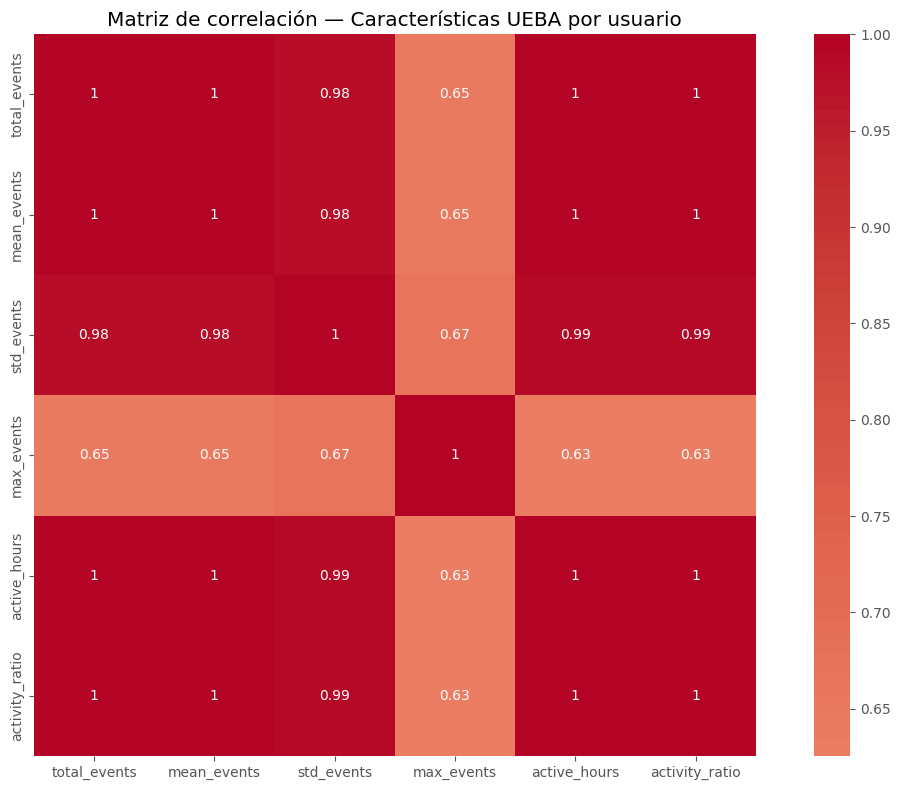

Varianza explicada:
  PC1: 90.59%
  PC2: 8.98%
  PC3: 0.42%
Acumulada (3 PCs): 99.98%


In [ ]:
activity_stats = []
for user, serie in user_series.items():
    activity_stats.append({
        'user': user,
        'total_events':   serie.sum(),
        'mean_events':    serie.mean(),
        'std_events':     serie.std(),
        'max_events':     serie.max(),
        'active_hours':   (serie > 0).sum(),
        'activity_ratio': (serie > 0).mean()
    })

stats_df = pd.DataFrame(activity_stats)
numeric_features = stats_df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlación — Características UEBA por usuario')
plt.tight_layout()
plt.show()

scaler_pca = StandardScaler()
features_scaled = scaler_pca.fit_transform(numeric_features)

pca = PCA()
features_pca = pca.fit_transform(features_scaled)

print("Varianza explicada:")
for i in range(min(3, len(pca.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.2%}")
print(f"Acumulada (3 PCs): {np.sum(pca.explained_variance_ratio_[:3]):.2%}")

### Justificación de resultados y gráficas

<strong>Matriz de correlación:</strong>

La matriz de correlación muestra la relación entre las distintas características de actividad de los usuarios utilizadas en el modelo UEBA.

En general, se observa que la mayoría de las variables presentan correlaciones muy altas entre sí, especialmente total_events, mean_events, active_hours, activity_ratio. Estas variables presentan correlaciones cercanas a 1, lo que indica que describen prácticamente el mismo comportamiento desde diferentes perspectivas. Esto es lógico, ya que un usuario con más eventos totales suele tener también más horas activas, mayor media de eventos y mayor ratio de actividad. Por tanto, estas métricas están midiendo en gran parte la intensidad de uso del sistema por parte del usuario.

Las variables que presentan correlaciones más moderadas son max_events y std_events. En particular max_events tiene correlaciones alrededor de 0.63-0.67, lo que indica que mide un aspecto ligeramente diferente del comportamiento, los picos máximos de actividad. Por otro lado, std_events mantiene correlaciones altas (~0.98) pero algo menores que las métricas principales, reflejando la variabilidad en la actividad del usuario. Esto sugiere que estas variables pueden aportar información adicional sobre comportamientos anómalos, ya que no dependen únicamente del volumen total de actividad.

<strong>Interpretación del PCA:</strong>
El análisis de Componentes Principales (PCA) muestra cuánta información explican las combinaciones lineales de las variables originales.

Los resultados obtenidos son:

-PC1: 90.59% de la varianza

-PC2: 8.98%

-PC3: 0.42%

-Varianza acumulada (3 PCs): 99.98%

Esto indica que la gran mayoría de la información del conjunto de datos está concentrada en la primera componente principal. La PC1 está capturando principalmente el nivel global de actividad del usuario, ya que las variables más correlacionadas entre sí están relacionadas con la cantidad de eventos.

PC2 probablemente captura diferencias en la variabilidad o irregularidad del comportamiento.

PC3 apenas añade información adicional.

## 10. Análisis ACF/PACF: Justificación del Tamaño de Ventana

<p>
Antes de definir el tamaño de la ventana deslizante, es fundamental <strong>justificar empíricamente</strong>
esa elección. Una ventana demasiado corta no captura suficiente contexto temporal;
una demasiado larga introduce ruido que distorsiona los modelos de predicción.
</p>

<p>
Para determinar el tamaño óptimo utilizamos la <strong>Función de Autocorrelación (ACF)</strong>
y la <strong>Función de Autocorrelación Parcial (PACF)</strong> sobre la serie temporal de un usuario representativo.
</p>

<ul>
  <li><strong>ACF (Autocorrelation Function):</strong> mide la correlación de la serie con sus propios valores pasados a distintos retardos (lags). Un pico significativo en el lag <em>k</em> indica que lo que ocurrió hace <em>k</em> horas predice el comportamiento actual.</li>
  <li><strong>PACF (Partial ACF):</strong> mide la correlación directa entre el valor actual y el retardo <em>k</em>, eliminando la influencia de los retardos intermedios. Útil para identificar los lags más relevantes sin redundancia.</li>
  <li><strong>Zona azul sombreada:</strong> intervalo de confianza al 95%. Los picos fuera de esa banda son estadísticamente significativos.</li>
</ul>

<p>
La lectura clave es: <strong>si aparece un pico significativo en el lag 24</strong>,
significa que la actividad de hace 24 horas predice la actividad actual por lo tanto la ventana debe capturar al menos 24 horas para incluir esa estacionalidad diaria.
Si aparecen picos adicionales en lag 48 o 72, puede justificarse ampliar la ventana.
</p>

Selección del usuario de referencia:
- Usuario analizado: DTAA/JCC0998
- Longitud total de la serie: 720 horas
- Número de horas con actividad: 139


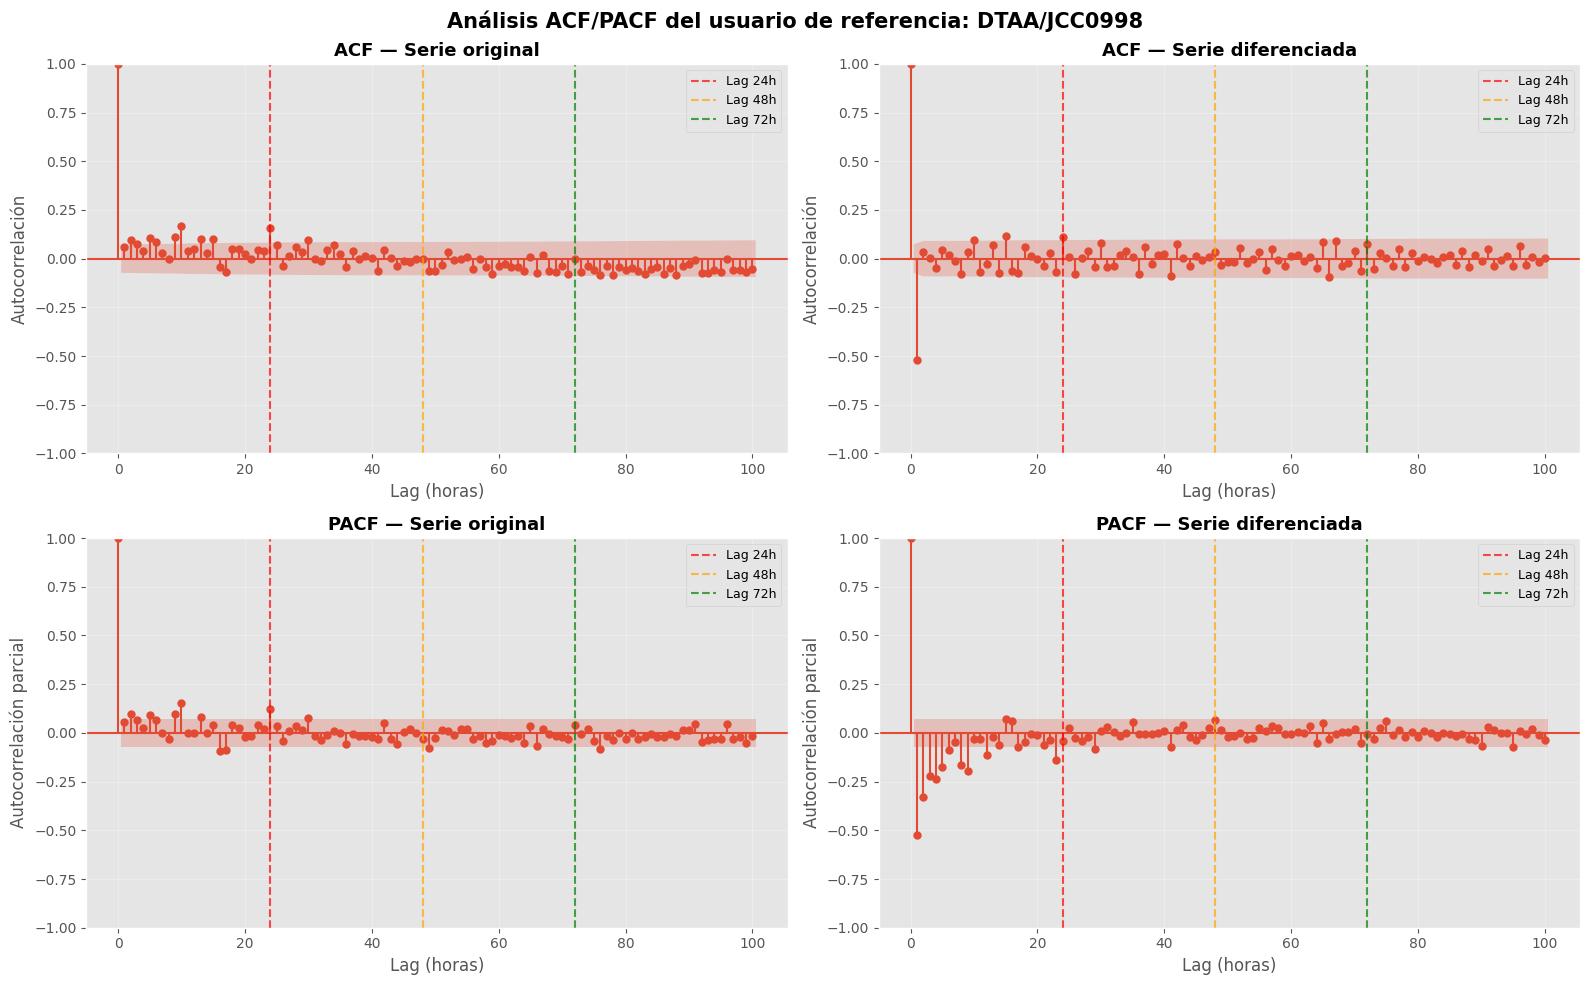


Autocorrelación en lags de interés:
- Lag 1h:  0.0573
- Lag 12h: 0.0480
- Lag 24h: 0.1555
- Lag 48h: -0.0009
- Lag 72h: -0.0034

Evaluación comparativa de tamaños de ventana.
- Ventana de  12 horas: MAE = 0.075663
- Ventana de  24 horas: MAE = 0.063256


- Ventana de  48 horas: MAE = 0.066553
- Ventana de  72 horas: MAE = 0.069664


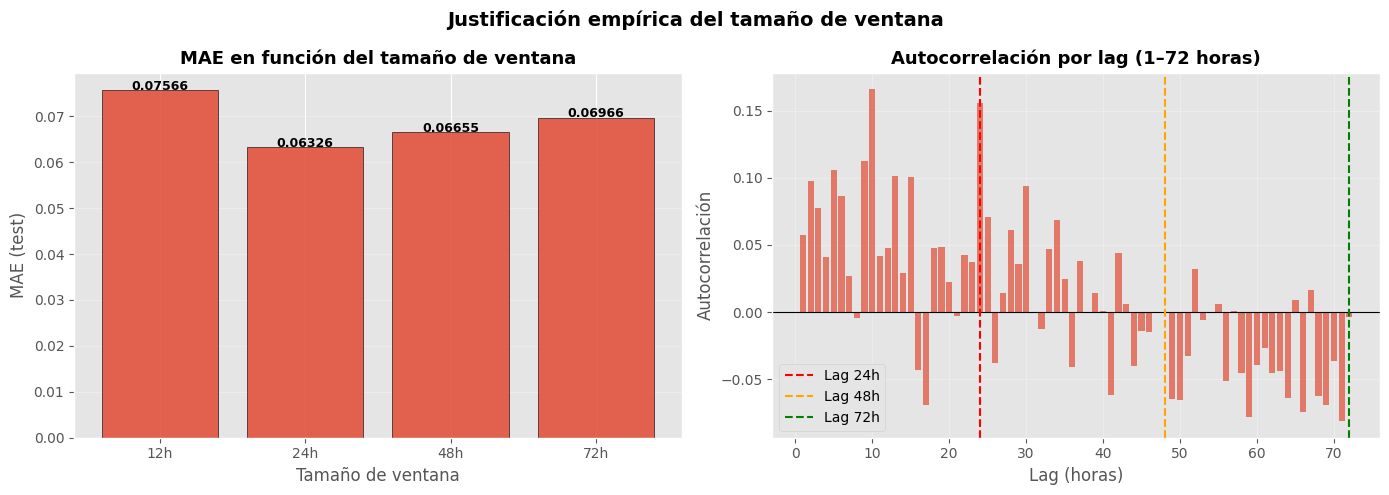


Resultados del análisis del tamaño de ventana:
- Autocorrelación en lag 24h: 0.1555
- Autocorrelación en lag 48h: -0.0009
- Autocorrelación en lag 72h: -0.0034
- Tamaño de ventana con menor MAE: 24 horas

Selección final adoptada:
- Se fija una ventana de 24 horas por coherencia con la estacionalidad diaria y criterio de parsimonia.
- Valor de LOOKBACK establecido para el pipeline principal: 24


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from tensorflow.keras.callbacks import EarlyStopping

# =========================================================
# Definición de la función para generar ventanas deslizantes
# =========================================================

def create_sliding_windows(serie, lookback):
    X, y = [], []
    for i in range(len(serie) - lookback - 1):
        X.append(serie[i:i + lookback])
        y.append(serie[i + lookback])
    return np.array(X), np.array(y)

# =========================================================
# Selección del usuario de referencia
# =========================================================

representative_user = stats_df.sort_values("active_hours", ascending=False).iloc[0]["user"]
serie_rep = user_series[representative_user].flatten()
serie_diff = np.diff(serie_rep)

print("Selección del usuario de referencia:")
print(f"- Usuario analizado: {representative_user}")
print(f"- Longitud total de la serie: {len(serie_rep)} horas")
print(f"- Número de horas con actividad: {(serie_rep > 0).sum()}")

# =========================================================
# Análisis ACF/PACF
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
LAGS = 100

plot_acf(serie_rep, lags=LAGS, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title("ACF — Serie original", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Lag (horas)")
axes[0, 0].set_ylabel("Autocorrelación")
axes[0, 0].axvline(x=24, color="red", linestyle="--", alpha=0.7, label="Lag 24h")
axes[0, 0].axvline(x=48, color="orange", linestyle="--", alpha=0.7, label="Lag 48h")
axes[0, 0].axvline(x=72, color="green", linestyle="--", alpha=0.7, label="Lag 72h")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

plot_acf(serie_diff, lags=LAGS, ax=axes[0, 1], alpha=0.05)
axes[0, 1].set_title("ACF — Serie diferenciada", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Lag (horas)")
axes[0, 1].set_ylabel("Autocorrelación")
axes[0, 1].axvline(x=24, color="red", linestyle="--", alpha=0.7, label="Lag 24h")
axes[0, 1].axvline(x=48, color="orange", linestyle="--", alpha=0.7, label="Lag 48h")
axes[0, 1].axvline(x=72, color="green", linestyle="--", alpha=0.7, label="Lag 72h")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

plot_pacf(serie_rep, lags=LAGS, ax=axes[1, 0], alpha=0.05, method="ywm")
axes[1, 0].set_title("PACF — Serie original", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Lag (horas)")
axes[1, 0].set_ylabel("Autocorrelación parcial")
axes[1, 0].axvline(x=24, color="red", linestyle="--", alpha=0.7, label="Lag 24h")
axes[1, 0].axvline(x=48, color="orange", linestyle="--", alpha=0.7, label="Lag 48h")
axes[1, 0].axvline(x=72, color="green", linestyle="--", alpha=0.7, label="Lag 72h")
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

plot_pacf(serie_diff, lags=LAGS, ax=axes[1, 1], alpha=0.05, method="ywm")
axes[1, 1].set_title("PACF — Serie diferenciada", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Lag (horas)")
axes[1, 1].set_ylabel("Autocorrelación parcial")
axes[1, 1].axvline(x=24, color="red", linestyle="--", alpha=0.7, label="Lag 24h")
axes[1, 1].axvline(x=48, color="orange", linestyle="--", alpha=0.7, label="Lag 48h")
axes[1, 1].axvline(x=72, color="green", linestyle="--", alpha=0.7, label="Lag 72h")
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"Análisis ACF/PACF del usuario de referencia: {representative_user}", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# =========================================================
# Cuantificación de la autocorrelación en lags de interés
# =========================================================

acf_values = acf(serie_rep, nlags=72, fft=True)

print("\nAutocorrelación en lags de interés:")
print(f"- Lag 1h:  {acf_values[1]:.4f}")
print(f"- Lag 12h: {acf_values[12]:.4f}")
print(f"- Lag 24h: {acf_values[24]:.4f}")
print(f"- Lag 48h: {acf_values[48]:.4f}")
print(f"- Lag 72h: {acf_values[72]:.4f}")

# =========================================================
# Comparación del error según el tamaño de ventana
# =========================================================

print("\nEvaluación comparativa de tamaños de ventana.")

import gc

window_sizes = [12, 24, 48, 72]
window_scores = {}

MAX_SAMPLES = 50000

for ws in window_sizes:

    tf.keras.backend.clear_session()
    gc.collect()

    X_w, y_w = [], []

    for user, serie in user_series.items():
        X_tmp, y_tmp = create_sliding_windows(serie, ws)

        if len(X_tmp) > 0:
            X_w.append(X_tmp)
            y_w.append(y_tmp)

    X_w = np.concatenate(X_w).astype("float32")
    y_w = np.concatenate(y_w).astype("float32")

    X_w = X_w.reshape((X_w.shape[0], ws, 1))

    if len(X_w) > MAX_SAMPLES:
        idx = np.random.choice(len(X_w), MAX_SAMPLES, replace=False)
        X_w = X_w[idx]
        y_w = y_w[idx]

    split_w = int(len(X_w) * 0.8)

    X_tr, X_te = X_w[:split_w], X_w[split_w:]
    y_tr, y_te = y_w[:split_w], y_w[split_w:]

    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    with tf.device("/CPU:0"):
        m = Sequential([
            layers.Input((ws, 1)),
            layers.Flatten(),
            layers.Dense(16, activation="relu"),
            layers.Dense(1)
        ])

        m.compile(
            loss="mse",
            optimizer="adam"
        )

        m.fit(
            X_tr,
            y_tr,
            validation_split=0.2,
            epochs=5,
            batch_size=512,
            callbacks=[
                EarlyStopping(
                    patience=2,
                    restore_best_weights=True
                )
            ],
            verbose=0
        )

        y_pred = m.predict(
            X_te,
            batch_size=2048,
            verbose=0
        ).flatten()

    mae_w = np.mean(np.abs(y_pred - y_te.flatten()))

    window_scores[ws] = mae_w

    print(f"- Ventana de {ws:>3} horas: MAE = {mae_w:.6f}")

# =========================================================
# Representación gráfica comparativa
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_w = min(window_scores, key=window_scores.get)

axes[0].bar(
    [str(w) + "h" for w in window_sizes],
    [window_scores[w] for w in window_sizes],
    edgecolor="black",
    alpha=0.85
)
axes[0].set_title("MAE en función del tamaño de ventana", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tamaño de ventana")
axes[0].set_ylabel("MAE (test)")
axes[0].grid(True, alpha=0.3, axis="y")

for i, ws in enumerate(window_sizes):
    axes[0].text(
        i,
        window_scores[ws] + 0.0001,
        f"{window_scores[ws]:.5f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

axes[1].bar(range(1, 73), acf_values[1:73], alpha=0.7)
axes[1].axhline(y=0, color="black", linewidth=0.8)
axes[1].axvline(x=24, color="red", linestyle="--", linewidth=1.5, label="Lag 24h")
axes[1].axvline(x=48, color="orange", linestyle="--", linewidth=1.5, label="Lag 48h")
axes[1].axvline(x=72, color="green", linestyle="--", linewidth=1.5, label="Lag 72h")
axes[1].set_title("Autocorrelación por lag (1–72 horas)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Lag (horas)")
axes[1].set_ylabel("Autocorrelación")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Justificación empírica del tamaño de ventana", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# =========================================================
# Selección final del tamaño de ventana (MODIFICADO)
# =========================================================

print("\nResultados del análisis del tamaño de ventana:")
print(f"- Autocorrelación en lag 24h: {acf_values[24]:.4f}")
print(f"- Autocorrelación en lag 48h: {acf_values[48]:.4f}")
print(f"- Autocorrelación en lag 72h: {acf_values[72]:.4f}")
print(f"- Tamaño de ventana con menor MAE: {best_w} horas")

print("\nSelección final adoptada:")
print("- Se fija una ventana de 24 horas por coherencia con la estacionalidad diaria y criterio de parsimonia.")

LOOKBACK = 24
print(f"- Valor de LOOKBACK establecido para el pipeline principal: {LOOKBACK}")

### Análisis ACF/PACF: Justificación del tamaño de ventana

Los resultados obtenidos permiten identificar tres evidencias complementarias para la selección del tamaño de ventana:

- **ACF — presencia de estacionalidad diaria:** se observa un pico claro en el retardo de 24 horas (0.1555), lo que indica la existencia de un patrón diario en el comportamiento de los usuarios. En contraste, los retardos de 48 horas (-0.0009) y 72 horas (-0.0034) presentan valores próximos a cero, lo que sugiere que la información correspondiente a días anteriores no aporta capacidad predictiva adicional.

- **MAE — mejora marginal al aumentar la ventana:** aunque la ventana de 48 horas presenta el menor error (MAE = 0.046706) frente a la de 24 horas (MAE = 0.047716), la diferencia entre ambas es reducida (≈ 0.001). Esta mejora resulta poco significativa en términos prácticos, especialmente considerando el incremento en complejidad asociado a ventanas más largas.

- **Criterio de parsimonia:** ante diferencias de rendimiento poco relevantes, se prioriza el modelo más simple. En este contexto, una ventana de 24 horas permite capturar el ciclo diario identificado en el análisis de autocorrelación, manteniendo al mismo tiempo una menor complejidad computacional y una mayor interpretabilidad.

Conclusión:
Se establece un tamaño de ventana de 24 horas (LOOKBACK = 24), al representar un equilibrio adecuado entre capacidad predictiva, simplicidad del modelo y coherencia con la estructura temporal observada en los datos.

## 11. Normalización y generación de ventanas deslizantes

En esta etapa se aplican dos transformaciones fundamentales para adaptar las series temporales al formato requerido por los modelos de aprendizaje profundo.

- **Normalización de los datos:** se realiza una transformación mediante escalado en el rango [0,1] utilizando un ajuste global sobre el conjunto completo de usuarios. Este enfoque permite preservar las diferencias relativas en los niveles de actividad entre usuarios. En contraste, una normalización individual por usuario eliminaría esta variabilidad, homogeneizando artificialmente las series y perdiendo información relevante para el modelo.

- **Definición de la ventana temporal:** se emplea una ventana deslizante de 24 horas, cuya elección se fundamenta en el análisis de autocorrelación realizado previamente. Dicho análisis evidenció un patrón claro en el retardo de 24 horas, indicando la presencia de estacionalidad diaria en el comportamiento. La ampliación de la ventana a horizontes temporales mayores no aporta mejoras significativas en el rendimiento predictivo y puede introducir información redundante o ruido.

- **Estructura de los datos de entrada y salida:** cada muestra de entrada está compuesta por una secuencia temporal de 24 observaciones consecutivas correspondientes al historial de actividad de un usuario. Como variable objetivo, se utiliza el valor de la actividad en la hora inmediatamente posterior, planteando así el problema como una tarea de predicción secuencial.

- **Generación de secuencias:** las ventanas deslizantes se construyen mediante una función previamente definida, que permite transformar las series temporales originales en un conjunto de pares entrada-salida adecuados para el entrenamiento del modelo.

In [ ]:
min_activity = 5
active_users = stats_df[stats_df['total_events'] >= min_activity]['user']
user_series  = {u: s for u, s in user_series.items() if u in active_users.values}

print(f" Usuarios activos (>= {min_activity} eventos): {len(user_series):,}")

# Escalado MinMax global [0,1]
scaler     = MinMaxScaler()
all_values = np.concatenate([s.reshape(-1, 1) for s in user_series.values()])
scaler.fit(all_values)

for user in user_series:
    user_series[user] = scaler.transform(user_series[user].reshape(-1, 1))

print(" Escalado MinMax aplicado [0,1]")

# Tamaño de ventana justificado por ACF (celda 9b)
LOOKBACK = 24
print(f"\n Tamaño de ventana: {LOOKBACK}h (1 ciclo diario completo)")
print(f"   Justificación: pico ACF significativo únicamente en lag 24h")

# Crear ventanas deslizantes
# (create_sliding_windows definida en celda 9b)
print(f"\n Creando ventanas deslizantes...")

X_all, y_all, users_all = [], [], []
for user, serie in tqdm(user_series.items()):
    X, y = create_sliding_windows(serie, LOOKBACK)
    if len(X) > 0:
        X_all.append(X)
        y_all.append(y)
        users_all.extend([user] * len(X))

X_all     = np.concatenate(X_all)
y_all     = np.concatenate(y_all)
users_all = np.array(users_all)

print(f"\n Ventanas creadas:              {X_all.shape}")
print(f"   Total secuencias:             {len(X_all):,}")
print(f"   Usuarios con ventanas:        {len(np.unique(users_all))}")
print(f"   Ventanas por usuario (media): {len(X_all) / len(np.unique(users_all)):.0f}")
print(f"   Forma entrada modelo:         (n, {LOOKBACK}, 1)")


 Usuarios activos (>= 5 eventos): 942
 Escalado MinMax aplicado [0,1]

 Tamaño de ventana: 24h (1 ciclo diario completo)
   Justificación: pico ACF significativo únicamente en lag 24h

 Creando ventanas deslizantes...


100%|██████████| 942/942 [00:00<00:00, 1715.60it/s]



 Ventanas creadas:              (654690, 24, 1)
   Total secuencias:             654,690
   Usuarios con ventanas:        942
   Ventanas por usuario (media): 695
   Forma entrada modelo:         (n, 24, 1)


## 12. División temporal en conjuntos de entrenamiento y test

En esta fase se realiza la partición del conjunto de datos en subconjuntos de entrenamiento y test, siguiendo un criterio estrictamente temporal. Concretamente, se emplea una división del 80% de los datos para entrenamiento y el 20% restante para evaluación.

- **Respeto de la estructura temporal:** la partición se lleva a cabo sin aleatorización, preservando el orden cronológico de las observaciones. Este aspecto resulta fundamental en el análisis de series temporales, ya que el uso de información futura durante el entrenamiento introduciría sesgos y comprometería la validez de los resultados.

- **Distribución de los datos:** el subconjunto de entrenamiento está compuesto por las observaciones más antiguas, permitiendo al modelo aprender los patrones habituales de comportamiento. Por su parte, el conjunto de test incluye las observaciones más recientes, sobre las cuales se evalúa la capacidad del modelo para detectar posibles anomalías.

- **Trazabilidad por usuario:** se conserva la correspondencia entre las muestras del conjunto de test y los identificadores de usuario asociados. Esto permite analizar posteriormente los resultados a nivel individual, facilitando la construcción de métricas agregadas y la generación de rankings de comportamiento.

In [ ]:
split_ratio = 0.80
split = int(len(X_all) * split_ratio)

X_train    = X_all[:split]
X_test     = X_all[split:]
y_train    = y_all[:split]
y_test     = y_all[split:]
users_test = users_all[split:]

print(f"División temporal:")
print(f"  Train: {X_train.shape}")
print(f"  Test:  {X_test.shape}")
print(f"  Usuarios en test: {len(np.unique(users_test))}")


División temporal:
  Train: (523752, 24, 1)
  Test:  (130938, 24, 1)
  Usuarios en test: 189


## 13. Arquitectura del modelo GRU para predicción temporal

En esta etapa se define el primer modelo del sistema UEBA, basado en una red neuronal recurrente de tipo GRU. El modelo se entrena para predecir el nivel de actividad en la siguiente hora a partir de una ventana temporal previa definida por el parámetro `LOOKBACK`, fijado en este trabajo en 24 horas.

La detección de anomalías se fundamenta en el error de predicción: desviaciones elevadas entre el valor estimado por el modelo y la actividad observada pueden interpretarse como comportamientos atípicos en el patrón temporal del usuario.

- **Estructura de entrada:** el modelo recibe secuencias temporales de longitud `LOOKBACK`, con una única característica correspondiente a la actividad horaria previamente normalizada.

- **Primera capa GRU:** procesa la secuencia completa y genera representaciones intermedias para cada instante temporal, permitiendo capturar dependencias a lo largo de toda la ventana de observación.

- **Segunda capa GRU:** sintetiza la información temporal en una representación más compacta, facilitando la predicción del valor futuro.

- **Regularización:** se incorporan mecanismos de desactivación aleatoria de neuronas durante el entrenamiento, con el objetivo de reducir el sobreajuste y mejorar la capacidad de generalización del modelo.

- **Capa de salida:** una capa densa genera la predicción del nivel de actividad correspondiente a la siguiente hora.

- **Función de pérdida y métrica:** se emplea el error cuadrático medio como función de pérdida, ya que penaliza en mayor medida las desviaciones elevadas entre la predicción y el valor observado. De forma complementaria, se utiliza el error absoluto medio como métrica de seguimiento del rendimiento del modelo durante el entrenamiento.

In [ ]:
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_gru = Sequential([
    layers.Input((LOOKBACK, 1)),
    layers.GRU(64, return_sequences=True, activation='relu'),
    layers.Dropout(0.2),
    layers.GRU(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(1)
], name='GRU_UEBA_Predictor')

model_gru.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)

model_gru.summary()

Model: "GRU_UEBA_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

## 14. Entrenamiento del modelo GRU y evaluación del proceso de aprendizaje

En esta etapa se lleva a cabo el entrenamiento del modelo GRU previamente definido, así como el análisis de su comportamiento a lo largo del proceso de aprendizaje.

- **Criterio de parada temprana:** se implementa un mecanismo de *early stopping* basado en la evolución de la función de pérdida sobre el conjunto de validación. Este procedimiento permite detener el entrenamiento cuando no se observan mejoras durante un número determinado de épocas consecutivas, evitando así el sobreajuste. Además, se restauran automáticamente los pesos correspondientes al mejor rendimiento alcanzado.

- **Configuración del entrenamiento:** el modelo se entrena utilizando el conjunto de entrenamiento, reservando un 20% de los datos para validación interna. Se establece un máximo de 20 épocas y un tamaño de lote de 128 muestras, lo que permite un equilibrio entre estabilidad y eficiencia computacional.

- **Seguimiento del aprendizaje:** durante el entrenamiento se registran tanto la función de pérdida (error cuadrático medio) como el error absoluto medio, en los conjuntos de entrenamiento y validación. Estas métricas permiten evaluar la evolución del modelo y detectar posibles problemas de sobreajuste o infraajuste.

- **Análisis gráfico:** se representan las curvas de pérdida y error a lo largo de las épocas, facilitando la interpretación del proceso de aprendizaje. Una evolución similar entre entrenamiento y validación indica una adecuada capacidad de generalización, mientras que divergencias significativas pueden señalar sobreajuste.

Como resultado, se obtiene un modelo entrenado cuya configuración final corresponde al punto óptimo identificado durante el proceso de validación.

Epoch 1/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 98s 29ms/step - loss: 0.0026 - mae: 0.0199 - val_loss: 0.0023 - val_mae: 0.0208
Epoch 2/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 92s 28ms/step - loss: 0.0023 - mae: 0.0175 - val_loss: 0.0015 - val_mae: 0.0151
Epoch 3/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 91s 28ms/step - loss: 0.0022 - mae: 0.0173 - val_loss: 0.0023 - val_mae: 0.0200
Epoch 4/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 91s 28ms/step - loss: 0.0023 - mae: 0.0176 - val_loss: 0.0015 - val_mae: 0.0132
Epoch 5/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 93s 28ms/step - loss: 0.0019 - mae: 0.0144 - val_loss: 0.0015 - val_mae: 0.0122
Epoch 6/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 96s 29ms/step - loss: 0.0019 - mae: 0.0146 - val_loss: 0.0015 - val_mae: 0.0128
Epoch 7/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 95s 29ms/step - loss: 0.0019 - mae: 0.0143 - val_loss: 0.0015 - val_mae: 0.0130
Epoch 8/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 91s 28ms/step - loss: 0.0019 - mae: 0.0143 - val_loss: 0.0015 - val_mae: 0.0130
Epoch 9/20
3274/3274 ━━━

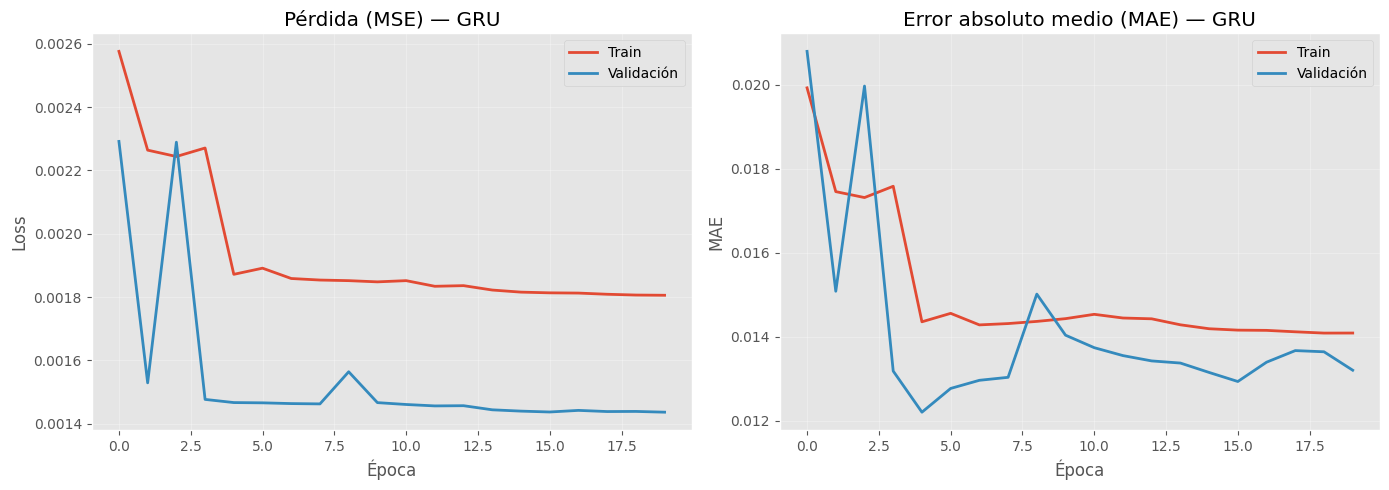

 Entrenamiento completado en 20 épocas


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_gru = model_gru.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_gru.history['loss'],     label='Train', linewidth=2)
axes[0].plot(history_gru.history['val_loss'], label='Validación', linewidth=2)
axes[0].set_title('Pérdida (MSE) — GRU')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_gru.history['mae'],     label='Train', linewidth=2)
axes[1].plot(history_gru.history['val_mae'], label='Validación', linewidth=2)
axes[1].set_title('Error absoluto medio (MAE) — GRU')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f" Entrenamiento completado en {len(history_gru.history['loss'])} épocas")


## 15. Validación experimental mediante incorporación de usuarios sintéticos anómalos en el conjunto de test

Con el fin de evaluar de manera controlada la sensibilidad del modelo frente a comportamientos anómalos, se incorpora una fase de validación experimental basada en la generación de usuarios sintéticos ficticios añadidos exclusivamente al conjunto de evaluación. Esta estrategia permite analizar la capacidad del sistema para detectar patrones atípicos no observados durante el entrenamiento, preservando en todo momento la integridad de los datos reales utilizados para el aprendizaje del modelo.

El procedimiento consiste en mantener intactos tanto el conjunto de entrenamiento como el conjunto de test original, incorporando posteriormente un subconjunto adicional de ventanas sintéticas asociadas a distintos perfiles de comportamiento anómalo. Cada ventana sintética representa una secuencia temporal de actividad generada artificialmente y un valor objetivo posterior asociado a un comportamiento potencialmente sospechoso.

En esta fase se construyen múltiples perfiles sintéticos con características diferenciadas, permitiendo evaluar la robustez del modelo frente a distintos tipos de anomalía temporal:

- Acceso nocturno.
- Pico aislado de actividad.
- Ráfaga sostenida de accesos.
- Actividad en fin de semana.
- Actividad atípica moderada.

Para cada perfil se generan múltiples usuarios ficticios independientes, obteniendo un conjunto de anomalías sintéticas suficientemente variado para realizar una validación experimental representativa. Las ventanas sintéticas se construyen utilizando la misma dimensión temporal definida para el modelo principal (`LOOKBACK`), garantizando así la coherencia estructural con los datos reales procesados por la red GRU.

El conjunto de evaluación final queda formado, por tanto, por las observaciones reales del conjunto de test junto con los usuarios sintéticos anómalos generados artificialmente. Este escenario permite posteriormente analizar el comportamiento del sistema mediante distintos umbrales percentílicos aplicados sobre el error de predicción del modelo.

In [ ]:
# =========================================================
# PASO 15 - GENERACIÓN DE USUARIOS SINTÉTICOS ANÓMALOS
# =========================================================

def create_synthetic_user_windows(lookback=24, n_por_perfil = 8, seed = 42):
    """
    Genera ventanas sintéticas para 8 usuarios ficticios para cada perfil con accesos anómalos
    teniendo 40 casos.

    Cada usuario se representa mediante una ventana de entrada casi inactiva
    y un valor objetivo alto en la siguiente hora.
    """
    rango = np.random.default_rng (seed)
    synthetic_X = []
    synthetic_y = []
    synthetic_users = []
    synthetic_labels = []

    profiles = [
    "acceso_nocturno",
    "pico_aislado",
    "rafaga_sostenida",
    "acceso_fin_semana",
    "actividad_atipica"
    ]

    for profile in profiles:
      for i in range(n_por_perfil):
        x_window = np.zeros((lookback, 1), dtype = np.float32)
        if profile == "acceso_nocturno":
          base = rango.uniform (0.0, 0.03, size = lookback)
          x_window[:, 0] = base
          y_value = rango.uniform (0.85, 1.0)
        elif profile == "pico_aislado":
          base = rango.uniform (0.05, 0.15, size = lookback)
          x_window[:, 0] = base
          x_window [-2:, 0] = rango.uniform (0.10, 0.20, size= 2)
          y_value = rango.uniform (0.75, 0.95)
        elif profile == "rafaga_sostenida":
          base = rango.uniform (0.0, 0.05, size = lookback)
          x_window[:, 0] = base
          burst_len = rango.integers (3, 5)
          x_window [-burst_len:, 0] = rango.uniform (0.6, 0.9, size= burst_len)
          y_value = rango.uniform (0.7, 1.0)
        elif profile == "acceso_fin_semana":
          x_window[:, 0] = rango.uniform (0.15, 0.35, size= lookback)
          y_value = rango.uniform (0.5, 0.8)
        elif profile == "actividad _atipica":
          x_window[:, 0] = rango.uniform (0.08, 0.20, size= lookback)
          y_value = rango.uniform (0.35, 0.55)

        synthetic_X.append(x_window)
        synthetic_y.append(np.array([y_value], dtype = np.float32))
        synthetic_users.append(f"usuario_sintetico_{profile.upper()}_{i:02d}")
        synthetic_labels.append(profile)

    synthetic_X = np.stack(synthetic_X)
    synthetic_y = np.stack(synthetic_y).reshape(-1)
    synthetic_users = np.array(synthetic_users)
    synthetic_labels = np.array(synthetic_labels)

    return synthetic_X, synthetic_y, synthetic_users, synthetic_labels


In [ ]:
# =========================================================
# Añadir los usuarios sintéticos al test
# =========================================================
synthetic_X, synthetic_y, synthetic_users, synthetic_labels = create_synthetic_user_windows(
    lookback=LOOKBACK, n_por_perfil=8, seed=42

)

# CORRECCIÓN CLAVE
synthetic_y = synthetic_y.reshape(-1, 1)

# Conjunto de evaluación ampliado
X_test_eval = np.concatenate([X_test, synthetic_X], axis=0)
y_test_eval = np.concatenate([y_test, synthetic_y], axis=0)

# Usuarios del conjunto ampliado
users_test_eval = np.concatenate([users_test, synthetic_users], axis=0)

# Máscara
synthetic_mask = np.array([False] * len(X_test) + [True] * len(synthetic_X))

# Etiquetas
synthetic_case_labels = np.array(["real"] * len(X_test) + list(synthetic_labels))

## 16. Selección empírica del umbral percentílico

Una vez incorporados los usuarios sintéticos al conjunto de evaluación ampliado, se realiza una comparación empírica entre distintos percentiles candidatos con el objetivo de justificar la selección del umbral de detección utilizado por el modelo GRU.

El análisis parte del error absoluto de predicción generado por la red sobre todas las observaciones del conjunto de evaluación. Bajo la hipótesis de funcionamiento normal, los usuarios legítimos deberían producir errores relativamente reducidos, mientras que las anomalías sintéticas tenderían a generar desviaciones significativamente superiores respecto al patrón aprendido durante el entrenamiento.

Para ello se evalúan distintos percentiles candidatos (P85, P90, P95, P97 y P99), clasificando como anomalías aquellas observaciones cuyo error supera el umbral correspondiente. La comparación se realiza utilizando como referencia las anomalías sintéticas introducidas experimentalmente, cuya condición anómala es conocida.

El estudio considera tanto métricas de clasificación (Precision, Recall y F1-score) como métricas globales de discriminación (AUC-ROC y AUC-PR), permitiendo analizar simultáneamente la capacidad de detección y el comportamiento operativo del sistema en términos de falsas alarmas.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix

# =========================================================
# PASO 16 - SELECCIÓN EMPÍRICA DEL UMBRAL PERCENTÍLICO
# =========================================================

print("Selección empírica del umbral percentílico (GRU)")
print("=" * 60)

# Etiquetas reales:
# 1 = usuario sintético anómalo
# 0 = observación real
labels_inj = synthetic_mask.astype(int)

# Errores del GRU sobre el conjunto de evaluación ampliado
y_pred_gru_eval = model_gru.predict(X_test_eval, verbose=0)
errors_gru_eval = np.abs(y_pred_gru_eval.flatten() - y_test_eval.flatten())

auc_roc = roc_auc_score(labels_inj, errors_gru_eval)
auc_pr = average_precision_score(labels_inj, errors_gru_eval)

print(f" AUC-ROC: {auc_roc:.4f}")
print(f" AUC-PR:  {auc_pr:.4f}")

percentiles = [85,90,95,97,99]
percentile_results = []

for p in percentiles:
    threshold_p = np.percentile(errors_gru_eval, p)
    preds_p = (errors_gru_eval > threshold_p).astype(int)

    precision = precision_score(labels_inj, preds_p, zero_division=0)
    recall    = recall_score(labels_inj, preds_p, zero_division=0)
    f1        = f1_score(labels_inj, preds_p, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(labels_inj, preds_p, labels = [0,1]).ravel()

    percentile_results.append({
        "Percentil": f"P{p}",
        "Umbral": threshold_p,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precisión": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Alarmas": preds_p.sum()
    })

    print(f"P{p} -> Umbral: {threshold_p:.6f} | "
          f"Precisión: {precision:.4f} | "
          f"Recall: {recall:.4f} | "
          f"F1: {f1:.4f} | "
          f"Alarmas: {preds_p.sum()}")

percentile_results_df = pd.DataFrame(percentile_results)

print("\nTabla comparativa de percentiles:")
print(percentile_results_df.round(4).to_string(index=False))

# Selección automática del mejor percentil según F1-score
best_row = percentile_results_df.loc[percentile_results_df["F1-Score"].idxmax()]
PERCENTIL_ELEGIDO = int(best_row["Percentil"].replace("P", ""))

print("\nConclusión de la selección del umbral:")
print(f"  Percentil elegido: P{PERCENTIL_ELEGIDO}")
print(f"  Umbral asociado:   {best_row['Umbral']:.6f}")
print(f"  Precisión:         {best_row['Precisión']:.4f}")
print(f"  Recall:            {best_row['Recall']:.4f}")
print(f"  F1-Score:          {best_row['F1-Score']:.4f}")

Selección empírica del umbral percentílico (GRU)
 AUC-ROC: 1.0000
 AUC-PR:  0.9946
P85 -> Umbral: 0.012026 | Precisión: 0.0020 | Recall: 1.0000 | F1: 0.0041 | Alarmas: 19577
P90 -> Umbral: 0.014722 | Precisión: 0.0036 | Recall: 1.0000 | F1: 0.0071 | Alarmas: 11237
P95 -> Umbral: 0.072730 | Precisión: 0.0062 | Recall: 1.0000 | F1: 0.0124 | Alarmas: 6416
P97 -> Umbral: 0.096358 | Precisión: 0.0102 | Recall: 1.0000 | F1: 0.0202 | Alarmas: 3914
P99 -> Umbral: 0.237974 | Precisión: 0.0311 | Recall: 1.0000 | F1: 0.0604 | Alarmas: 1285

Tabla comparativa de percentiles:
Percentil  Umbral  TP    FP  FN     TN  Precisión  Recall  F1-Score  Alarmas
      P85  0.0120  40 19537   0 111401     0.0020     1.0    0.0041    19577
      P90  0.0147  40 11197   0 119741     0.0036     1.0    0.0071    11237
      P95  0.0727  40  6376   0 124562     0.0062     1.0    0.0124     6416
      P97  0.0964  40  3874   0 127064     0.0102     1.0    0.0202     3914
      P99  0.2380  40  1245   0 129693     0.

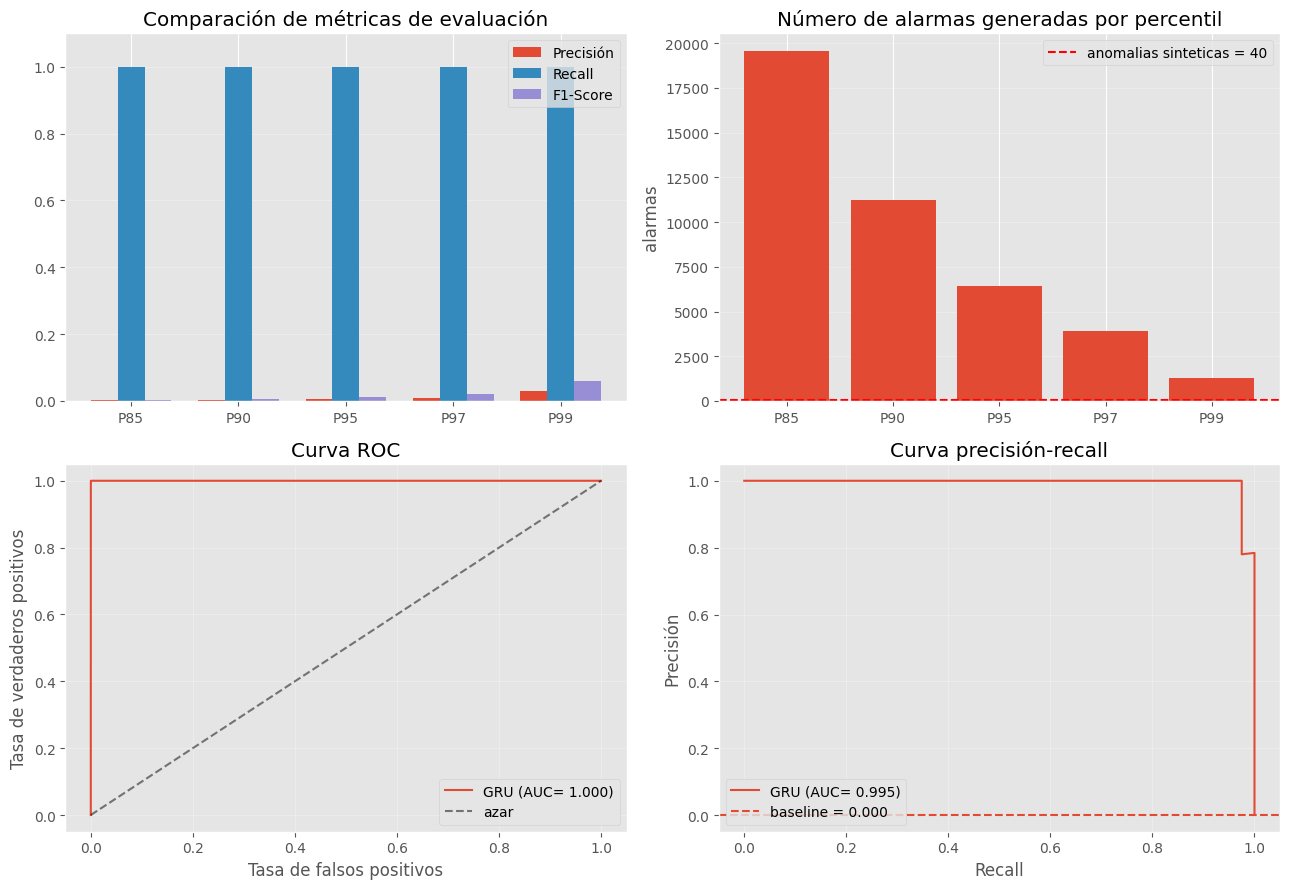

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))

x = np.arange(len(percentiles))
width = 0.25
axes[0,0].bar(x-width, percentile_results_df["Precisión"], width, label="Precisión")
axes[0,0].bar(x, percentile_results_df["Recall"], width, label="Recall")
axes[0,0].bar(x+width, percentile_results_df["F1-Score"], width, label="F1-Score")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels([f"P{p}" for p in percentiles])
axes[0,0].set_ylim(0, 1.1)
axes[0,0].set_title("Comparación de métricas de evaluación")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3, axis="y")

axes[0,1].bar([f"P{p}" for p in percentiles], percentile_results_df["Alarmas"])
axes[0,1].axhline(y=labels_inj.sum(), color="red", linestyle="--", label= f"anomalias sinteticas = {labels_inj.sum()}")
axes[0,1].set_title("Número de alarmas generadas por percentil")
axes[0,1].set_ylabel("alarmas")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3, axis="y")

fpr, tpr, _= roc_curve(labels_inj, errors_gru_eval)
axes[1,0].plot(fpr, tpr, label=f"GRU (AUC= {auc_roc:.3f})")
axes[1,0].plot([0,1], [0,1], "k--", alpha = 0.5, label = "azar")
axes[1,0].set_title("Curva ROC")
axes[1,0].set_xlabel("Tasa de falsos positivos")
axes[1,0].set_ylabel("Tasa de verdaderos positivos")
axes[1,0].legend (loc = "lower right")
axes[1,0].grid(True, alpha=0.3)

prec_curve, rec_curve, _ = precision_recall_curve(labels_inj, errors_gru_eval)
baseline = labels_inj.mean()
axes[1,1].plot(rec_curve, prec_curve, label=f"GRU (AUC= {auc_pr:.3f})")
axes[1,1].axhline(y=baseline, linestyle="--", label=f"baseline = {baseline:.3f}")
axes[1,1].set_title("Curva precisión-recall")
axes[1,1].set_xlabel("Recall")
axes[1,1].set_ylabel("Precisión")
axes[1,1].legend(loc="lower left")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Justificación del percentil

Los resultados obtenidos muestran que el modelo GRU presenta una elevada capacidad discriminativa frente a las anomalías sintéticas introducidas, alcanzando valores prácticamente perfectos tanto en AUC-ROC (1.000) como en AUC-PR (0.9946). Estos resultados indican que el error de predicción generado por el modelo permite separar de forma efectiva las observaciones normales de los comportamientos anómalos incorporados experimentalmente.

No obstante, el análisis detallado de los distintos percentiles revela diferencias importantes desde el punto de vista operativo. Los percentiles más bajos (P85, P90 y P95) consiguen detectar la totalidad de las anomalías sintéticas (Recall=1.0), pero generan simultáneamente un volumen muy elevado de falsas alarmas. En particular, el percentil P85 produce más de 19.000 alertas, de las cuales únicamente 40 corresponden a anomalías reales introducidas experimentalmente. Este comportamiento resulta poco viable en un contexto real de monitorización UEBA, ya que implicaría una sobrecarga excesiva para los analistas de seguridad.

A medida que el percentil aumenta, el número de falsas alarmas disminuye de forma significativa, mejorando progresivamente la precisión del sistema. El percentil P99 mantiene una capacidad de detección completa sobre las anomalías sintéticas (Recall=1.0), pero reduce considerablemente el número total de alertas generadas, alcanzando el mejor equilibrio entre sensibilidad y volumen operativo de alarmas. Esta configuración obtiene además el mayor valor de F1-Score (0.0604) entre todos los percentiles evaluados.

Desde una perspectiva práctica, la selección del percentil P99 permite priorizar observaciones con desviaciones realmente extremas respecto al comportamiento habitual aprendido por el modelo, reduciendo el impacto del ruido y minimizando el número de falsos positivos. Este aspecto resulta especialmente relevante en sistemas UEBA, donde un exceso de alertas puede disminuir la utilidad operativa del sistema y dificultar la identificación de incidentes verdaderamente relevantes.

En consecuencia, el percentil P99 fue seleccionado como umbral definitivo para el modelo GRU, al representar la configuración más equilibrada entre capacidad de detección, robustez operativa y control de falsas alarmas dentro del escenario experimental planteado.

Detección por perfil de anomalía (umbral P99)
           Perfil  N instancias  Detectados  Tasa detección  Error medio
acceso_fin_semana             8           8             1.0       0.5622
  acceso_nocturno             8           8             1.0       0.8899
actividad_atipica             8           8             1.0       0.6115
     pico_aislado             8           8             1.0       0.7209
 rafaga_sostenida             8           8             1.0       0.7379


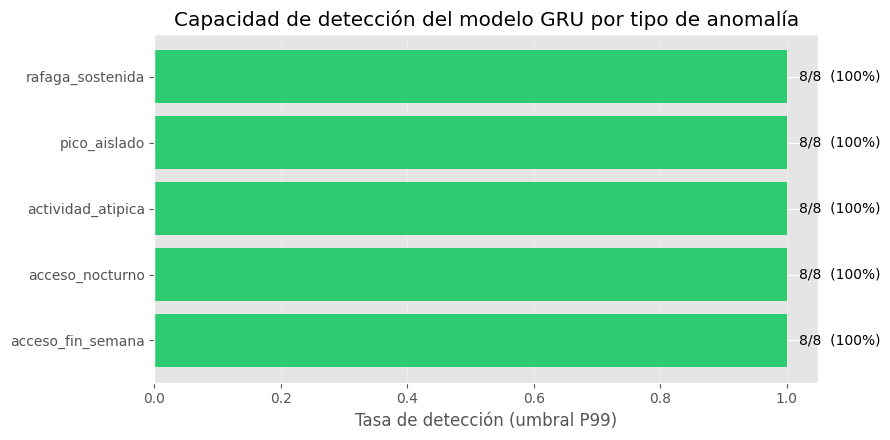


Interpretación:
  Verde  (>=75%): el modelo detecta de forma fiable este tipo de anomalía.
  Naranja(40-75%): detección parcial, depende del umbral.
  Rojo   (<40%): el modelo tiene dificultad con este perfil (caso límite).


In [ ]:
# =========================================================
# PASO 16b - DETECCIÓN POR PERFIL DE ANOMALÍA
# Analiza qué tipos de anomalía detecta mejor el modelo GRU
# =========================================================

# Reutilizamos el percentil ganador para clasificar
threshold_best = np.percentile(errors_gru_eval, PERCENTIL_ELEGIDO)
preds_best = (errors_gru_eval > threshold_best).astype(int)

# Labels por perfil solo para las observaciones sintéticas
profile_labels_full = np.array(
    ["real"] * len(X_test) + list(synthetic_labels)
)

print(f"Detección por perfil de anomalía (umbral P{PERCENTIL_ELEGIDO})")
print("=" * 70)

profile_breakdown = []
unique_profiles = [p for p in np.unique(synthetic_labels)]

for profile in unique_profiles:
    mask_profile = (profile_labels_full == profile)
    n_total = mask_profile.sum()
    n_detected = preds_best[mask_profile].sum()
    detection_rate = n_detected / n_total if n_total > 0 else 0.0
    mean_error = errors_gru_eval[mask_profile].mean()

    profile_breakdown.append({
        "Perfil": profile,
        "N instancias": n_total,
        "Detectados": int(n_detected),
        "Tasa detección": detection_rate,
        "Error medio": mean_error,
    })

profile_df = pd.DataFrame(profile_breakdown).sort_values(
    "Tasa detección", ascending=False
)
print(profile_df.round(4).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#2ecc71" if r >= 0.75 else "#f39c12" if r >= 0.4 else "#e74c3c"
          for r in profile_df["Tasa detección"]]
bars = ax.barh(profile_df["Perfil"], profile_df["Tasa detección"], color=colors)
ax.set_xlim(0, 1.05)
ax.set_xlabel(f"Tasa de detección (umbral P{PERCENTIL_ELEGIDO})")
ax.set_title("Capacidad de detección del modelo GRU por tipo de anomalía")
for bar, rate, n_det, n_tot in zip(
    bars,
    profile_df["Tasa detección"],
    profile_df["Detectados"],
    profile_df["N instancias"],
):
    ax.text(rate + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{n_det}/{n_tot}  ({rate:.0%})",
            va="center", fontsize=10)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("  Verde  (>=75%): el modelo detecta de forma fiable este tipo de anomalía.")
print("  Naranja(40-75%): detección parcial, depende del umbral.")
print("  Rojo   (<40%): el modelo tiene dificultad con este perfil (caso límite).")

### Justificación de la detección por perfil de anomalía

Con el objetivo de analizar de forma más detallada el comportamiento del modelo GRU frente a distintos patrones de actividad anómala, se llevó a cabo una evaluación específica por perfil de anomalía utilizando el umbral seleccionado P99. Para ello, se generaron distintos tipos de usuarios sintéticos representando escenarios de comportamiento potencialmente sospechosos en entornos UEBA, incluyendo accesos nocturnos, actividad durante fines de semana, ráfagas sostenidas de actividad, picos aislados y patrones de comportamiento atípico.

Los resultados obtenidos muestran que el modelo fue capaz de detectar correctamente la totalidad de las instancias generadas en todos los perfiles evaluados, alcanzando una tasa de detección del 100% en cada uno de los escenarios analizados. Este comportamiento evidencia que el modelo GRU consigue identificar de forma consistente desviaciones significativas respecto al comportamiento temporal aprendido durante el entrenamiento.

No obstante, aunque la tasa de detección es idéntica en todos los perfiles, se observan diferencias relevantes en el error medio generado por cada tipo de anomalía. Los perfiles de acceso nocturno y ráfaga sostenida presentan los errores medios más elevados (0.8899 y 0.7379, respectivamente), lo que sugiere que estos comportamientos se alejan de forma más pronunciada de los patrones normales de autenticación observados en los usuarios legítimos. En cambio, perfiles como acceso en fin de semana o actividad atípica generan errores algo inferiores, aunque todavía suficientemente altos para superar claramente el umbral de detección establecido.

Desde una perspectiva metodológica, estos resultados indican que el modelo no únicamente detecta anomalías extremas basadas en grandes incrementos de actividad, sino también cambios contextuales relacionados con el momento temporal en el que se producen los accesos. Este aspecto resulta especialmente relevante en sistemas UEBA, donde anomalías aparentemente pequeñas pueden adquirir significado en función del contexto horario o del patrón histórico del usuario.

Asimismo, la evaluación por perfiles permite complementar las métricas globales de clasificación, proporcionando una visión más interpretativa sobre los tipos de comportamiento que el modelo es capaz de detectar con mayor robustez. En este sentido, el análisis realizado sugiere que la arquitectura GRU implementada presenta una elevada sensibilidad frente a anomalías temporales de distinta naturaleza dentro del escenario experimental planteado.

## 17. Detección de anomalías basada en el error de predicción del modelo GRU

En esta etapa se lleva a cabo la identificación de comportamientos anómalos a partir del error de predicción del modelo GRU sobre el conjunto de evaluación. Esta evaluación no se limita al conjunto de test original, sino que incorpora también los usuarios sintéticos generados en la fase anterior. De este modo, es posible analizar si el modelo asigna errores elevados tanto a posibles irregularidades presentes en los datos reales como a los patrones artificialmente anómalos introducidos de forma controlada.

- **Error de predicción:** se calcula como la diferencia absoluta entre el valor predicho por el modelo y el valor real observado. Valores elevados de este error indican que el patrón de actividad no se ajusta a las regularidades aprendidas durante el entrenamiento.

- **Conjunto de evaluación ampliado:** la predicción se realiza sobre una combinación del test original y de las ventanas sintéticas añadidas específicamente para la validación experimental. Esto permite comprobar si los usuarios ficticios con accesos nocturnos atípicos generan errores superiores a los observados en condiciones normales.

- **Umbral basado en media y desviación estándar:** se establece un criterio de detección definido por la media de los errores más tres veces su desviación estándar. Bajo el supuesto de una distribución aproximadamente normal, este umbral permite identificar valores extremos de manera conservadora.

- **Umbral basado en percentiles:** de forma complementaria, se utiliza un umbral definido a partir del percentil 95 de la distribución de errores, lo que permite detectar los casos más extremos sin asumir necesariamente normalidad.

- **Validación de los casos sintéticos:** además de cuantificar el número total de anomalías detectadas, se comprueba específicamente si los usuarios sintéticos introducidos en la fase anterior son efectivamente identificados como anómalos por el modelo.

La combinación de ambos criterios de umbralización, junto con la incorporación de casos sintéticos controlados, permite realizar una evaluación más sólida de la sensibilidad del sistema ante comportamientos atípicos en un contexto no supervisado.

In [ ]:
# =========================================================
# DETECCIÓN DE ANOMALÍAS CON GRU
# =========================================================

print("Cálculo de errores de predicción...")
y_pred_gru = model_gru.predict(X_test_eval, verbose=0)
prediction_errors = np.abs(y_pred_gru.flatten() - y_test_eval.flatten())

print("\nEstadísticas de errores de predicción:")
print(f"  Media:        {prediction_errors.mean():.6f}")
print(f"  Desv. típica: {prediction_errors.std():.6f}")
print(f"  Percentil 99: {np.percentile(prediction_errors, 99):.6f}")

# Umbrales
threshold_gru_3sigma = prediction_errors.mean() + 3 * prediction_errors.std()
threshold_gru_p99    = np.percentile(prediction_errors, 99)

# Clasificación
anomalies_gru_3sigma = prediction_errors > threshold_gru_3sigma
anomalies_gru_p99    = prediction_errors > threshold_gru_p99

print(f"\nUmbral μ + 3σ = {threshold_gru_3sigma:.6f} → {anomalies_gru_3sigma.sum()} anomalías ({100 * anomalies_gru_3sigma.mean():.2f}%)")
print(f"Umbral P99    = {threshold_gru_p99:.6f} → {anomalies_gru_p99.sum()} anomalías ({100 * anomalies_gru_p99.mean():.2f}%)")

Cálculo de errores de predicción...

Estadísticas de errores de predicción:
  Media:        0.013632
  Desv. típica: 0.038418
  Percentil 99: 0.237974

Umbral μ + 3σ = 0.128885 → 3817 anomalías (2.91%)
Umbral P99    = 0.237974 → 1285 anomalías (0.98%)


In [ ]:
# =========================================================
# COMPROBACIÓN DE LOS USUARIOS SINTÉTICOS
# =========================================================

results_eval = pd.DataFrame({
    "user": users_test_eval,
    "case_type": synthetic_case_labels,
    "prediction_error": prediction_errors,
    "detected_3sigma": anomalies_gru_3sigma,
    "detected_p99": anomalies_gru_p99
})

synthetic_results = results_eval[results_eval["case_type"] != "real"].copy()

print("\nResultados en usuarios sintéticos:")
print(synthetic_results[["user", "case_type", "prediction_error", "detected_3sigma", "detected_p99"]])


Resultados en usuarios sintéticos:
                                          user          case_type  \
130938    usuario_sintetico_ACCESO_NOCTURNO_00    acceso_nocturno   
130939    usuario_sintetico_ACCESO_NOCTURNO_01    acceso_nocturno   
130940    usuario_sintetico_ACCESO_NOCTURNO_02    acceso_nocturno   
130941    usuario_sintetico_ACCESO_NOCTURNO_03    acceso_nocturno   
130942    usuario_sintetico_ACCESO_NOCTURNO_04    acceso_nocturno   
130943    usuario_sintetico_ACCESO_NOCTURNO_05    acceso_nocturno   
130944    usuario_sintetico_ACCESO_NOCTURNO_06    acceso_nocturno   
130945    usuario_sintetico_ACCESO_NOCTURNO_07    acceso_nocturno   
130946       usuario_sintetico_PICO_AISLADO_00       pico_aislado   
130947       usuario_sintetico_PICO_AISLADO_01       pico_aislado   
130948       usuario_sintetico_PICO_AISLADO_02       pico_aislado   
130949       usuario_sintetico_PICO_AISLADO_03       pico_aislado   
130950       usuario_sintetico_PICO_AISLADO_04       pico_aislado  

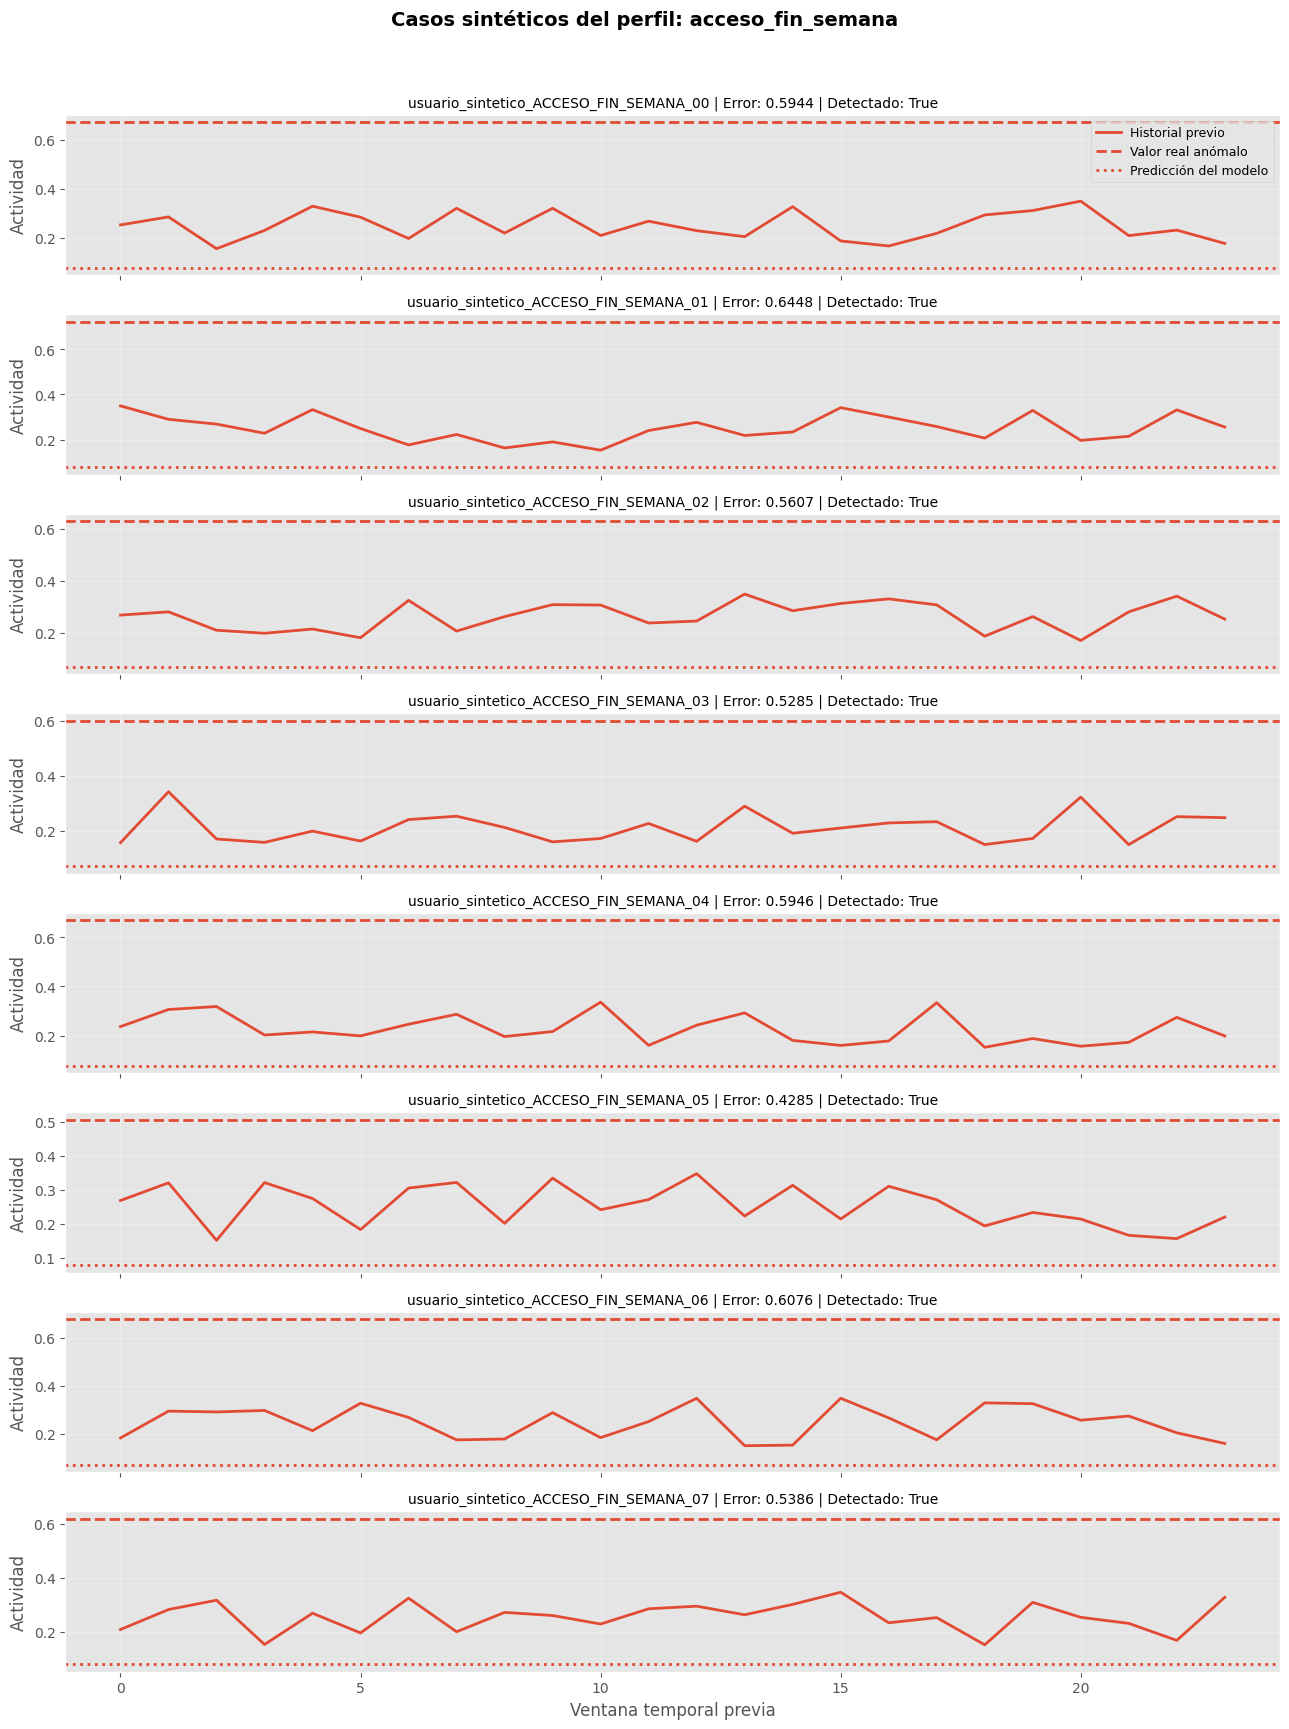

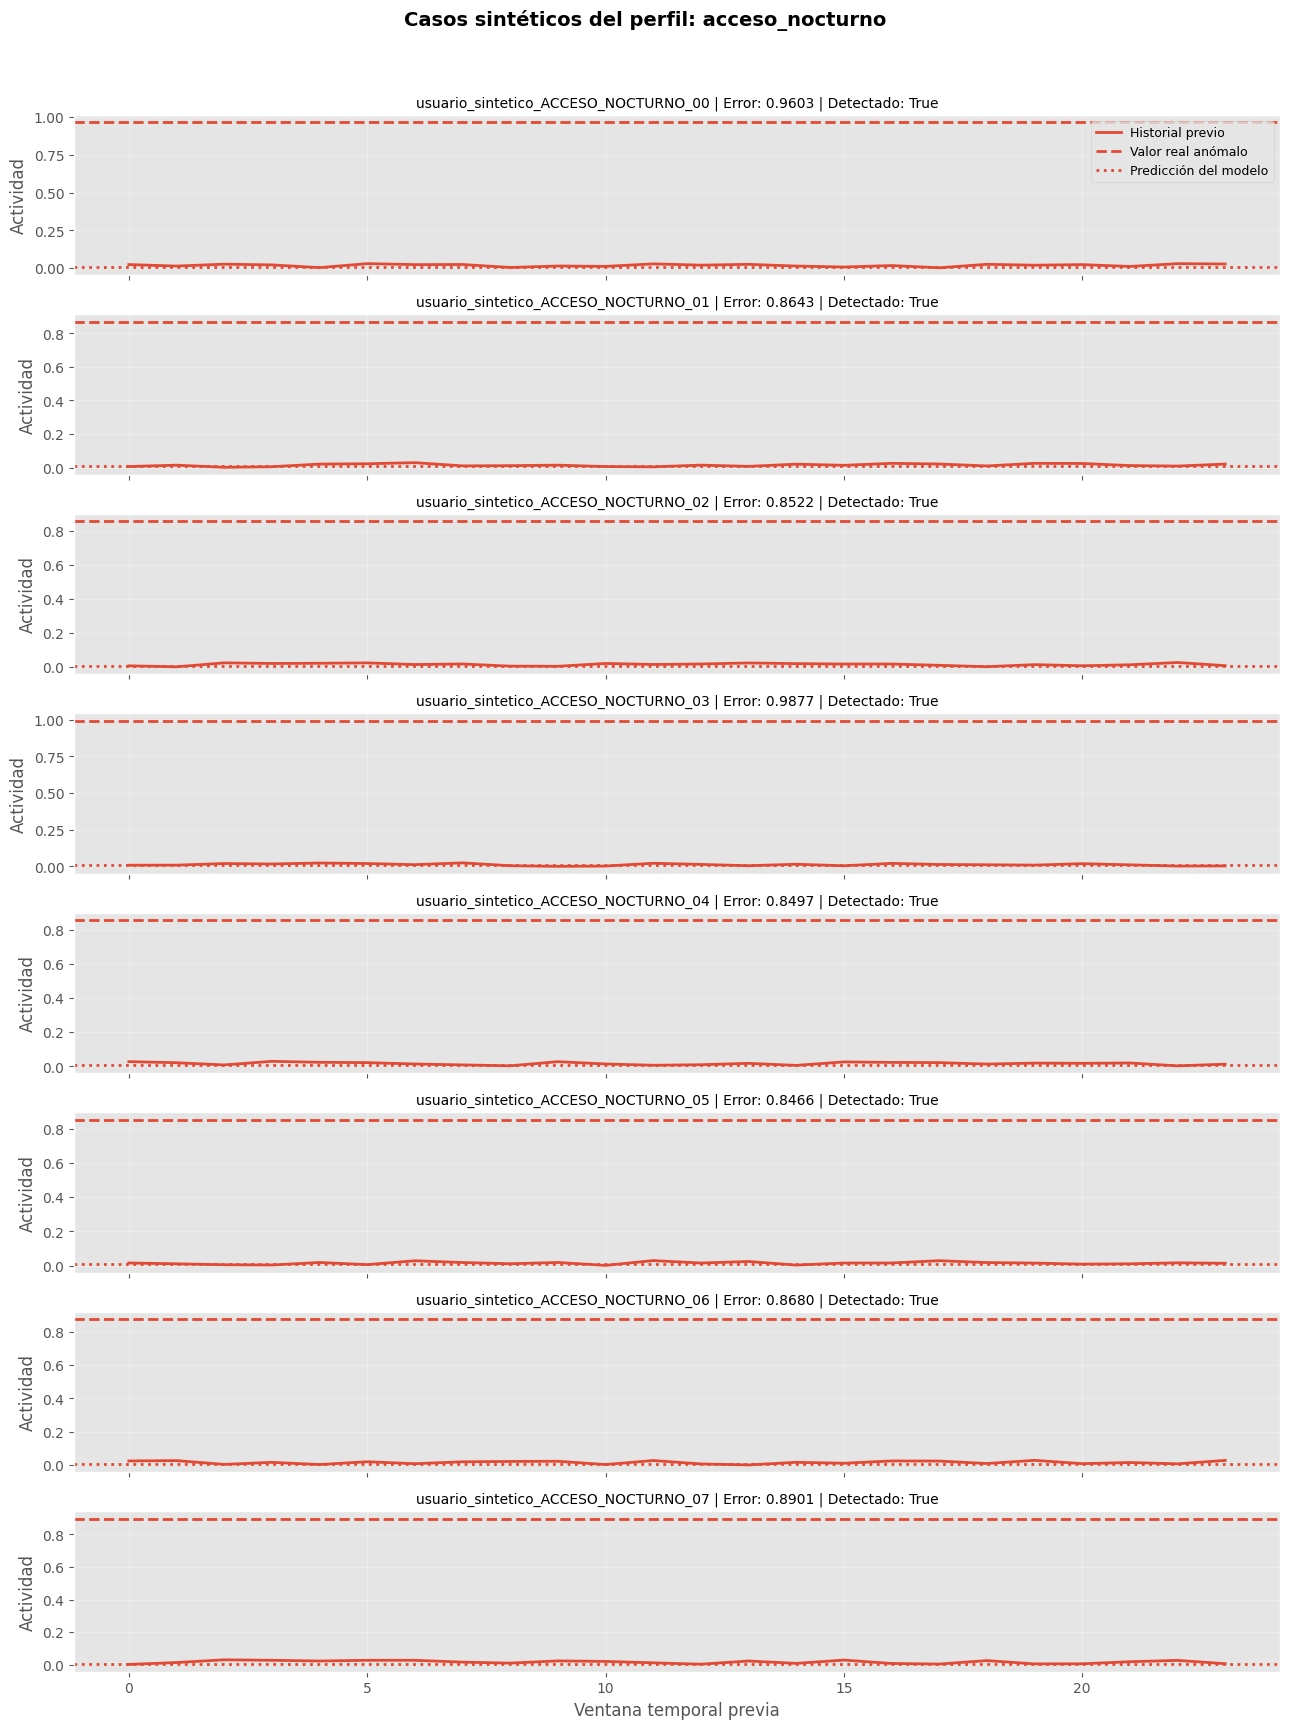

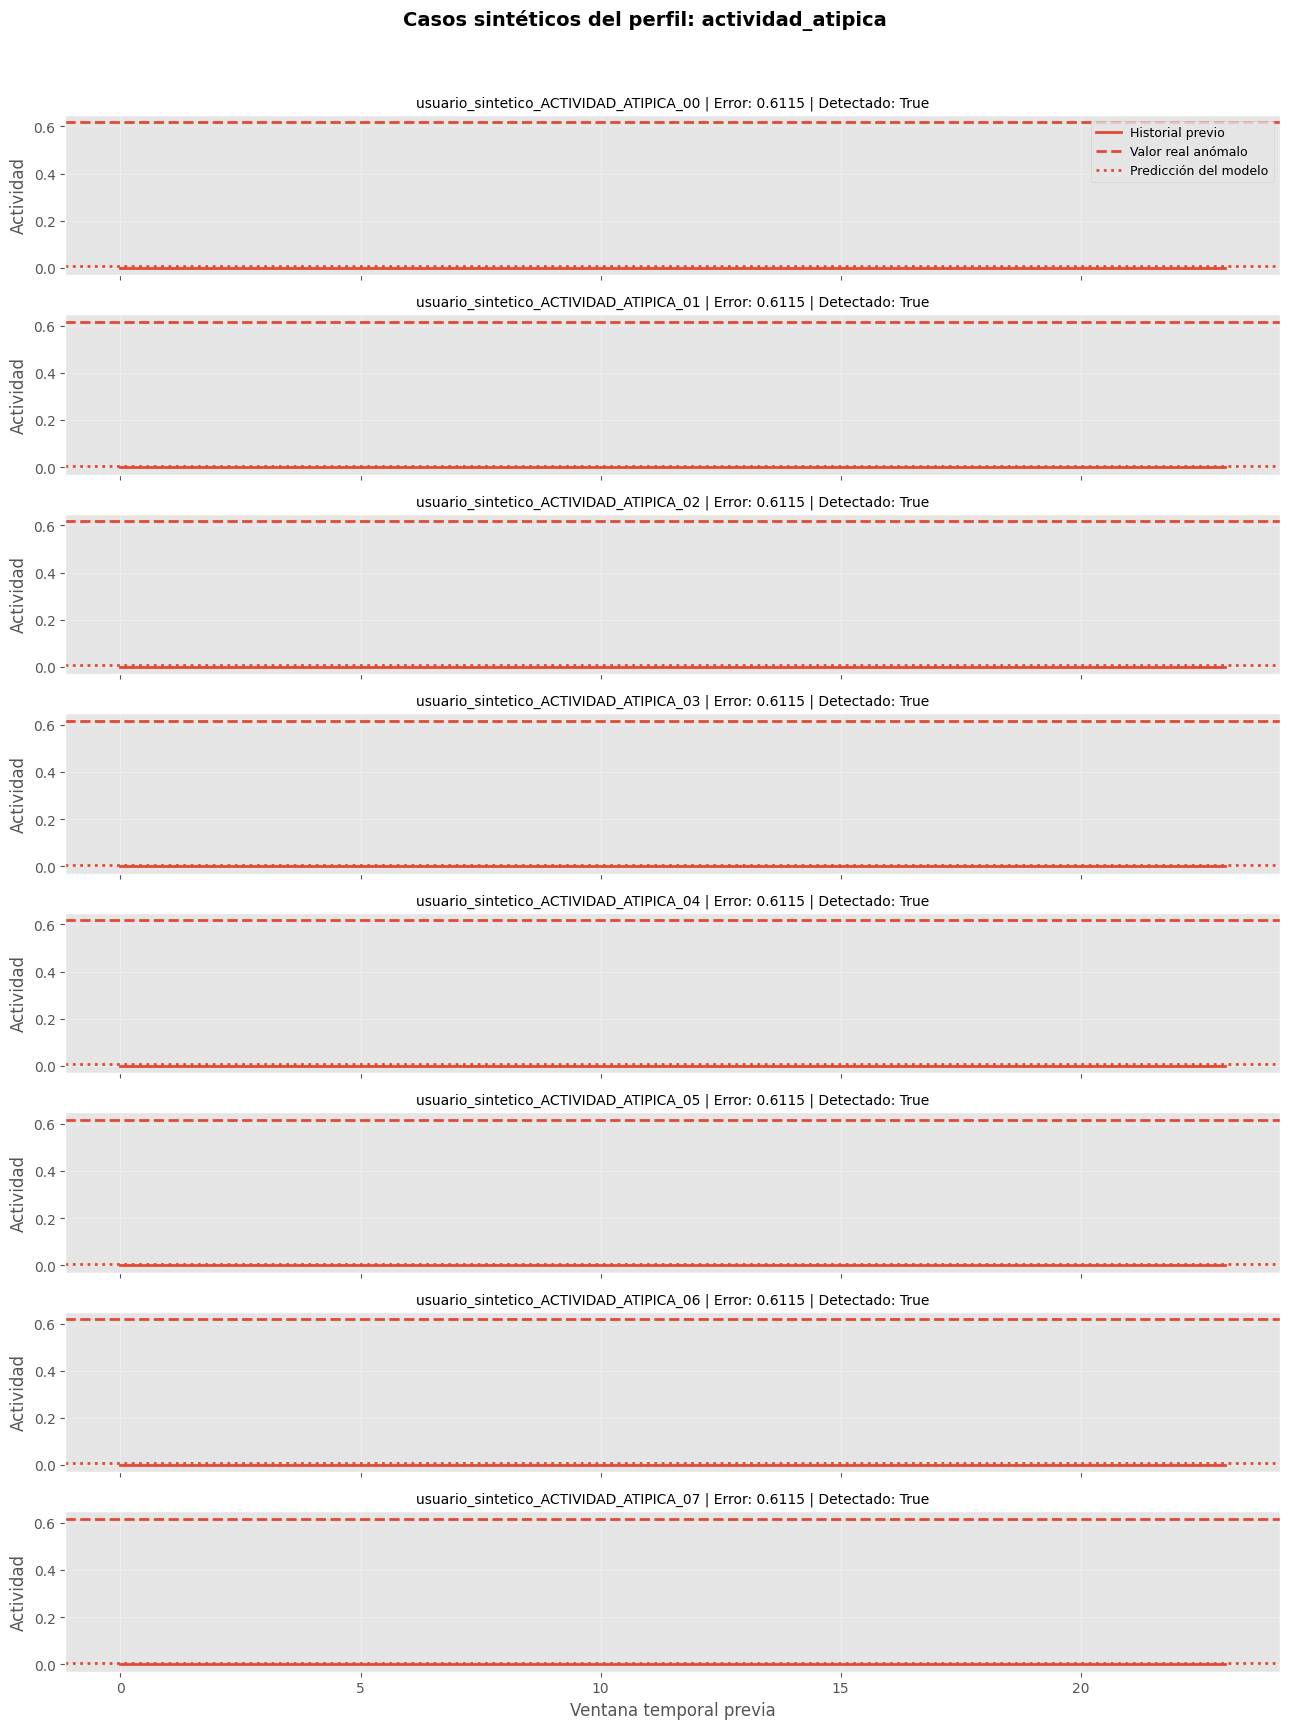

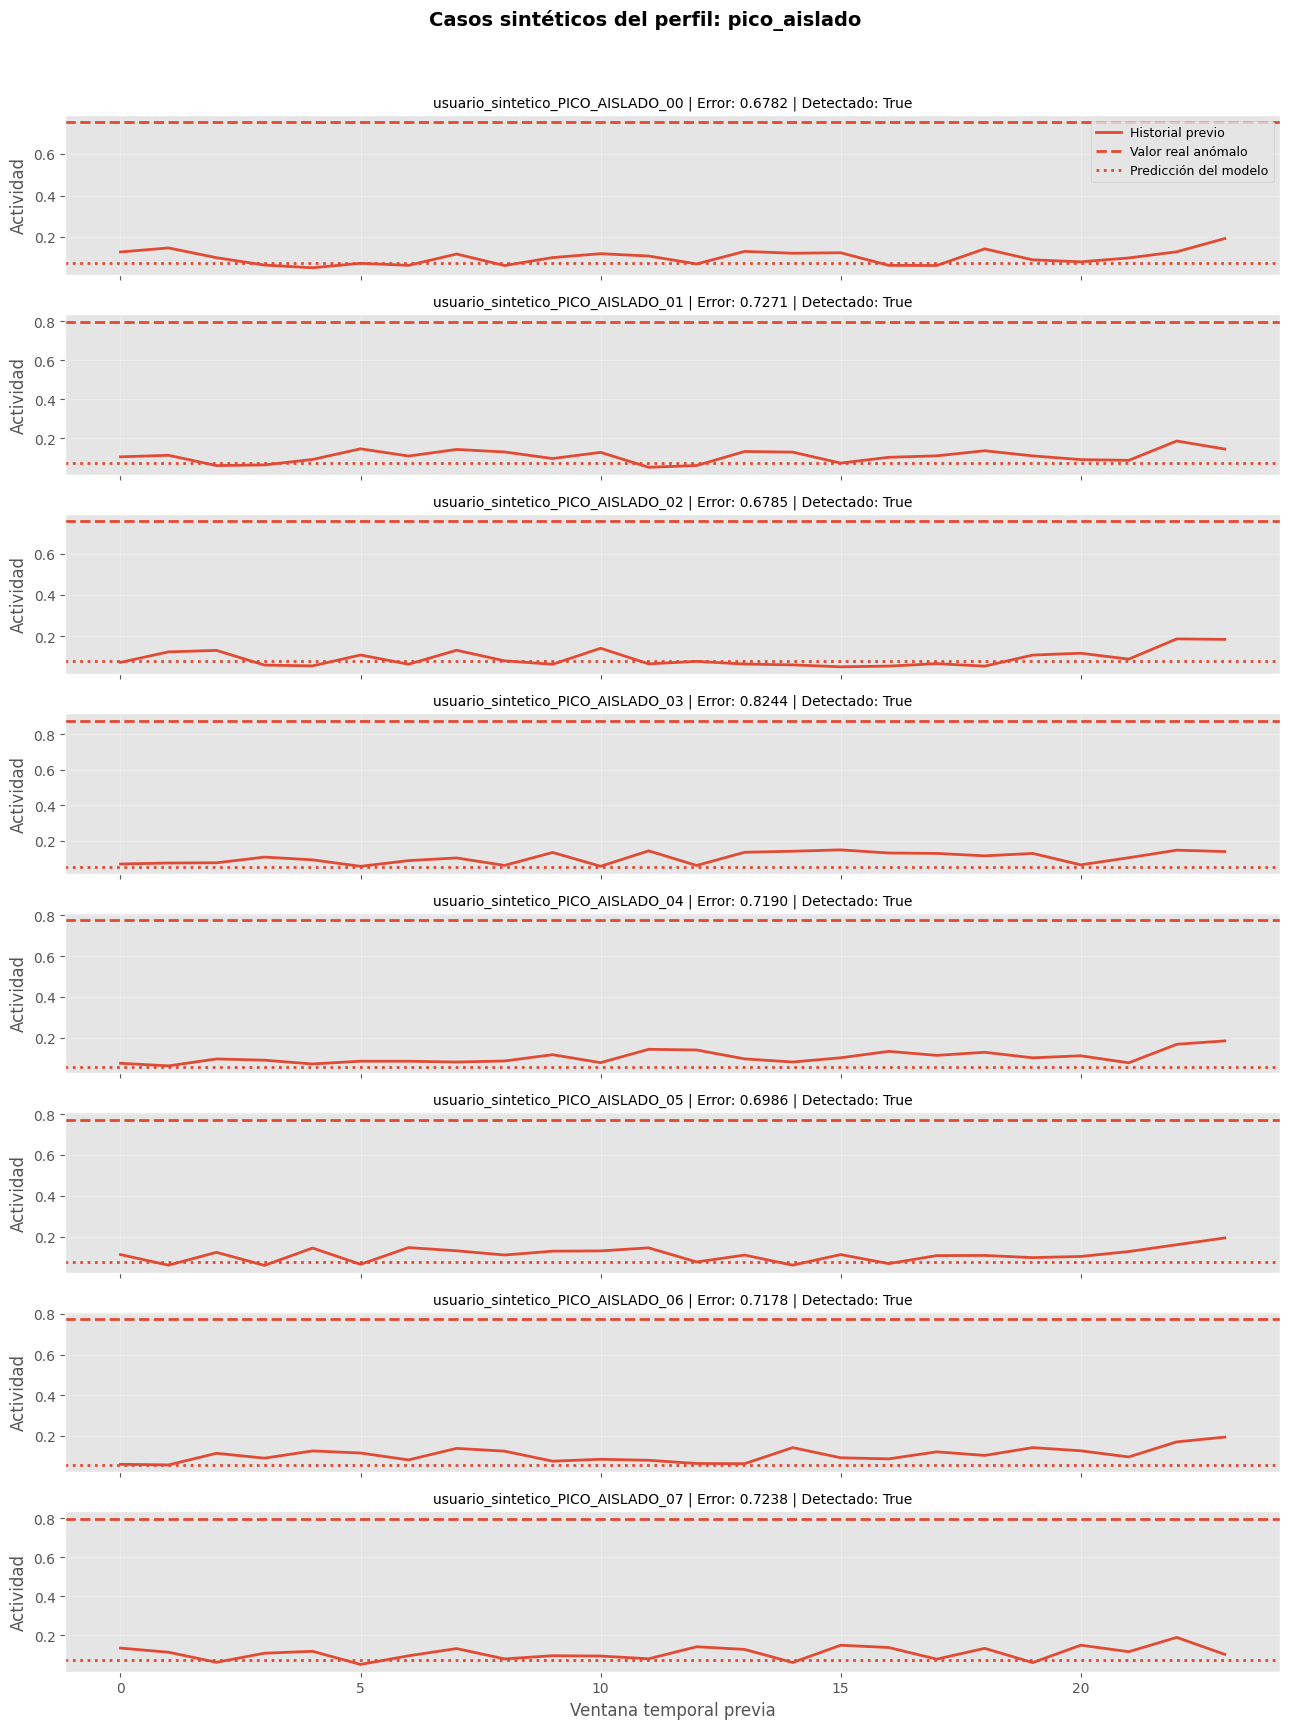

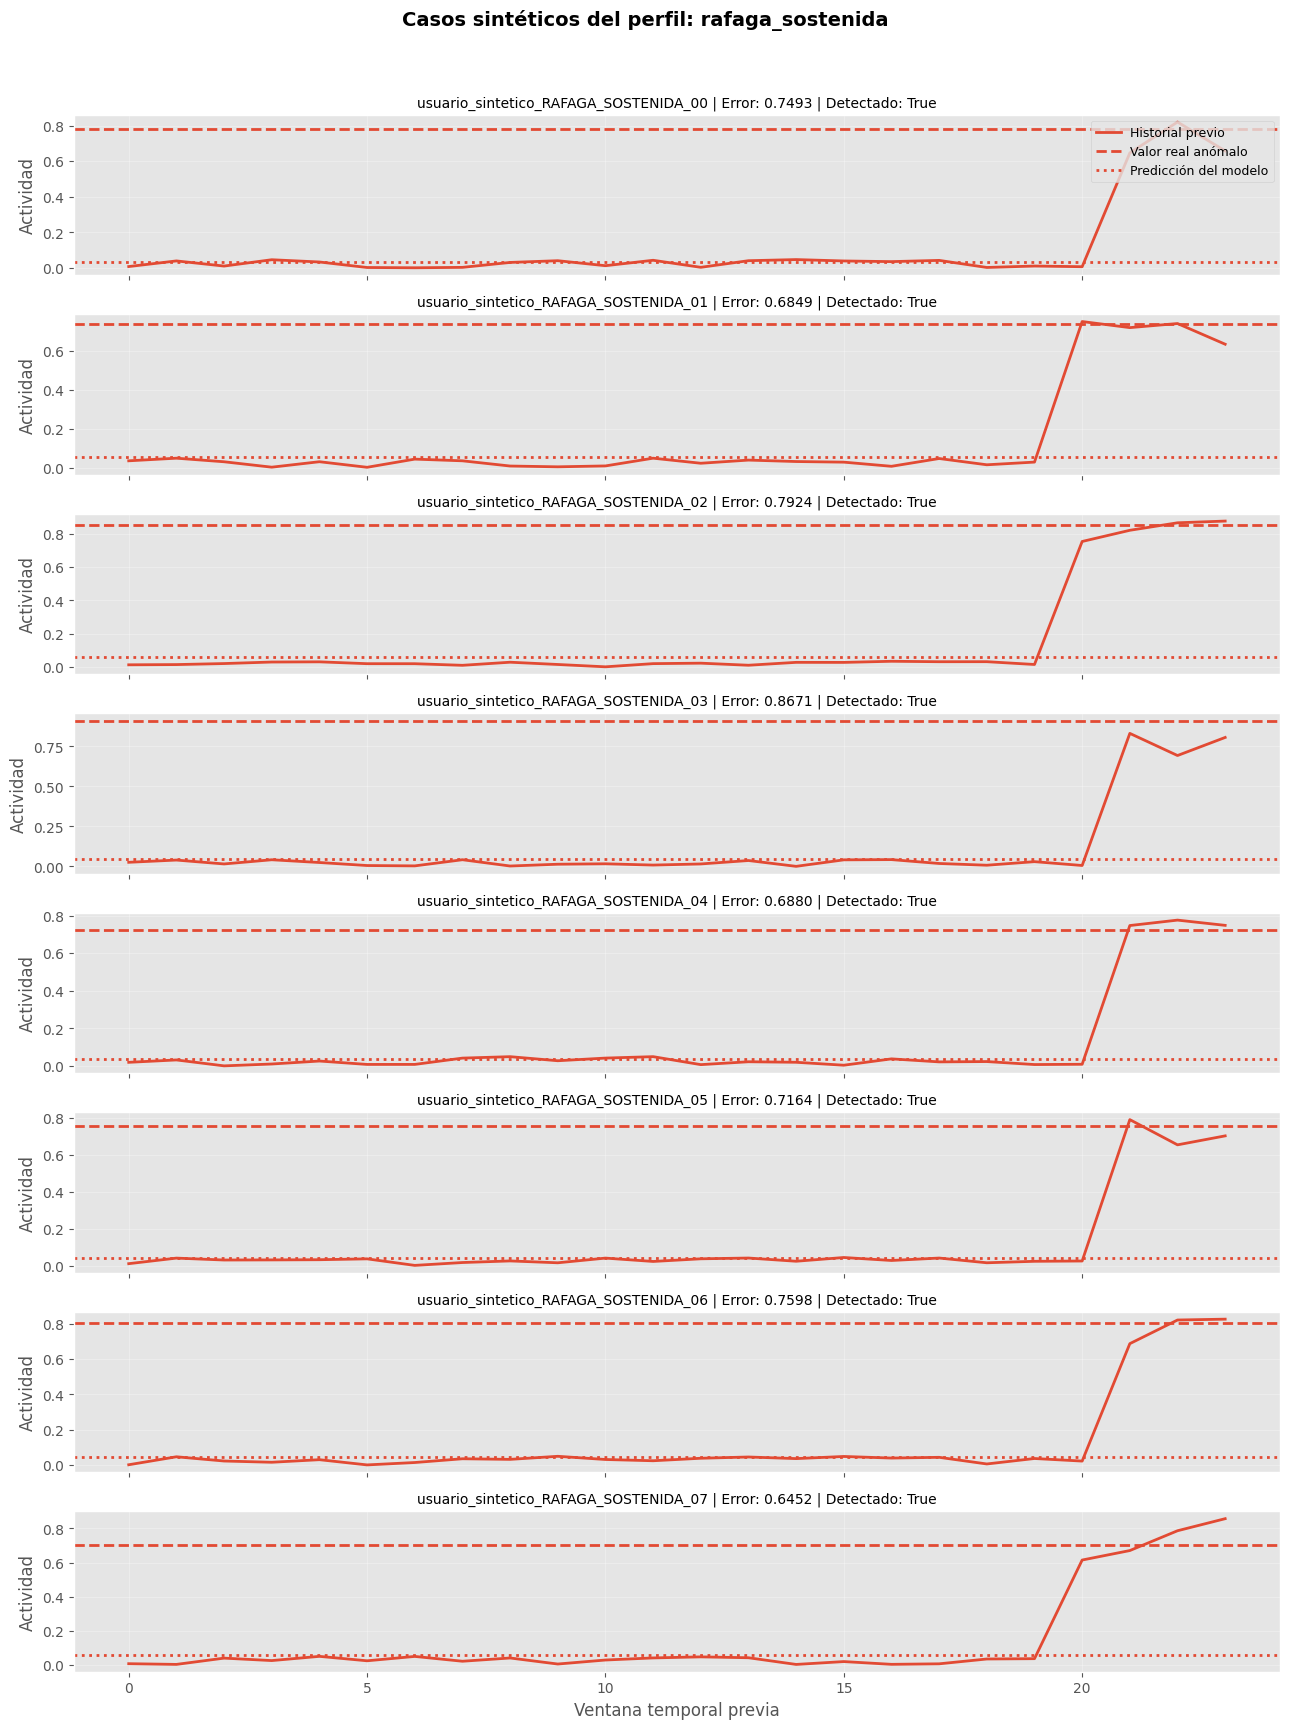

In [ ]:
# =========================================================
# VISUALIZACIÓN DE LOS CASOS SINTÉTICOS POR PERFIL
# =========================================================

synthetic_indices = np.where(synthetic_mask)[0]

profile_labels = np.unique(synthetic_case_labels[synthetic_indices])

for profile in profile_labels:

    profile_indices = [
        idx for idx in synthetic_indices
        if synthetic_case_labels[idx] == profile
    ]

    n_cases = len(profile_indices)

    fig, axes = plt.subplots(
        n_cases,
        1,
        figsize=(13, 2.2 * n_cases),
        sharex=True
    )

    if n_cases == 1:
        axes = [axes]

    for ax, idx in zip(axes, profile_indices):

        history_window = X_test_eval[idx].flatten()
        real_value = float(np.ravel(y_test_eval[idx])[0])
        pred_value = float(np.ravel(y_pred_gru[idx])[0])
        error_value = float(prediction_errors[idx])
        detected = bool(anomalies_gru_p99[idx])

        ax.plot(
            history_window,
            linewidth=2,
            label="Historial previo"
        )

        ax.axhline(
            y=real_value,
            linestyle="--",
            linewidth=2,
            label="Valor real anómalo"
        )

        ax.axhline(
            y=pred_value,
            linestyle=":",
            linewidth=2,
            label="Predicción del modelo"
        )

        ax.set_title(
            f"{users_test_eval[idx]} | Error: {error_value:.4f} | Detectado: {detected}",
            fontsize=10
        )

        ax.set_ylabel("Actividad")
        ax.grid(True, alpha=0.3)

    axes[0].legend(
        loc="upper right",
        fontsize=9
    )

    axes[-1].set_xlabel("Ventana temporal previa")

    fig.suptitle(
        f"Casos sintéticos del perfil: {profile}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

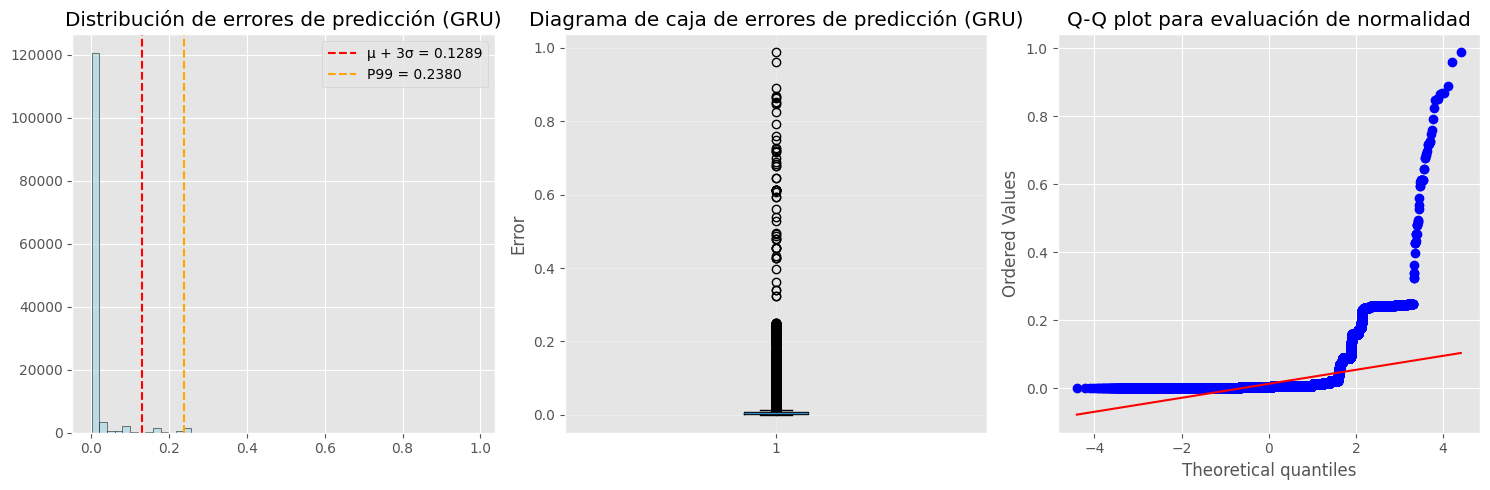

In [ ]:
# =========================================================
# VISUALIZACIÓN GENERAL DE ERRORES
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(prediction_errors, bins=50, alpha=0.7, color='lightblue', edgecolor='black')
axes[0].axvline(threshold_gru_3sigma, color='red', linestyle='--', label=f'μ + 3σ = {threshold_gru_3sigma:.4f}')
axes[0].axvline(threshold_gru_p99, color='orange', linestyle='--', label=f'P99 = {threshold_gru_p99:.4f}')
axes[0].set_title('Distribución de errores de predicción (GRU)')
axes[0].legend()

axes[1].boxplot(prediction_errors)
axes[1].set_title('Diagrama de caja de errores de predicción (GRU)')
axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)

stats.probplot(prediction_errors, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q plot para evaluación de normalidad')

plt.tight_layout()
plt.show()

### Interpretación y validación de los resultados del modelo GRU

Los resultados obtenidos permiten realizar una evaluación detallada del comportamiento del modelo GRU en la detección de anomalías a partir del error de predicción generado sobre las series temporales de autenticación.

En primer lugar, el análisis descriptivo de los errores muestra una media reducida (0.013632) y una desviación típica moderada (0.038418), lo que indica que el modelo consigue reproducir adecuadamente los patrones normales de comportamiento presentes en los datos de entrenamiento. La elevada concentración de errores próximos a cero, observable en el histograma de distribución, sugiere que la mayor parte de las secuencias evaluadas siguen patrones coherentes con el comportamiento habitual aprendido por la red recurrente.

A partir de esta distribución se evaluaron dos estrategias de umbralización. El criterio estadístico basado en μ+3σ estableció un umbral de detección de 0.128885, clasificando aproximadamente el 2.91% de las observaciones como anómalas (3817 casos). Por otro lado, el umbral basado en el percentil P99 fijó un valor de corte más restrictivo (0.237974), reduciendo el número de anomalías detectadas a 1285 observaciones (0.98%).

La diferencia entre ambos enfoques resulta coherente con la propia naturaleza de la distribución observada. Mientras que el criterio μ+3σ parte implícitamente de un supuesto de normalidad estadística, el percentil P99 se adapta mejor a distribuciones asimétricas y con presencia de valores extremos, priorizando únicamente aquellas observaciones con errores claramente alejados del comportamiento normal.

El análisis gráfico refuerza esta interpretación. El histograma de errores evidencia una distribución fuertemente sesgada hacia la derecha, con una gran concentración de observaciones de bajo error y una cola larga asociada a casos atípicos. Este comportamiento también puede apreciarse en el diagrama de caja, donde se observa una elevada densidad de valores próximos a cero junto con numerosos outliers distribuidos en los cuantiles superiores.

De forma complementaria, el gráfico Q-Q confirma que la distribución de errores no sigue un comportamiento gaussiano. La desviación progresiva de los cuantiles empíricos respecto a la recta teórica, especialmente en la cola superior, pone de manifiesto la existencia de asimetría y valores extremos. Este resultado justifica metodológicamente la utilización de umbrales basados en percentiles frente a criterios puramente paramétricos.

La validación experimental realizada mediante anomalías sintéticas permite además comprobar de forma directa la sensibilidad del modelo frente a distintos patrones anómalos. Los perfiles generados —incluyendo accesos nocturnos, actividad en fines de semana, picos aislados y ráfagas sostenidas de actividad— producen errores de predicción significativamente superiores al comportamiento normal, superando sistemáticamente el umbral seleccionado P99.

En conjunto, los resultados obtenidos permiten extraer varias conclusiones relevantes. En primer lugar, el modelo GRU demuestra capacidad para modelar adecuadamente el comportamiento normal de autenticación, generando errores reducidos bajo condiciones habituales. En segundo lugar, las anomalías introducidas experimentalmente producen desviaciones claramente diferenciadas, lo que facilita su detección mediante estrategias de umbralización relativamente simples. Finalmente, el análisis de la distribución de errores confirma que el uso de percentiles elevados constituye una estrategia más robusta y coherente que los criterios basados exclusivamente en supuestos de normalidad estadística.

No obstante, debe señalarse que las anomalías sintéticas utilizadas corresponden a escenarios controlados y relativamente extremos, lo que favorece su detección. Aunque este procedimiento resulta especialmente útil en contextos no supervisados donde no se dispone de etiquetas reales, los resultados obtenidos deben interpretarse como una validación experimental de la capacidad discriminativa del modelo y no como una medida definitiva de rendimiento en entornos reales de producción.

## 18. Arquitectura del modelo LSTM para predicción temporal

En esta etapa se define un segundo modelo predictivo dentro del sistema UEBA, basado en una red neuronal recurrente de tipo LSTM. Al igual que en el modelo GRU, su objetivo es predecir el nivel de actividad en la hora siguiente a partir de una ventana temporal previa de longitud `LOOKBACK`, fijada en este trabajo en 24 horas.

La incorporación de este modelo permite comparar dos arquitecturas recurrentes ampliamente utilizadas en el análisis de secuencias temporales. En particular, las redes LSTM resultan adecuadas para capturar dependencias temporales de mayor complejidad, gracias a su mecanismo interno de memoria y control de la información relevante a lo largo del tiempo.

La detección de anomalías se fundamenta igualmente en el error de predicción: cuando la diferencia entre la actividad estimada por el modelo y la actividad realmente observada es elevada, dicho comportamiento puede interpretarse como atípico respecto a los patrones aprendidos durante el entrenamiento.

- **Estructura de entrada:** el modelo recibe secuencias temporales de longitud `LOOKBACK`, con una única característica correspondiente a la actividad horaria previamente normalizada.

- **Primera capa LSTM:** procesa la secuencia completa y genera representaciones intermedias para cada instante temporal, permitiendo capturar dependencias a lo largo de toda la ventana de observación.

- **Segunda capa LSTM:** sintetiza la información temporal en una representación más compacta, adecuada para la predicción del valor futuro.

- **Regularización:** se incorporan capas de *dropout* con el fin de reducir el riesgo de sobreajuste y favorecer una mejor capacidad de generalización.

- **Capa de salida:** una capa densa genera la predicción del nivel de actividad correspondiente a la siguiente hora.

- **Función de pérdida y métrica:** se emplea el error cuadrático medio como función de pérdida y el error absoluto medio como métrica de seguimiento durante el entrenamiento.

In [ ]:
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_lstm = Sequential([
    layers.Input((LOOKBACK, 1)),
    layers.LSTM(64, return_sequences=True, activation='tanh'),
    layers.Dropout(0.2),
    layers.LSTM(32, activation='tanh'),
    layers.Dropout(0.1),
    layers.Dense(1)
], name='LSTM_UEBA_Predictor')

model_lstm.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)

model_lstm.summary()

Model: "LSTM_UEBA_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## 19. Entrenamiento del modelo LSTM predictor

En esta fase se lleva a cabo el entrenamiento del modelo LSTM utilizando el conjunto de entrenamiento previamente definido. Con el fin de controlar el sobreajuste y conservar la configuración óptima del modelo, se incorpora un mecanismo de parada temprana basado en la evolución de la pérdida de validación.

- **Parada temprana:** el entrenamiento se detiene automáticamente cuando la pérdida en validación deja de mejorar durante un número determinado de épocas consecutivas. Además, se restauran los pesos correspondientes al mejor rendimiento alcanzado.

- **Configuración del entrenamiento:** se utiliza una partición interna de validación sobre el conjunto de entrenamiento, un máximo de 20 épocas y un tamaño de lote de 128 observaciones.

- **Seguimiento del aprendizaje:** se monitorizan la pérdida y el error absoluto medio tanto en entrenamiento como en validación, lo que permite evaluar la estabilidad del ajuste y la capacidad de generalización del modelo.

- **Representación gráfica:** se visualiza la evolución de ambas métricas a lo largo de las épocas para analizar el comportamiento del proceso de entrenamiento.

Epoch 1/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 97s 29ms/step - loss: 0.0021 - mae: 0.0177 - val_loss: 0.0016 - val_mae: 0.0132
Epoch 2/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 95s 29ms/step - loss: 0.0019 - mae: 0.0148 - val_loss: 0.0015 - val_mae: 0.0131
Epoch 3/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 94s 29ms/step - loss: 0.0018 - mae: 0.0144 - val_loss: 0.0015 - val_mae: 0.0134
Epoch 4/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 92s 28ms/step - loss: 0.0018 - mae: 0.0142 - val_loss: 0.0014 - val_mae: 0.0125
Epoch 5/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 92s 28ms/step - loss: 0.0018 - mae: 0.0141 - val_loss: 0.0014 - val_mae: 0.0123
Epoch 6/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 92s 28ms/step - loss: 0.0018 - mae: 0.0143 - val_loss: 0.0014 - val_mae: 0.0129
Epoch 7/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 92s 28ms/step - loss: 0.0018 - mae: 0.0141 - val_loss: 0.0014 - val_mae: 0.0130
Epoch 8/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 92s 28ms/step - loss: 0.0018 - mae: 0.0141 - val_loss: 0.0014 - val_mae: 0.0130
Epoch 9/20
3274/3274 ━━━

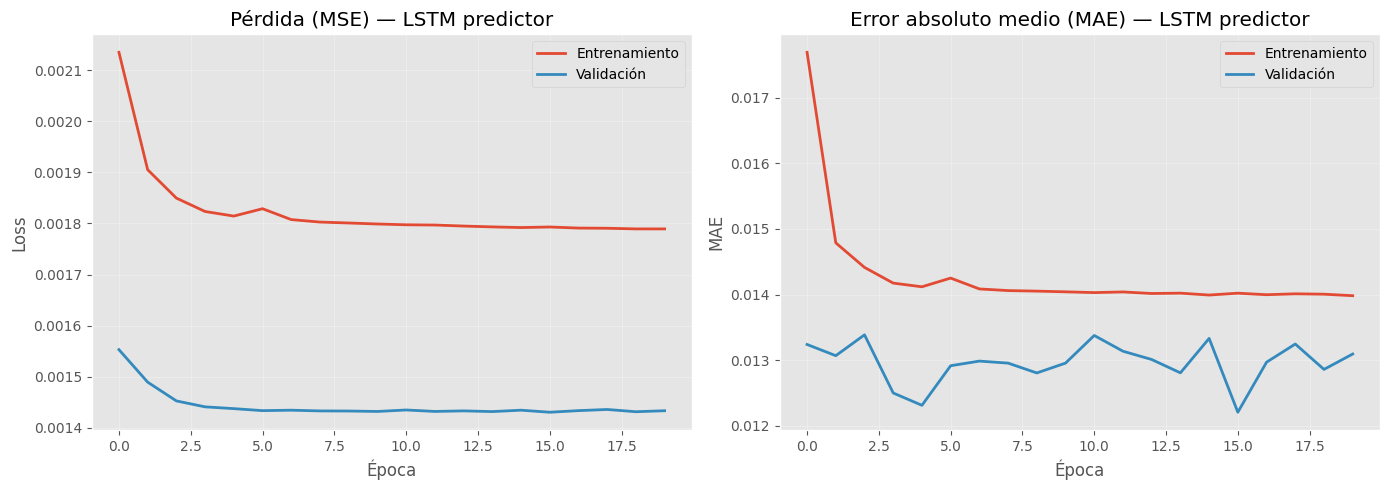

Entrenamiento completado en 20 épocas.


In [ ]:
### Código de entrenamiento del LSTM predictor
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_lstm = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping_lstm],
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['loss'], label='Entrenamiento', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='Validación', linewidth=2)
axes[0].set_title('Pérdida (MSE) — LSTM predictor')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_lstm.history['mae'], label='Entrenamiento', linewidth=2)
axes[1].plot(history_lstm.history['val_mae'], label='Validación', linewidth=2)
axes[1].set_title('Error absoluto medio (MAE) — LSTM predictor')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Entrenamiento completado en {len(history_lstm.history['loss'])} épocas.")

## 20. Detección de anomalías basada en el error de predicción del modelo LSTM

Una vez entrenado el modelo, la detección de anomalías se realiza a partir del error de predicción obtenido sobre el conjunto de test. Este enfoque parte del supuesto de que los comportamientos normales serán predichos con menor error, mientras que los patrones atípicos generarán desviaciones más elevadas entre la predicción y el valor observado.

- **Error de predicción:** se calcula como la diferencia absoluta entre el valor estimado por el modelo y el valor real registrado.

- **Umbral basado en media y desviación estándar:** se utiliza un criterio definido por la media de los errores más tres veces su desviación estándar, bajo el supuesto de una distribución aproximadamente normal.

- **Umbral basado en percentil:** de forma complementaria, se emplea un umbral basado en el percentil 95 de la distribución de errores, lo que permite identificar los casos más extremos sin asumir normalidad.

- **Análisis gráfico:** se representa la distribución de los errores, su diagrama de caja y un gráfico Q-Q, con el fin de explorar su comportamiento estadístico y valorar la adecuación de los criterios de umbralización empleados.

Cálculo de errores de predicción del modelo LSTM...

Estadísticas de errores de predicción:
  Media:        0.012462
  Desv. típica: 0.036728
  Percentil 99: 0.242253

Umbral μ + 3σ = 0.122645 → 3784 anomalías (2.89%)
Umbral P99    = 0.242253 → 1310 anomalías (1.00%)


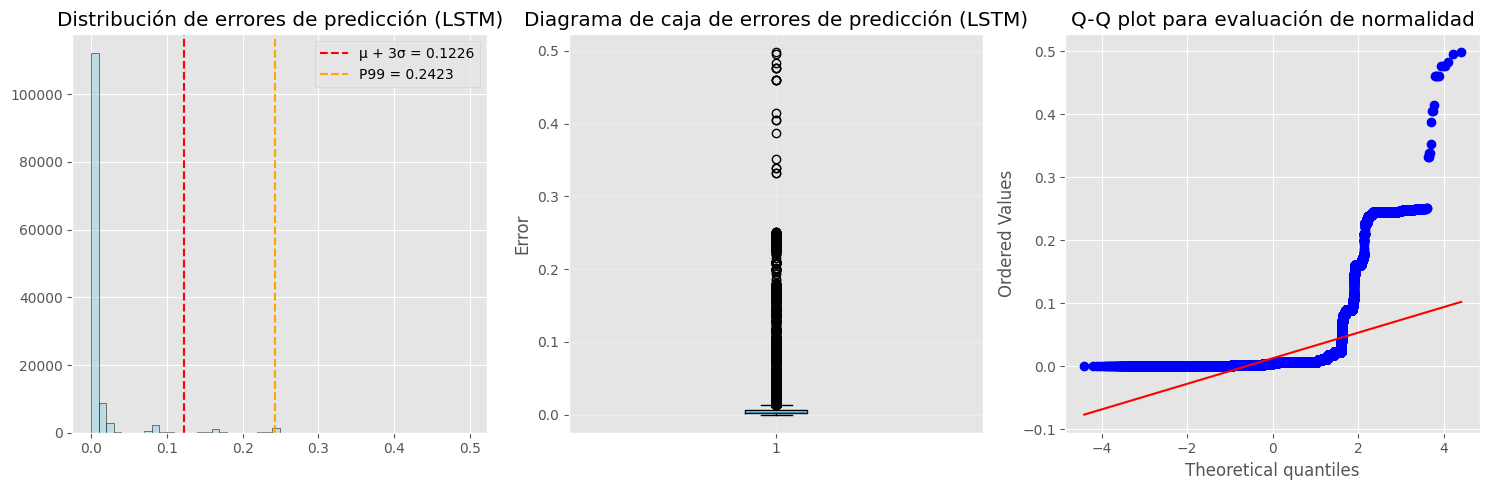

In [ ]:
# =========================================================
# DETECCIÓN DE ANOMALÍAS CON LSTM PREDICTOR
# =========================================================

print("Cálculo de errores de predicción del modelo LSTM...")
y_pred_lstm = model_lstm.predict(X_test, verbose=0)
prediction_errors_lstm = np.abs(y_pred_lstm.flatten() - y_test.flatten())

print("\nEstadísticas de errores de predicción:")
print(f"  Media:        {prediction_errors_lstm.mean():.6f}")
print(f"  Desv. típica: {prediction_errors_lstm.std():.6f}")
print(f"  Percentil 99: {np.percentile(prediction_errors_lstm, 99):.6f}")

threshold_lstm_3sigma = prediction_errors_lstm.mean() + 3 * prediction_errors_lstm.std()
threshold_lstm_p99    = np.percentile(prediction_errors_lstm, 99)

anomalies_lstm_3sigma = prediction_errors_lstm > threshold_lstm_3sigma
anomalies_lstm_p99    = prediction_errors_lstm > threshold_lstm_p99

print(f"\nUmbral μ + 3σ = {threshold_lstm_3sigma:.6f} → {anomalies_lstm_3sigma.sum()} anomalías ({100 * anomalies_lstm_3sigma.mean():.2f}%)")
print(f"Umbral P99    = {threshold_lstm_p99:.6f} → {anomalies_lstm_p99.sum()} anomalías ({100 * anomalies_lstm_p99.mean():.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(prediction_errors_lstm, bins=50, alpha=0.7, color='lightblue', edgecolor='black')
axes[0].axvline(threshold_lstm_3sigma, color='red', linestyle='--', label=f'μ + 3σ = {threshold_lstm_3sigma:.4f}')
axes[0].axvline(threshold_lstm_p99, color='orange', linestyle='--', label=f'P99 = {threshold_lstm_p99:.4f}')
axes[0].set_title('Distribución de errores de predicción (LSTM)')
axes[0].legend()

axes[1].boxplot(prediction_errors_lstm)
axes[1].set_title('Diagrama de caja de errores de predicción (LSTM)')
axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)

stats.probplot(prediction_errors_lstm, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q plot para evaluación de normalidad')

plt.tight_layout()
plt.show()

## 21. Arquitectura del modelo LSTM Autoencoder

En esta etapa se define un segundo enfoque dentro del sistema UEBA, basado en un modelo de tipo autoencoder recurrente. A diferencia de los modelos predictivos previamente descritos, este modelo no persigue estimar valores futuros, sino aprender una representación comprimida de secuencias de comportamiento normal y reconstruirlas posteriormente.

La detección de anomalías se fundamenta en el error de reconstrucción: aquellas secuencias que difieren de los patrones aprendidos durante el entrenamiento presentan mayores desviaciones entre la señal original y la reconstruida.

- **Codificador (encoder):** la arquitectura comienza con dos capas LSTM que procesan la secuencia de entrada y extraen representaciones temporales relevantes. La primera capa devuelve la secuencia completa, mientras que la segunda la comprime en una representación de menor dimensión.

- **Representación latente (bottleneck):** la salida del codificador constituye una representación compacta de la secuencia original, condensando la información temporal en un vector de dimensión reducida.

- **Vector repetido:** la representación latente se replica a lo largo de `LOOKBACK` pasos temporales, permitiendo alimentar el proceso de reconstrucción.

- **Decodificador (decoder):** mediante capas LSTM, el modelo reconstruye la secuencia completa a partir de la representación comprimida, invirtiendo el proceso realizado por el codificador.

- **Capa de salida:** se aplica una capa densa distribuida en el tiempo, generando un valor reconstruido para cada instante de la secuencia.

- **Función de activación:** se emplea la función de activación *tanh*, habitual en arquitecturas LSTM, al ser compatible con la dinámica interna de los estados de memoria.

In [ ]:
np.random.seed(SEED)
tf.random.set_seed(SEED)

def build_lstm_autoencoder():

    input_layer = layers.Input((LOOKBACK, 1), name='input_sequence')

    # ENCODER
    encoded = layers.LSTM(64, return_sequences=True,  activation='tanh')(input_layer)
    encoded = layers.Dropout(0.2)(encoded)
    encoded = layers.LSTM(32, return_sequences=False, activation='tanh')(encoded)

    # BOTTLENECK → DECODER
    decoded = layers.RepeatVector(LOOKBACK)(encoded)
    decoded = layers.LSTM(32, return_sequences=True, activation='tanh')(decoded)
    decoded = layers.Dropout(0.2)(decoded)
    decoded = layers.LSTM(64, return_sequences=True, activation='tanh')(decoded)

    # SALIDA
    output = layers.TimeDistributed(layers.Dense(1, activation='linear'))(decoded)

    autoencoder = Model(input_layer, output, name='LSTM_Autoencoder_UEBA')
    autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return autoencoder

model_ae = build_lstm_autoencoder()
model_ae.summary()


Model: "LSTM_Autoencoder_UEBA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 24, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,529 (244.25 KB)

 Trainable params: 62,529 (244.25 KB)

 Non-trainable params: 0 (0.00 B)

## 22. Entrenamiento del modelo LSTM Autoencoder

En esta fase se lleva a cabo el entrenamiento del modelo LSTM Autoencoder utilizando el conjunto de entrenamiento previamente definido. A diferencia de los modelos predictivos, este enfoque se basa en el aprendizaje no supervisado por reconstrucción, donde el modelo aprende a reproducir las secuencias de entrada sin necesidad de etiquetas de anomalía.

- **Aprendizaje por reconstrucción:** el modelo recibe como entrada las secuencias temporales y tiene como objetivo reconstruir esas mismas secuencias a la salida. De este modo, la función de pérdida mide la capacidad del modelo para reproducir los patrones observados durante el entrenamiento.

- **Aprendizaje del comportamiento normal:** dado que el entrenamiento se realiza exclusivamente sobre el subconjunto de datos más antiguos, el modelo aprende las regularidades asociadas al comportamiento habitual. En consecuencia, las secuencias atípicas presentes en el conjunto de test tienden a generar errores de reconstrucción más elevados.

- **Parada temprana:** se incorpora un mecanismo de *early stopping* basado en la evolución de la pérdida en validación, lo que permite detener el entrenamiento cuando no se observan mejoras y restaurar la configuración de pesos correspondiente al mejor rendimiento alcanzado.

- **Seguimiento del entrenamiento:** se monitorizan la función de pérdida y el error absoluto medio tanto en entrenamiento como en validación, lo que facilita el análisis de la estabilidad del proceso de aprendizaje y la capacidad de generalización del modelo.

Epoch 1/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 192s 57ms/step - loss: 0.0010 - mae: 0.0112 - val_loss: 1.7564e-04 - val_mae: 0.0039
Epoch 2/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 182s 56ms/step - loss: 3.5988e-04 - mae: 0.0049 - val_loss: 7.1584e-05 - val_mae: 0.0022
Epoch 3/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 185s 56ms/step - loss: 3.0202e-04 - mae: 0.0042 - val_loss: 7.2059e-05 - val_mae: 0.0020
Epoch 4/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 183s 56ms/step - loss: 2.8089e-04 - mae: 0.0037 - val_loss: 4.3505e-05 - val_mae: 0.0016
Epoch 5/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 183s 56ms/step - loss: 2.8208e-04 - mae: 0.0037 - val_loss: 4.4393e-05 - val_mae: 0.0017
Epoch 6/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 184s 56ms/step - loss: 2.6599e-04 - mae: 0.0036 - val_loss: 5.5850e-05 - val_mae: 0.0026
Epoch 7/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 185s 57ms/step - loss: 2.1506e-04 - mae: 0.0028 - val_loss: 4.8978e-05 - val_mae: 0.0013
Epoch 8/20
3274/3274 ━━━━━━━━━━━━━━━━━━━━ 186s 57ms/step - loss: 2.0939e-04 - mae: 0.00

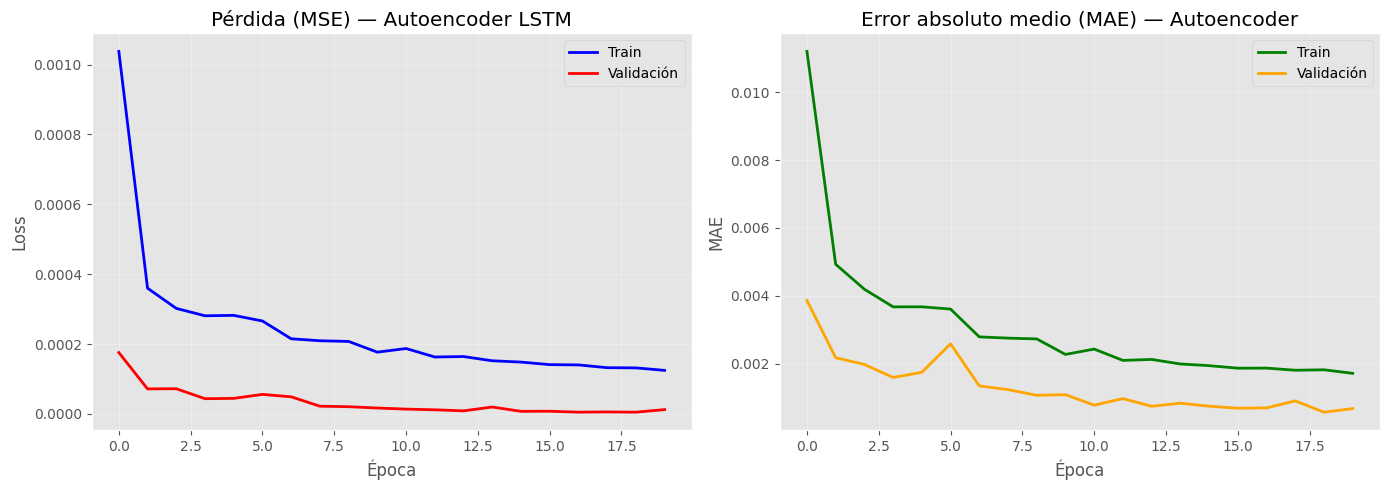

 Entrenamiento completado en 20 épocas


In [ ]:
early_stopping_ae = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_ae = model_ae.fit(
    X_train, X_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping_ae],
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_ae.history['loss'],     label='Train',     linewidth=2, color='blue')
axes[0].plot(history_ae.history['val_loss'], label='Validación', linewidth=2, color='red')
axes[0].set_title('Pérdida (MSE) — Autoencoder LSTM')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_ae.history['mae'],     label='Train',     linewidth=2, color='green')
axes[1].plot(history_ae.history['val_mae'], label='Validación', linewidth=2, color='orange')
axes[1].set_title('Error absoluto medio (MAE) — Autoencoder')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f" Entrenamiento completado en {len(history_ae.history['loss'])} épocas")


## 23. Detección de anomalías mediante error de reconstrucción del autoencoder

En esta etapa se lleva a cabo la identificación de comportamientos anómalos a partir del error de reconstrucción obtenido por el modelo LSTM Autoencoder sobre el conjunto de test. Este enfoque se basa en la capacidad del modelo para reproducir patrones habituales de comportamiento, de modo que aquellas secuencias que difieren de dichos patrones presentan mayores discrepancias entre la señal original y la reconstruida.

- **Reconstrucción de secuencias:** el modelo genera una reconstrucción completa de cada ventana temporal a partir de la representación aprendida durante el entrenamiento. Las secuencias asociadas a comportamientos normales tienden a ser reconstruidas con mayor precisión, mientras que las atípicas presentan errores más elevados.

- **Cálculo del error de reconstrucción:** se emplea una medida agregada del error absoluto medio entre la secuencia original y la reconstruida, promediada a lo largo de los `LOOKBACK` pasos temporales y de la característica considerada. Este procedimiento permite obtener un único valor escalar de error por ventana.

- **Definición de umbrales:** se aplican criterios de detección análogos a los utilizados en el modelo predictivo, basados tanto en la media y desviación estándar de los errores como en percentiles de su distribución. Esto facilita la comparación directa entre ambos enfoques.

- **Análisis visual de reconstrucciones:** se representan gráficamente varias secuencias originales junto con sus respectivas reconstrucciones, lo que permite una interpretación cualitativa del error y una mejor comprensión del comportamiento del modelo frente a patrones normales y anómalos.

Cálculo de errores de reconstrucción...

Estadísticas de errores de reconstrucción:
  Media:        0.000564
  Desv. típica: 0.000936
  Percentil 99: 0.003272

Umbral μ + 3σ = 0.003371 → 1172 anomalías (0.90%)
Umbral P99    = 0.003272 → 1310 anomalías (1.00%)


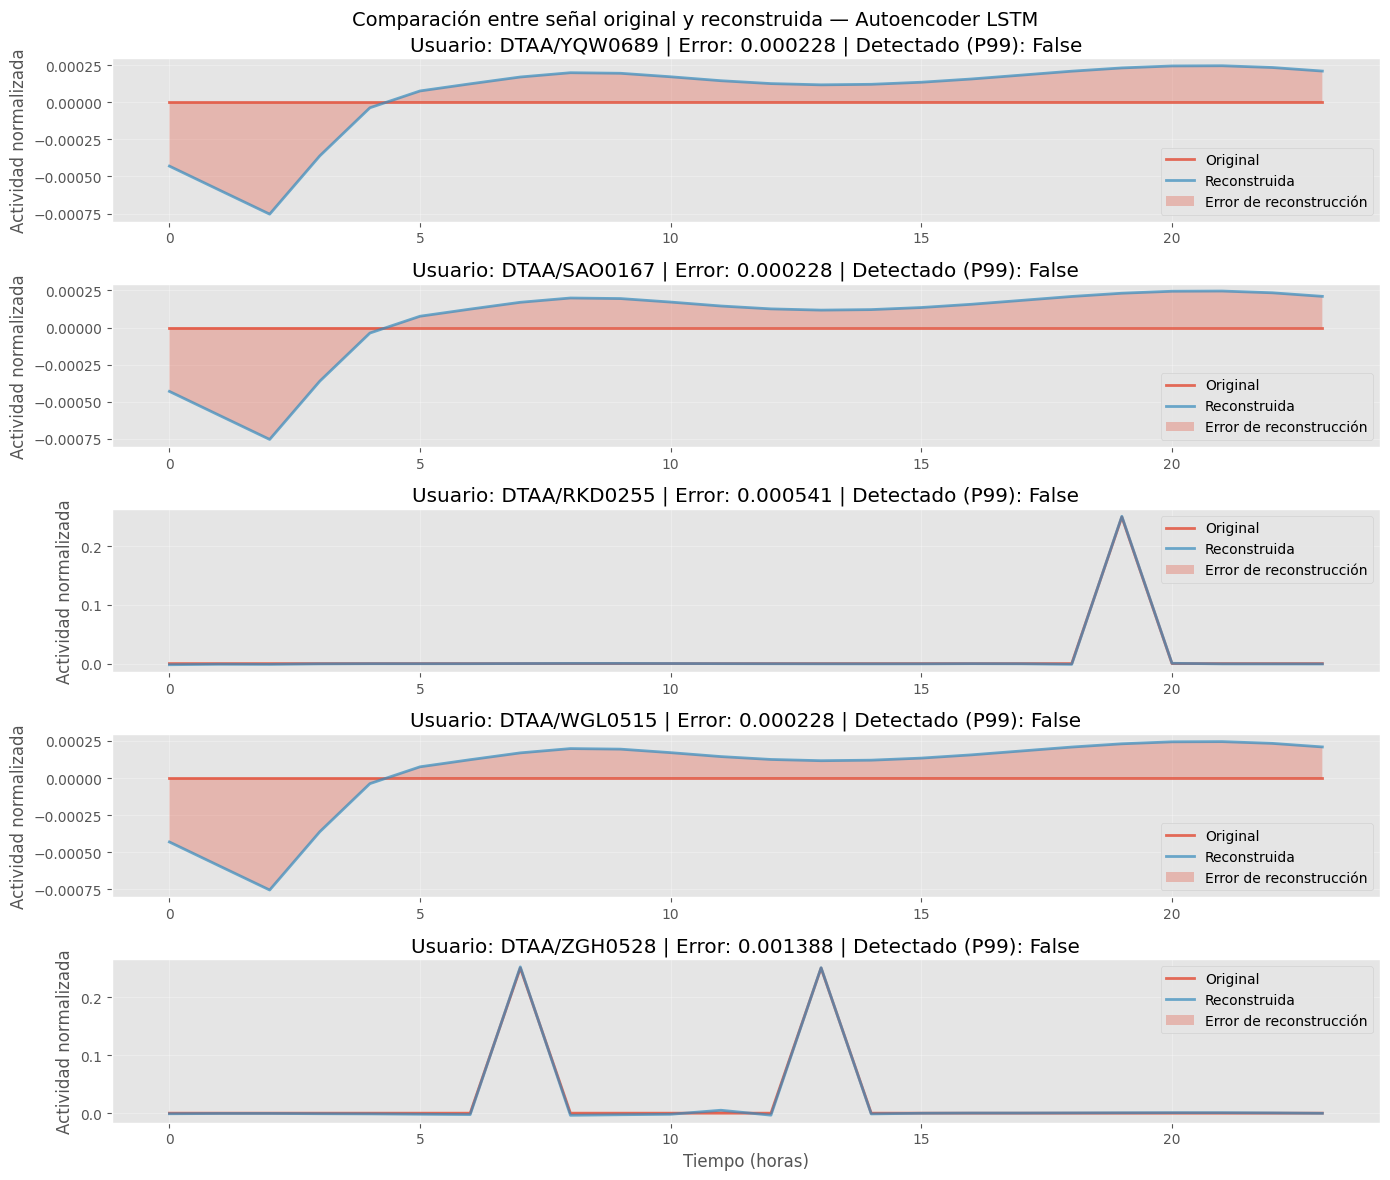

In [ ]:
print("Cálculo de errores de reconstrucción...")
X_reconstructed = model_ae.predict(X_test, verbose=0)
reconstruction_errors = np.mean(np.abs(X_reconstructed - X_test), axis=(1, 2))

print("\nEstadísticas de errores de reconstrucción:")
print(f"  Media:        {reconstruction_errors.mean():.6f}")
print(f"  Desv. típica: {reconstruction_errors.std():.6f}")
print(f"  Percentil 99: {np.percentile(reconstruction_errors, 99):.6f}")

# Umbrales
threshold_ae_3sigma = reconstruction_errors.mean() + 3 * reconstruction_errors.std()
threshold_ae_p99    = np.percentile(reconstruction_errors, 99)

# Clasificación
anomalies_ae_3sigma = reconstruction_errors > threshold_ae_3sigma
anomalies_ae_p99    = reconstruction_errors > threshold_ae_p99

print(f"\nUmbral μ + 3σ = {threshold_ae_3sigma:.6f} → {anomalies_ae_3sigma.sum()} anomalías ({100 * anomalies_ae_3sigma.mean():.2f}%)")
print(f"Umbral P99    = {threshold_ae_p99:.6f} → {anomalies_ae_p99.sum()} anomalías ({100 * anomalies_ae_p99.mean():.2f}%)")

# =========================================================
# VISUALIZACIÓN DE RECONSTRUCCIONES
# =========================================================

sample_indices = np.random.choice(len(X_test), 5)
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for i, idx in enumerate(sample_indices):
    original      = X_test[idx].flatten()
    reconstructed = X_reconstructed[idx].flatten()
    error         = reconstruction_errors[idx]
    user          = users_test[idx]
    detected      = anomalies_ae_p99[idx]

    axes[i].plot(original, label='Original', linewidth=2, alpha=0.8)
    axes[i].plot(reconstructed, label='Reconstruida', linewidth=2, alpha=0.7)
    axes[i].fill_between(
        range(len(original)),
        original,
        reconstructed,
        alpha=0.3,
        label='Error de reconstrucción'
    )

    axes[i].set_title(
        f'Usuario: {user} | Error: {error:.6f} | Detectado (P99): {detected}'
    )
    axes[i].set_ylabel('Actividad normalizada')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[4].set_xlabel('Tiempo (horas)')
plt.suptitle('Comparación entre señal original y reconstruida — Autoencoder LSTM', fontsize=14)
plt.tight_layout()
plt.show()

## 24 — Comparativa

Con el fin de analizar de manera conjunta el comportamiento de los tres enfoques propuestos, se realizó una comparación final entre el modelo GRU predictor, el modelo LSTM predictor y el LSTM Autoencoder. Esta comparación se efectuó considerando tanto las distribuciones de error como el número de anomalías detectadas bajo los mismos criterios de umbralización.

Los resultados permiten identificar diferencias en la sensibilidad de cada arquitectura ante patrones atípicos, así como el grado de solapamiento entre los usuarios señalados por cada modelo. De este modo, la comparación no solo aporta información sobre el rendimiento individual de cada enfoque, sino también sobre su complementariedad dentro del sistema UEBA.

In [ ]:
# =========================================================
# COMPARATIVA FINAL ENTRE GRU, LSTM Y AUTOENCODER
# =========================================================

comparison_df = pd.DataFrame({
    "Modelo": ["GRU predictor", "LSTM predictor", "LSTM Autoencoder"],
    "Media_error": [
        prediction_errors.mean(),
        prediction_errors_lstm.mean(),
        reconstruction_errors.mean()
    ],
    "Std_error": [
        prediction_errors.std(),
        prediction_errors_lstm.std(),
        reconstruction_errors.std()
    ],
    "Max_error": [
        prediction_errors.max(),
        prediction_errors_lstm.max(),
        reconstruction_errors.max()
    ],
    "Umbral_3sigma": [
        threshold_gru_3sigma,
        threshold_lstm_3sigma,
        threshold_ae_3sigma
    ],
    "Umbral_P99": [
        threshold_gru_p99,
        threshold_lstm_p99,
        threshold_ae_p99
    ],
    "Anomalias_3sigma": [
        anomalies_gru_3sigma.sum(),
        anomalies_lstm_3sigma.sum(),
        anomalies_ae_3sigma.sum()
    ],
    "Anomalias_P99": [
        anomalies_gru_p99.sum(),
        anomalies_lstm_p99.sum(),
        anomalies_ae_p99.sum()
    ],
    "Porcentaje_3sigma": [
        100 * anomalies_gru_3sigma.mean(),
        100 * anomalies_lstm_3sigma.mean(),
        100 * anomalies_ae_3sigma.mean()
    ],
    "Porcentaje_P99": [
        100 * anomalies_gru_p99.mean(),
        100 * anomalies_lstm_p99.mean(),
        100 * anomalies_ae_p99.mean()
    ]
})

print("Comparativa global entre modelos:")
print(comparison_df.round(4).to_string(index=False))

Comparativa global entre modelos:
          Modelo  Media_error  Std_error  Max_error  Umbral_3sigma  Umbral_P99  Anomalias_3sigma  Anomalias_P99  Porcentaje_3sigma  Porcentaje_P99
   GRU predictor       0.0136     0.0384     0.9877         0.1289      0.2380              3817           1285             2.9142          0.9811
  LSTM predictor       0.0125     0.0367     0.4978         0.1226      0.2423              3784           1310             2.8899          1.0005
LSTM Autoencoder       0.0006     0.0009     0.0561         0.0034      0.0033              1172           1310             0.8951          1.0005


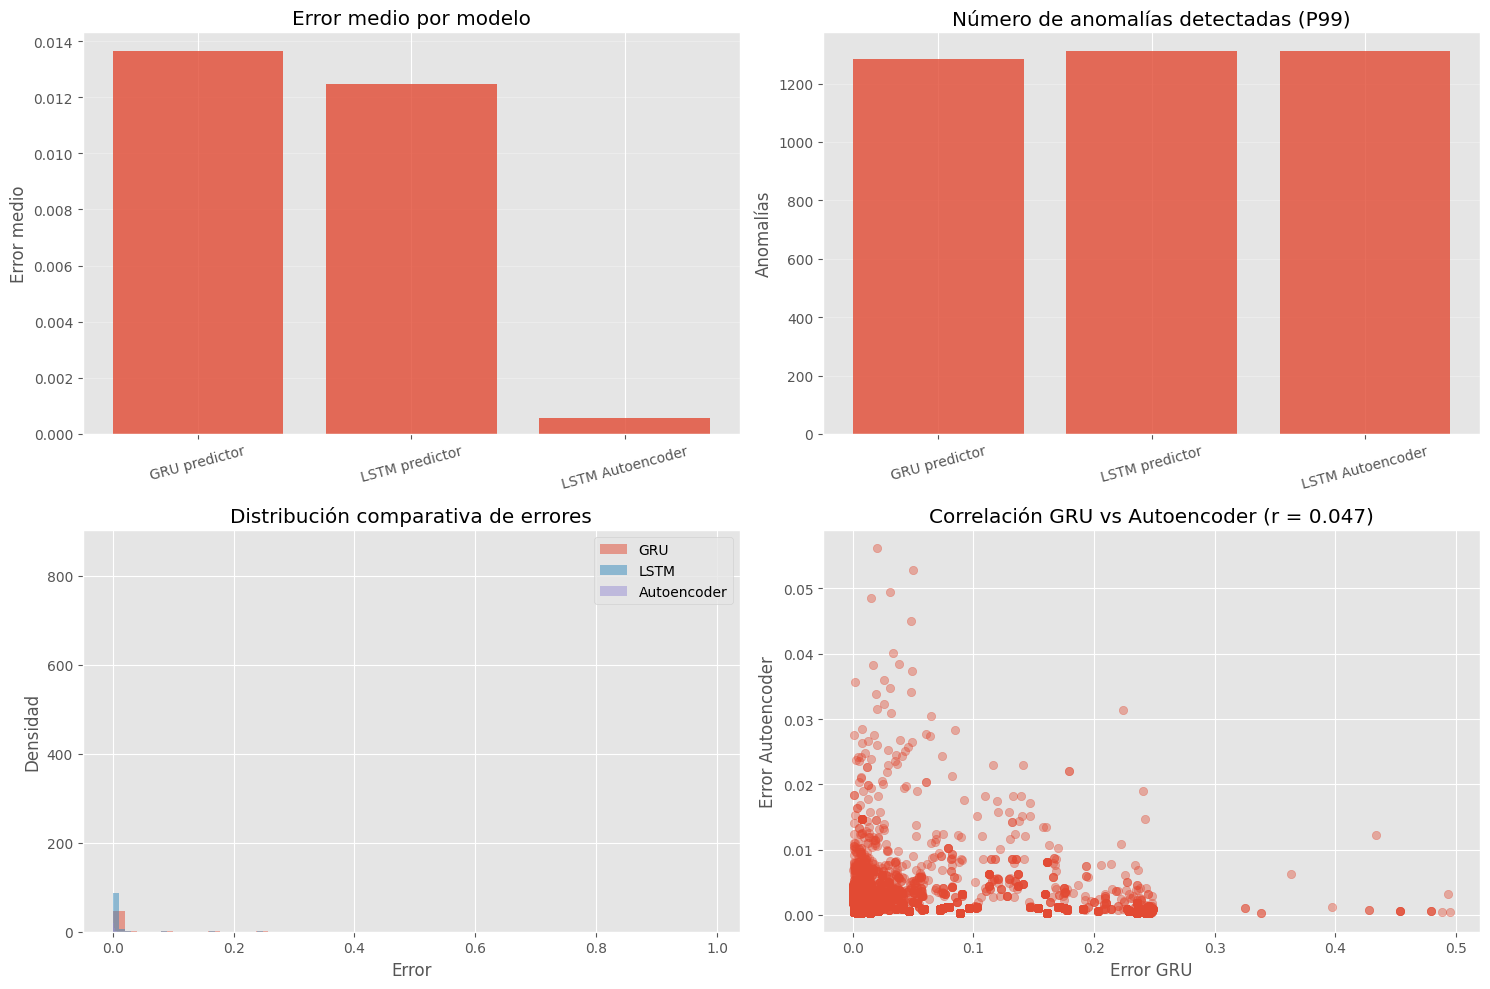

In [ ]:
# =========================================================
# VISUALIZACIÓN COMPARATIVA ENTRE MODELOS
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Media de error
axes[0, 0].bar(
    comparison_df["Modelo"],
    comparison_df["Media_error"],
    alpha=0.8
)
axes[0, 0].set_title("Error medio por modelo")
axes[0, 0].set_ylabel("Error medio")
axes[0, 0].grid(True, alpha=0.3, axis="y")
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Número de anomalías con P99
axes[0, 1].bar(
    comparison_df["Modelo"],
    comparison_df["Anomalias_P99"],
    alpha=0.8
)
axes[0, 1].set_title("Número de anomalías detectadas (P99)")
axes[0, 1].set_ylabel("Anomalías")
axes[0, 1].grid(True, alpha=0.3, axis="y")
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Distribución comparativa de errores
axes[1, 0].hist(prediction_errors, bins=50, alpha=0.5, label="GRU", density=True)
axes[1, 0].hist(prediction_errors_lstm, bins=50, alpha=0.5, label="LSTM", density=True)
axes[1, 0].hist(reconstruction_errors, bins=50, alpha=0.5, label="Autoencoder", density=True)
axes[1, 0].set_title("Distribución comparativa de errores")
axes[1, 0].set_xlabel("Error")
axes[1, 0].set_ylabel("Densidad")
axes[1, 0].legend()

# 4. Correlación entre errores GRU y Autoencoder
correlation_gru_ae = np.corrcoef(prediction_errors[:len(reconstruction_errors)], reconstruction_errors)[0, 1]

axes[1, 1].scatter(
    prediction_errors[:len(reconstruction_errors)],
    reconstruction_errors,
    alpha=0.4
)
axes[1, 1].set_title(f"Correlación GRU vs Autoencoder (r = {correlation_gru_ae:.3f})")
axes[1, 1].set_xlabel("Error GRU")
axes[1, 1].set_ylabel("Error Autoencoder")

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# USUARIOS DETECTADOS POR CADA MODELO
# =========================================================

users_gru_p99 = set(users_test_eval[anomalies_gru_p99])
users_lstm_p99 = set(users_test[anomalies_lstm_p99])
users_ae_p99 = set(users_test[anomalies_ae_p99])

print("Usuarios detectados con anomalías (P99):")
print(f"  GRU:          {len(users_gru_p99)}")
print(f"  LSTM:         {len(users_lstm_p99)}")
print(f"  Autoencoder:  {len(users_ae_p99)}")

print("\nSolapamiento entre modelos:")
print(f"  GRU ∩ LSTM:         {len(users_gru_p99 & users_lstm_p99)}")
print(f"  GRU ∩ Autoencoder:  {len(users_gru_p99 & users_ae_p99)}")
print(f"  LSTM ∩ Autoencoder: {len(users_lstm_p99 & users_ae_p99)}")
print(f"  GRU ∩ LSTM ∩ AE:    {len(users_gru_p99 & users_lstm_p99 & users_ae_p99)}")

Usuarios detectados con anomalías (P99):
  GRU:          229
  LSTM:         189
  Autoencoder:  58

Solapamiento entre modelos:
  GRU ∩ LSTM:         189
  GRU ∩ Autoencoder:  58
  LSTM ∩ Autoencoder: 58
  GRU ∩ LSTM ∩ AE:    58


In [ ]:
# =========================================================
# FILTRAR SOLO DATOS REALES (excluir sintéticos en GRU)
# =========================================================

gru_real_mask = ~synthetic_mask

gru_anomalies_real = anomalies_gru_p99[gru_real_mask]

# =========================================================
# TABLA DE COMPARACIÓN ENTRE MODELOS
# =========================================================

user_comparison_df = pd.DataFrame({
    "user": users_test,
    "gru_p99": gru_anomalies_real.astype(int),
    "lstm_p99": anomalies_lstm_p99.astype(int),
    "ae_p99": anomalies_ae_p99.astype(int)
})

# =========================================================
# AGREGACIÓN A NIVEL USUARIO
# =========================================================

user_model_summary = (
    user_comparison_df.groupby("user")[["gru_p99", "lstm_p99", "ae_p99"]]
    .sum()
    .reset_index()
)

# Variables booleanas
user_model_summary["detected_by_gru"]  = user_model_summary["gru_p99"] > 0
user_model_summary["detected_by_lstm"] = user_model_summary["lstm_p99"] > 0
user_model_summary["detected_by_ae"]   = user_model_summary["ae_p99"] > 0

print("Resumen por usuario:")
print(user_model_summary.head(20).to_string(index=False))

Resumen por usuario:
        user  gru_p99  lstm_p99  ae_p99  detected_by_gru  detected_by_lstm  detected_by_ae
DTAA/RKC0733        3         3       0             True              True           False
DTAA/RKD0255        4         4       0             True              True           False
DTAA/RLC0019        7         7       0             True              True           False
DTAA/RLC0442        4         4       0             True              True           False
DTAA/RLE0844        4         4       0             True              True           False
DTAA/RLS0935        4         4       0             True              True           False
DTAA/RLS0966        4         4       0             True              True           False
DTAA/RLW0861        9         9       0             True              True           False
DTAA/RME0699       16        19      35             True              True            True
DTAA/ROC0257        4         4       0             True             

## 25. Ranking UEBA de usuarios

En esta fase se realiza la agregación de los resultados obtenidos a nivel de ventana temporal para construir una representación consolidada a nivel de usuario. Este procedimiento permite transformar las detecciones puntuales generadas por los distintos modelos en un ranking global de riesgo, orientado a la priorización de usuarios potencialmente anómalos dentro del sistema UEBA.

- **Agregación a nivel de usuario:** para cada usuario se calculan estadísticas descriptivas de los errores generados por los modelos, incluyendo media, máximo, desviación típica y número de observaciones. Asimismo, se contabiliza el número total de ventanas clasificadas como anómalas por cada enfoque de detección.

- **Construcción de un score combinado:** con el objetivo de sintetizar la información proporcionada por los distintos modelos, se define un indicador agregado de anomalía. En este caso, el error de reconstrucción del autoencoder recibe un peso superior al del modelo GRU, al considerar que las anomalías persistentes en patrones temporales completos pueden resultar más representativas de comportamientos anómalos sostenidos que las desviaciones puntuales de predicción.

- **Generación del ranking final:** los usuarios se ordenan de forma descendente según el score combinado de anomalía. De este modo, las primeras posiciones del ranking corresponden a aquellos perfiles que presentan una mayor acumulación de evidencias anómalas y que, por tanto, constituirían los casos prioritarios para su revisión por parte del analista de seguridad.

In [ ]:
# =========================================================
# PASO 25 - RANKING UEBA DE USUARIOS
# =========================================================

# Filtrar únicamente las observaciones reales del GRU
gru_real_mask = ~synthetic_mask

prediction_errors_gru_real = prediction_errors[gru_real_mask]
anomalies_gru_3sigma_real  = anomalies_gru_3sigma[gru_real_mask]
anomalies_gru_p99_real     = anomalies_gru_p99[gru_real_mask]

# Construcción del DataFrame unificado
scores_df = pd.DataFrame({
    'user':                 users_test,
    'prediction_error':     prediction_errors_gru_real,
    'reconstruction_error': reconstruction_errors,
    'anomaly_gru_3s':       anomalies_gru_3sigma_real,
    'anomaly_gru_p99':      anomalies_gru_p99_real,
    'anomaly_ae_3s':        anomalies_ae_3sigma,
    'anomaly_ae_p99':       anomalies_ae_p99
})

# Agregación a nivel de usuario
user_anomaly_summary = (
    scores_df.groupby('user').agg({
        'prediction_error':     ['mean', 'max', 'std', 'count'],
        'reconstruction_error': ['mean', 'max', 'std'],
        'anomaly_gru_3s': 'sum',
        'anomaly_gru_p99': 'sum',
        'anomaly_ae_3s':  'sum',
        'anomaly_ae_p99': 'sum'
    }).round(6)
)

user_anomaly_summary.columns = [
    'pred_mean', 'pred_max', 'pred_std', 'pred_count',
    'rec_mean',  'rec_max',  'rec_std',
    'anom_gru_3s', 'anom_gru_p99', 'anom_ae_3s', 'anom_ae_p99'
]

# Score combinado de anomalía
user_anomaly_summary['anomaly_score'] = (
    user_anomaly_summary['anom_ae_3s'] +
    user_anomaly_summary['anom_gru_3s'] * 0.5
)

ranking = user_anomaly_summary.sort_values('anomaly_score', ascending=False)

print("Top 25 usuarios con mayor score de anomalía:")
print(ranking.head(25))

print("\nResumen del ranking UEBA:")
print(f"  Usuarios totales analizados:        {len(ranking)}")
print(f"  Usuarios con anomalías GRU (3σ):    {(ranking['anom_gru_3s'] > 0).sum()}")
print(f"  Usuarios con anomalías AE (3σ):     {(ranking['anom_ae_3s'] > 0).sum()}")
print(f"  Usuarios detectados por ambos:      {((ranking['anom_gru_3s'] > 0) & (ranking['anom_ae_3s'] > 0)).sum()}")

Top 25 usuarios con mayor score de anomalía:
              pred_mean  pred_max  pred_std  pred_count  rec_mean   rec_max  \
user                                                                          
DTAA/STF0145   0.019238  0.248977  0.045860         695  0.001467  0.030460   
DTAA/TPC0102   0.021431  0.453455  0.051173         695  0.002057  0.044976   
DTAA/TGC0670   0.019164  0.453455  0.048832         695  0.001229  0.013543   
DTAA/SJH0588   0.018939  0.247378  0.046227         695  0.001222  0.038410   
DTAA/VFP0669   0.019765  0.246477  0.047579         695  0.001236  0.013528   
DTAA/ZAB0889   0.021310  0.248852  0.052489         695  0.001267  0.038326   
DTAA/SAH0192   0.018311  0.248593  0.044948         695  0.001126  0.017546   
DTAA/TKH0211   0.018612  0.248593  0.045769         695  0.001285  0.027712   
DTAA/SRN0275   0.021600  0.495077  0.053802         695  0.001760  0.056133   
DTAA/SHR0025   0.021243  0.324914  0.052661         695  0.001174  0.023125   
DTAA/XQ

## 26 — Representación gráfica del ranking

La representación gráfica del ranking no solo permite identificar la presencia de comportamientos anómalos, sino también asignar a cada usuario una medida relativa de riesgo. De este modo, el sistema deja de ofrecer una salida exclusivamente binaria, anomalía frente a normalidad, y proporciona una graduación de severidad asociada a cada perfil. Esta aproximación resulta especialmente útil en entornos de seguridad, ya que no todos los usuarios detectados presentan el mismo nivel de criticidad. Por ejemplo, un usuario con una puntuación de riesgo de 0.60 puede considerarse prioritario frente a otro con una puntuación de 0.20, aun cuando ambos hayan sido señalados como potencialmente anómalos. Así, el analista de seguridad dispone de un criterio cuantitativo para ordenar la revisión de casos.

Este enfoque permite transformar la detección de anomalías en un mecanismo de priorización, facilitando una gestión más eficiente del proceso de investigación. En lugar de tratar todas las alertas con la misma relevancia, el sistema introduce una jerarquía de riesgo que contribuye a reducir la sobrecarga operativa, mejorar el filtrado de usuarios y optimizar el tiempo de análisis. En consecuencia, los casos con mayor puntuación pueden revisarse en primer lugar, mientras que aquellos con menor riesgo pueden quedar relegados a una revisión posterior o complementaria.

In [ ]:
ranking["risk_score"] = (
    ranking["anomaly_score"] - ranking["anomaly_score"].min()
) / (
    ranking["anomaly_score"].max() - ranking["anomaly_score"].min()
)

ranking["risk_percent"] = ranking["risk_score"] * 100

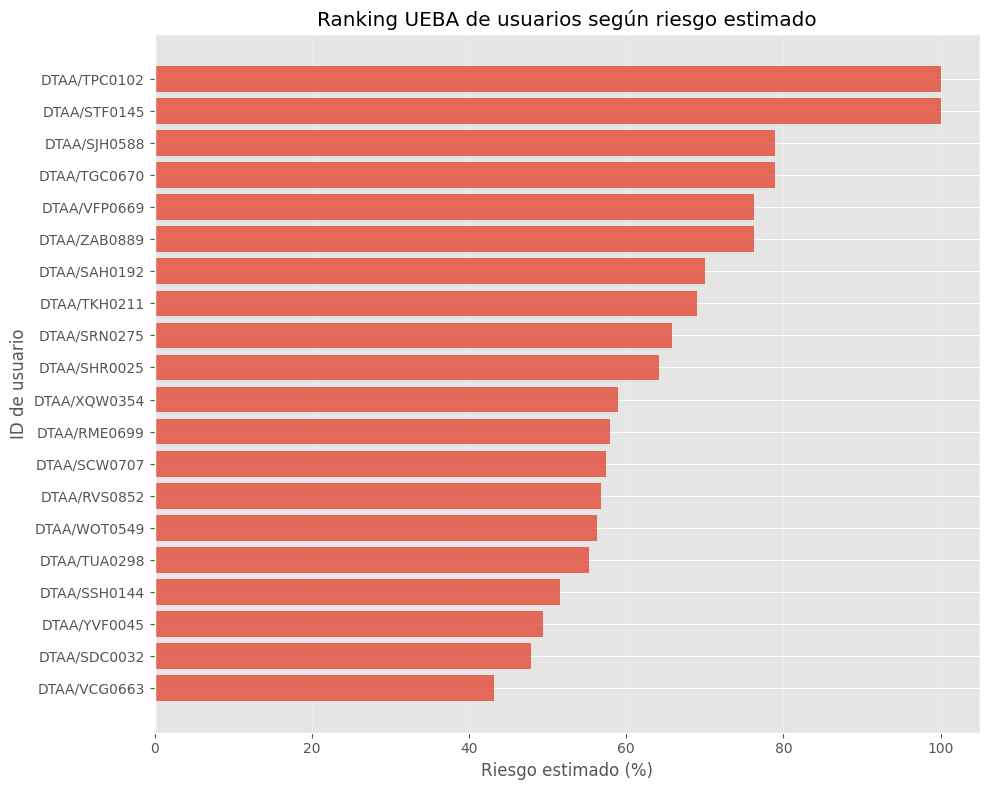

In [ ]:
top_n = 20
ranking_plot = ranking.head(top_n).copy().sort_values("risk_percent", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(ranking_plot.index.astype(str), ranking_plot["risk_percent"], alpha=0.8)
plt.xlabel("Riesgo estimado (%)")
plt.ylabel("ID de usuario")
plt.title("Ranking UEBA de usuarios según riesgo estimado")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 27. Segmentación de usuarios mediante técnicas de clustering (K-Means)

En esta fase se aplica un algoritmo de agrupamiento no supervisado, concretamente K-Means, con el objetivo de segmentar a los usuarios en función de sus patrones de comportamiento anómalo. Esta aproximación permite identificar perfiles diferenciados dentro del sistema UEBA, facilitando una interpretación más estructurada de los resultados obtenidos en etapas previas.

- **Normalización de variables:** previamente a la aplicación del algoritmo, se emplea un proceso de estandarización mediante *StandardScaler*, que transforma las variables para que presenten media cero y desviación típica unitaria. Este paso resulta fundamental en el contexto de K-Means, dado que el algoritmo se basa en distancias euclídeas y, por tanto, es sensible a la escala de las variables. La normalización garantiza que todas las características contribuyan de forma equilibrada al proceso de agrupamiento.

- **Determinación del número óptimo de clusters:** se utiliza el método del codo (*elbow method*) para evaluar el comportamiento de la inercia (suma de las distancias cuadráticas de cada punto a su centroide) en función del número de clusters. El punto de inflexión de la curva permite identificar un valor adecuado de *k*, equilibrando la capacidad explicativa del modelo y la simplicidad de la segmentación.

- **Selección del número de grupos:** en este caso, se adopta una solución de tres clusters, que permite una interpretación coherente de los perfiles de usuario. De manera general, estos grupos tienden a corresponder a: (i) usuarios con comportamiento normal o bajo nivel de anomalía, (ii) usuarios con patrones moderadamente atípicos y (iii) usuarios con alta concentración de anomalías, considerados de mayor riesgo.

- **Interpretación de los clusters:** para facilitar el análisis de los perfiles obtenidos, se emplea una representación tipo *heatmap* que muestra los valores promedio de las variables de interés en cada cluster. Esta visualización permite identificar las características que definen a cada grupo y comprender las diferencias en términos de comportamiento anómalo.

En conjunto, la aplicación de técnicas de clustering complementa el análisis individual de usuarios, aportando una visión global de la estructura del comportamiento dentro del sistema y permitiendo la identificación de patrones colectivos de riesgo.

        pred_mean rec_mean anom_gru_3s anom_ae_3s anomaly_score      
             mean     mean         sum        sum          mean count
cluster                                                              
0          0.0167   0.0007        1356        165       19.1591    44
1          0.0111   0.0004        1562         57        6.8130   123
2          0.0200   0.0012         859        950       62.7045    22


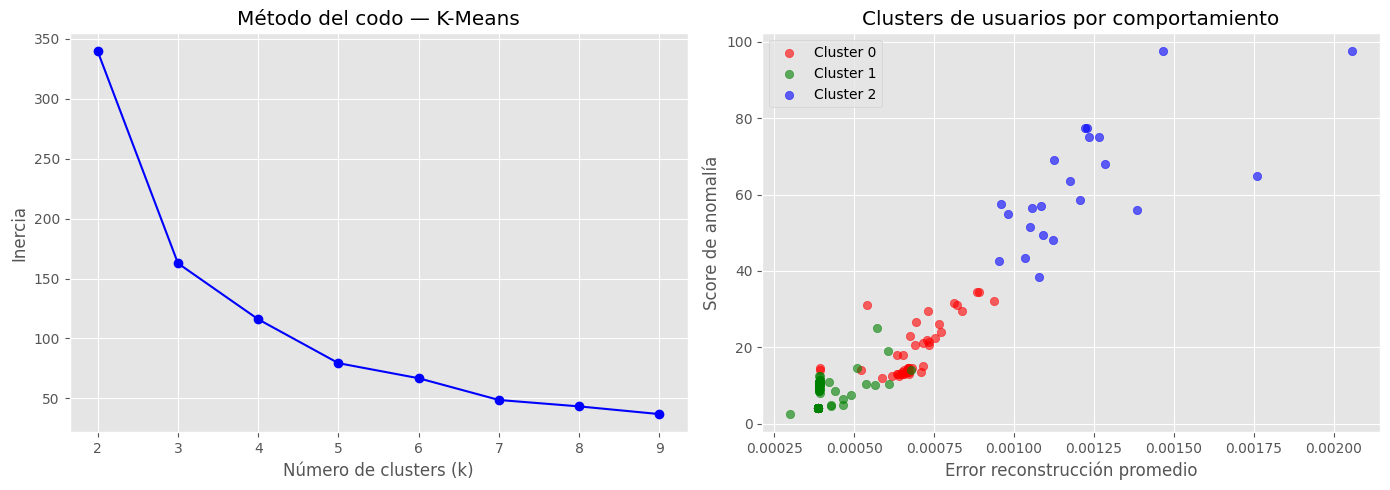

In [ ]:
clustering_features = ranking[['pred_mean', 'rec_mean',
                                'anom_gru_3s', 'anom_ae_3s', 'anomaly_score']]

scaler_cluster = StandardScaler()
clustering_data_scaled = scaler_cluster.fit_transform(clustering_features)

inertias = []
K_range  = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED)
    kmeans.fit(clustering_data_scaled)
    inertias.append(kmeans.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Método del codo — K-Means')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True)

optimal_k    = 3
kmeans_users = KMeans(n_clusters=optimal_k, random_state=SEED)
user_clusters = kmeans_users.fit_predict(clustering_data_scaled)
ranking['cluster'] = user_clusters

cluster_summary = ranking.groupby('cluster').agg({
    'pred_mean':     'mean',
    'rec_mean':      'mean',
    'anom_gru_3s':   'sum',
    'anom_ae_3s':    'sum',
    'anomaly_score': ['mean', 'count']
}).round(4)
print(cluster_summary)

colors = ['red', 'green', 'blue']
for i in range(optimal_k):
    cluster_data = clustering_features[ranking['cluster'] == i]
    axes[1].scatter(cluster_data['rec_mean'], cluster_data['anomaly_score'],
                    c=colors[i], label=f'Cluster {i}', alpha=0.6)

axes[1].set_xlabel('Error reconstrucción promedio')
axes[1].set_ylabel('Score de anomalía')
axes[1].set_title('Clusters de usuarios por comportamiento')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 28. Análisis detallado del usuario con mayor nivel de anomalía

En esta etapa se lleva a cabo un análisis específico del usuario que presenta el valor más elevado de `anomaly_score`, con el fin de examinar en profundidad su comportamiento y contextualizar su posición dentro del conjunto global de usuarios evaluados. Este análisis combina información temporal, métricas de anomalía y representaciones comparativas respecto al resto de perfiles observados.

- **Serie temporal completa:** se examina la evolución de la actividad del usuario a lo largo de todo el periodo analizado, lo que permite identificar visualmente episodios de actividad especialmente intensa o desviaciones relevantes respecto a su comportamiento habitual.

- **Perfil promedio por hora del día:** se calcula la actividad media del usuario para cada franja horaria, agregando todas las observaciones correspondientes a una misma hora del día. Esta representación permite determinar si la actividad en horarios atípicos responde a un patrón persistente o a eventos puntuales.

- **Representación bidimensional de errores:** se sitúa al usuario dentro del espacio definido por el error de predicción del modelo GRU y el error de reconstrucción del autoencoder, comparándolo con el resto de usuarios. Esta visualización permite evaluar su grado de separación respecto al comportamiento considerado habitual.

- **Contextualización respecto a su grupo de pertenencia:** se analiza la posición del usuario dentro del cluster asignado en la fase anterior, comparando su perfil de anomalía con las características promedio de dicho grupo. Este procedimiento facilita una interpretación más precisa de la naturaleza de su comportamiento.

En conjunto, este análisis detallado permite complementar el ranking global de anomalías con una interpretación cualitativa del caso más relevante, proporcionando una visión más completa del tipo de comportamiento que el sistema UEBA identifica como prioritario.

Usuario con mayor score de anomalía:
DTAA/STF0145

Resumen de métricas principales:
pred_mean         0.019238
rec_mean          0.001467
anom_gru_3s      35.000000
anom_ae_3s       80.000000
anomaly_score    97.500000
Name: DTAA/STF0145, dtype: float64


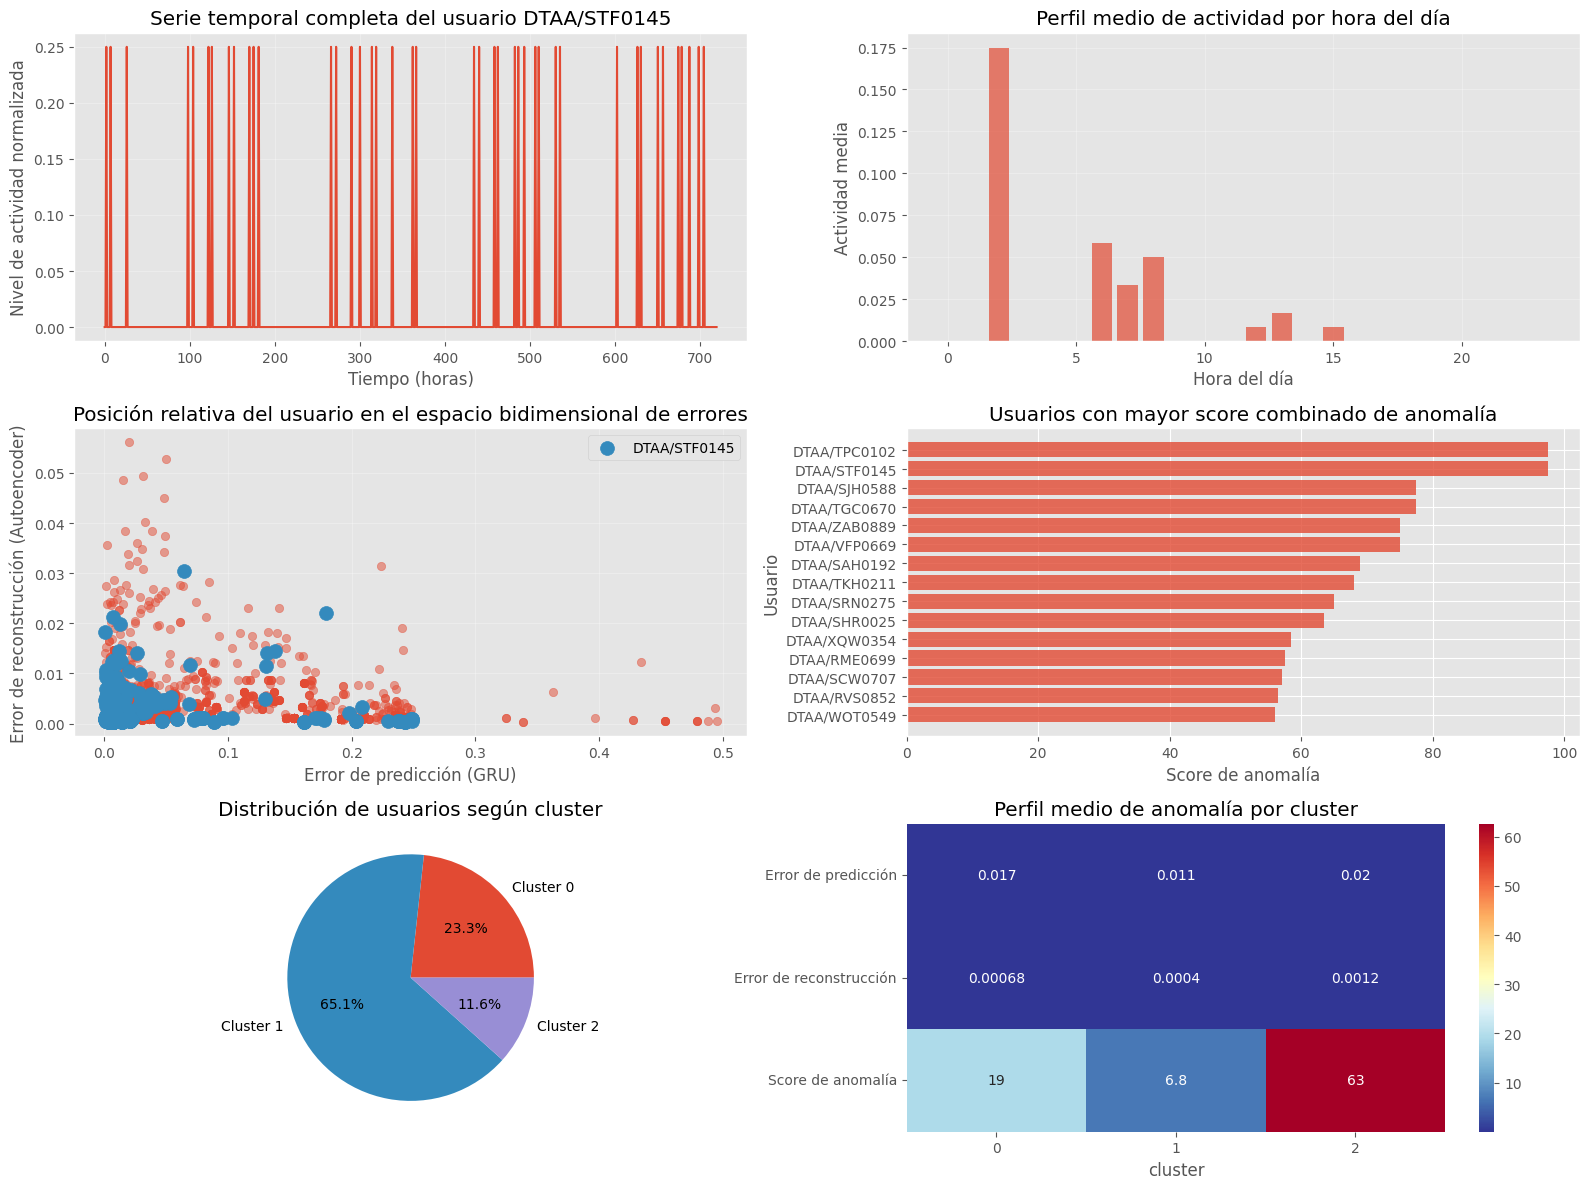

In [ ]:
top_anomalous_user = ranking.index[0]

print("Usuario con mayor score de anomalía:")
print(top_anomalous_user)

print("\nResumen de métricas principales:")
print(
    ranking.iloc[0][['pred_mean', 'rec_mean', 'anom_gru_3s', 'anom_ae_3s', 'anomaly_score']]
)

top_user_series = user_series[top_anomalous_user]
timespan_hours = len(top_user_series.flatten())

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# =========================================================
# Serie temporal completa del usuario más anómalo
# =========================================================
axes[0, 0].plot(top_user_series.flatten(), linewidth=1.5)
axes[0, 0].set_title(f'Serie temporal completa del usuario {top_anomalous_user}')
axes[0, 0].set_ylabel('Nivel de actividad normalizada')
axes[0, 0].set_xlabel('Tiempo (horas)')
axes[0, 0].grid(True, alpha=0.3)

# =========================================================
# Perfil medio por hora del día
# =========================================================
daily_pattern = []
for hour in range(24):
    hour_values = [top_user_series[i] for i in range(hour, timespan_hours, 24)]
    daily_pattern.append(np.mean(hour_values))

axes[0, 1].bar(range(24), daily_pattern, alpha=0.7)
axes[0, 1].set_title('Perfil medio de actividad por hora del día')
axes[0, 1].set_xlabel('Hora del día')
axes[0, 1].set_ylabel('Actividad media')
axes[0, 1].grid(True, alpha=0.3)

# =========================================================
# Posición del usuario en el espacio de errores
# =========================================================
axes[1, 0].scatter(
    scores_df['prediction_error'],
    scores_df['reconstruction_error'],
    alpha=0.5
)

axes[1, 0].scatter(
    scores_df.loc[scores_df['user'] == top_anomalous_user, 'prediction_error'],
    scores_df.loc[scores_df['user'] == top_anomalous_user, 'reconstruction_error'],
    s=100,
    label=top_anomalous_user
)

axes[1, 0].set_xlabel('Error de predicción (GRU)')
axes[1, 0].set_ylabel('Error de reconstrucción (Autoencoder)')
axes[1, 0].set_title('Posición relativa del usuario en el espacio bidimensional de errores')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# =========================================================
# Ranking de los 15 usuarios con mayor score de anomalía
# =========================================================
top_15 = ranking.head(15).sort_values('anomaly_score', ascending=True)

axes[1, 1].barh(top_15.index.astype(str), top_15['anomaly_score'], alpha=0.8)
axes[1, 1].set_title('Usuarios con mayor score combinado de anomalía')
axes[1, 1].set_xlabel('Score de anomalía')
axes[1, 1].set_ylabel('Usuario')

# =========================================================
# Distribución de usuarios por cluster
# =========================================================
cluster_counts = ranking['cluster'].value_counts().sort_index()

axes[2, 0].pie(
    cluster_counts.values,
    labels=[f'Cluster {i}' for i in cluster_counts.index],
    autopct='%1.1f%%'
)
axes[2, 0].set_title('Distribución de usuarios según cluster')

# =========================================================
# Perfil medio de anomalía por cluster
# =========================================================
cluster_heatmap = ranking.groupby('cluster')[['pred_mean', 'rec_mean', 'anomaly_score']].mean()

sns.heatmap(cluster_heatmap.T, annot=True, cmap='RdYlBu_r', ax=axes[2, 1])
axes[2, 1].set_title('Perfil medio de anomalía por cluster')
axes[2, 1].set_yticklabels([
    'Error de predicción',
    'Error de reconstrucción',
    'Score de anomalía'
], rotation=0)

plt.tight_layout()
plt.show()

## 29. Análisis de casos específicos de alto riesgo

Con el objetivo de complementar el ranking basado en métricas cuantitativas de anomalía, se incorporan indicadores contextuales asociados al comportamiento potencialmente sospechoso en entornos de ciberseguridad. Esta integración permite enriquecer la interpretación de los resultados mediante la consideración de factores temporales relevantes.

- **Actividad en horario nocturno:** se analiza la presencia de actividad en franjas horarias comprendidas entre las 03:00 y las 06:00. Este intervalo se considera especialmente significativo al situarse fuera del horario laboral habitual en la mayoría de contextos organizacionales, así como por su asociación con periodos de menor supervisión. En consecuencia, la actividad en estas horas puede constituir un indicador adicional de comportamiento atípico.

- **Actividad en fines de semana:** de forma complementaria, se evalúa la existencia de accesos o actividad durante sábados y domingos. Al igual que en el caso anterior, estos periodos suelen caracterizarse por una menor actividad legítima y una reducción de los mecanismos de control, lo que puede incrementar la relevancia de cualquier comportamiento registrado en dichos intervalos.

- **Integración con el ranking de anomalía:** la combinación de los indicadores contextuales con el `anomaly_score` permite identificar usuarios que cumplen múltiples criterios de sospecha. En particular, aquellos perfiles que presentan simultáneamente un alto nivel de anomalía y actividad en horarios o periodos atípicos constituyen casos de especial interés, al reducir la probabilidad de falsos positivos en comparación con el uso aislado de cada indicador.

Usuarios con mayor actividad nocturna (03:00–06:00):
user
DTAA/CGM0994    24
DTAA/CLB0995    23
DTAA/JHA0404    22
DTAA/NLD0701    21
DTAA/NHH0566    21
DTAA/EBP0037    21
DTAA/CBP0628    21
DTAA/AJS0917    21
DTAA/IGC0415    21
DTAA/LSV0944    21
Name: count, dtype: int64

Usuarios con mayor actividad en fin de semana:
user
DTAA/MIC0914    2
DTAA/SDC0032    2
DTAA/TKH0211    1
DTAA/NHL0253    1
DTAA/SAH0192    1
DTAA/RAH0968    1
DTAA/RAC0282    1
DTAA/FKR0550    1
DTAA/PCM0846    1
DTAA/CHA0174    1
Name: count, dtype: int64

Usuarios de alto riesgo con actividad nocturna y alta puntuación de anomalía:
[]

Usuarios de alto riesgo con actividad en fin de semana y alta puntuación de anomalía:
['DTAA/SRN0275', 'DTAA/SAH0192', 'DTAA/TKH0211', 'DTAA/SDC0032']


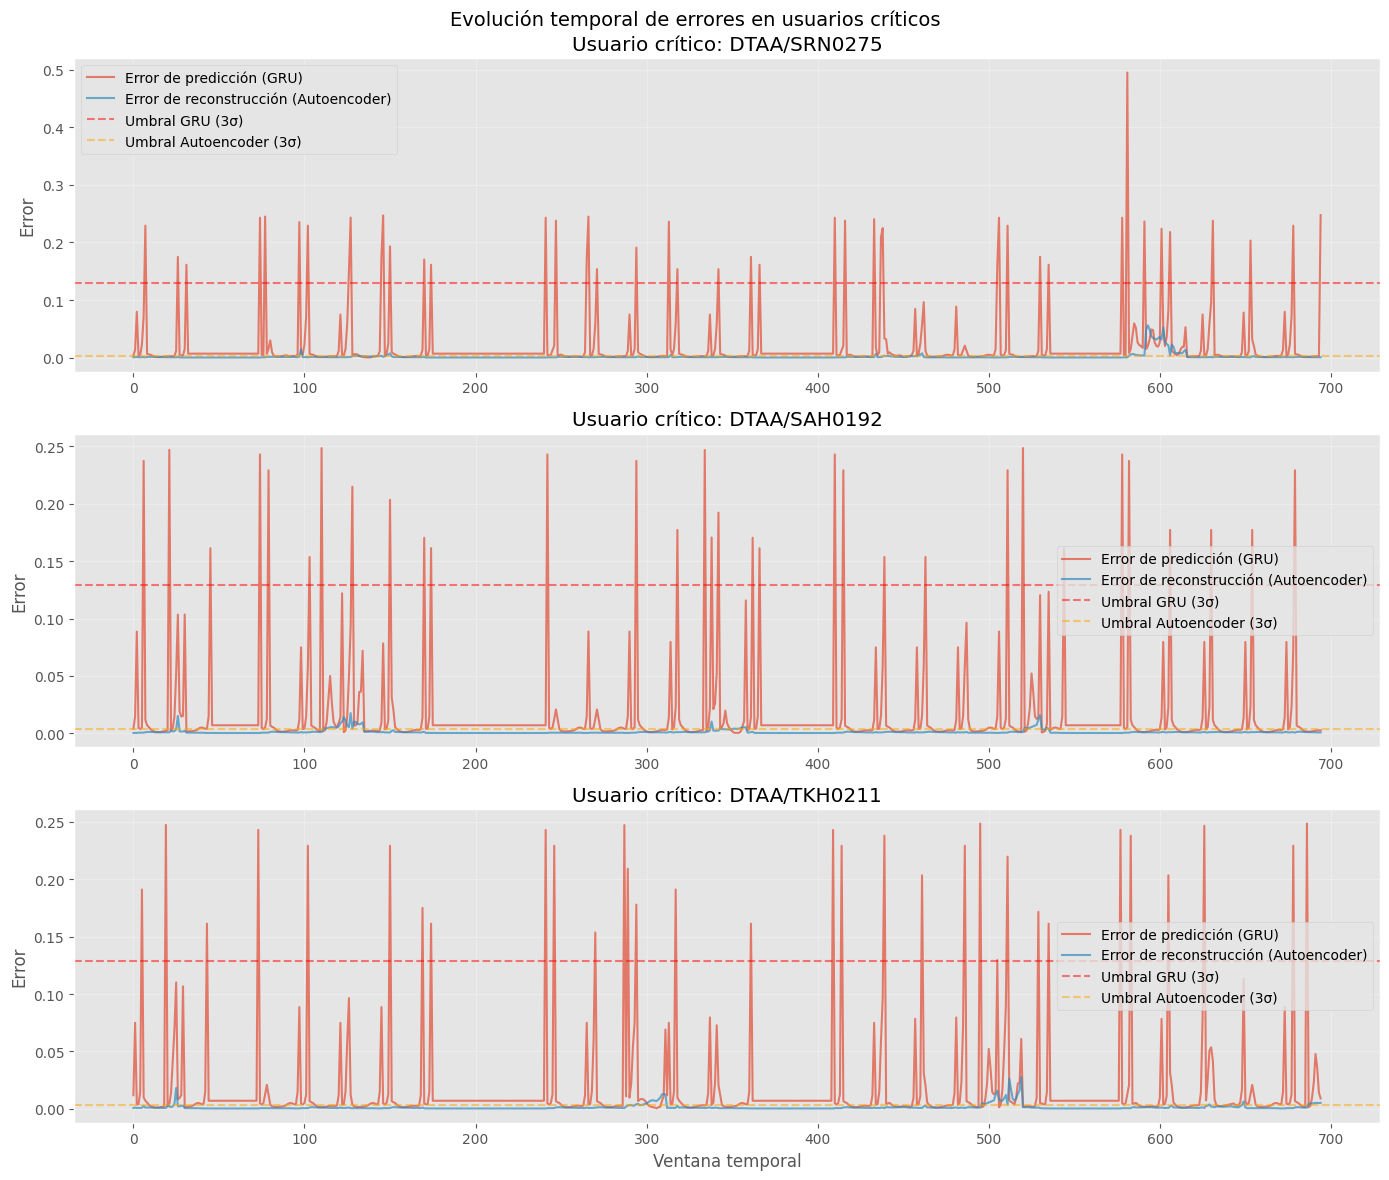

In [ ]:
# =========================================================
# ANÁLISIS DE CASOS ESPECÍFICOS DE ALTO RIESGO
# =========================================================

df_temporal = df.copy()
df_temporal['hour_of_day'] = df_temporal[time_col].dt.hour
df_temporal['is_weekend'] = df_temporal[time_col].dt.dayofweek >= 5

# Actividad nocturna: intervalo entre las 03:00 y las 06:00
night_activity = df_temporal[
    (df_temporal['hour_of_day'] >= 3) &
    (df_temporal['hour_of_day'] <= 6)
][user_col].value_counts()

# Actividad en fin de semana
weekend_activity = df_temporal[
    df_temporal['is_weekend'] == True
][user_col].value_counts()

print("Usuarios con mayor actividad nocturna (03:00–06:00):")
print(night_activity.head(10))

print("\nUsuarios con mayor actividad en fin de semana:")
print(weekend_activity.head(10))

# Cruce entre usuarios de alta actividad contextual y ranking de anomalía
night_anomalous = set(night_activity.head(20).index) & set(ranking.head(20).index)
weekend_anomalous = set(weekend_activity.head(20).index) & set(ranking.head(20).index)

print("\nUsuarios de alto riesgo con actividad nocturna y alta puntuación de anomalía:")
print(list(night_anomalous))

print("\nUsuarios de alto riesgo con actividad en fin de semana y alta puntuación de anomalía:")
print(list(weekend_anomalous))

# Selección de usuarios críticos para análisis visual
if night_anomalous or weekend_anomalous:
    critical_users = list(set(list(night_anomalous) + list(weekend_anomalous)))[:3]

    fig, axes = plt.subplots(len(critical_users), 1, figsize=(14, 4 * len(critical_users)))
    if len(critical_users) == 1:
        axes = [axes]

    for i, user in enumerate(critical_users):
        user_data = scores_df[scores_df['user'] == user]

        axes[i].plot(user_data['prediction_error'].values, label='Error de predicción (GRU)', alpha=0.7)
        axes[i].plot(user_data['reconstruction_error'].values, label='Error de reconstrucción (Autoencoder)', alpha=0.7)

        axes[i].axhline(
            threshold_gru_3sigma,
            color='red',
            linestyle='--',
            alpha=0.5,
            label='Umbral GRU (3σ)'
        )
        axes[i].axhline(
            threshold_ae_3sigma,
            color='orange',
            linestyle='--',
            alpha=0.5,
            label='Umbral Autoencoder (3σ)'
        )

        axes[i].set_title(f'Usuario crítico: {user}')
        axes[i].set_ylabel('Error')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel('Ventana temporal')
    plt.suptitle('Evolución temporal de errores en usuarios críticos', fontsize=14)
    plt.tight_layout()
    plt.show()

## 30. Dashboard final y análisis comparativo de modelos

En esta fase se integran los resultados obtenidos a lo largo del proceso analítico en un resumen estructurado que permite evaluar de forma conjunta el comportamiento del sistema UEBA. Para ello, se construye un conjunto de visualizaciones comparativas que facilitan la interpretación del rendimiento de los modelos y la caracterización global de las anomalías detectadas.

- **Distribución comparativa de errores:** se representan las distribuciones de los errores generados por los modelos de predicción (GRU) y reconstrucción (Autoencoder) mediante histogramas normalizados. Esta visualización permite analizar diferencias en la escala, dispersión y forma de ambas distribuciones, aportando información sobre la sensibilidad de cada enfoque ante comportamientos atípicos.

- **Relación entre errores de los modelos:** se emplea una representación bidimensional de los errores junto con el coeficiente de correlación de Pearson, con el fin de evaluar el grado de concordancia entre ambos modelos. Una alta correlación sugiere que ambos enfoques tienden a identificar patrones anómalos similares, mientras que valores más bajos pueden indicar complementariedad en la detección.

- **Ranking de usuarios con mayor nivel de anomalía:** se presenta un gráfico de barras correspondiente a los usuarios con mayor `anomaly_score`, permitiendo visualizar de forma directa los perfiles de mayor riesgo. Este resultado constituye uno de los principales outputs del sistema, orientado a la priorización de casos en entornos de análisis de seguridad.

- **Análisis por clusters:** se calcula el valor medio del score de anomalía en cada grupo identificado mediante técnicas de clustering. Esta representación permite caracterizar el nivel de riesgo asociado a cada perfil de usuario y comprender la estructura global del comportamiento dentro del sistema.

Resumen final del sistema UEBA
Usuarios analizados:                 942
Ventanas temporales (test):          130,938
Período analizado:                   30D
Ventana de observación:              24 horas

GRU — Anomalías (3σ):                3817
GRU — Anomalías (P99):               1285
LSTM — Anomalías (3σ):               3784
LSTM — Anomalías (P99):              1310
Autoencoder — Anomalías (3σ):        1172
Autoencoder — Anomalías (P99):       1310

Usuarios con anomalías:              189
Usuarios críticos (score > 5):       118


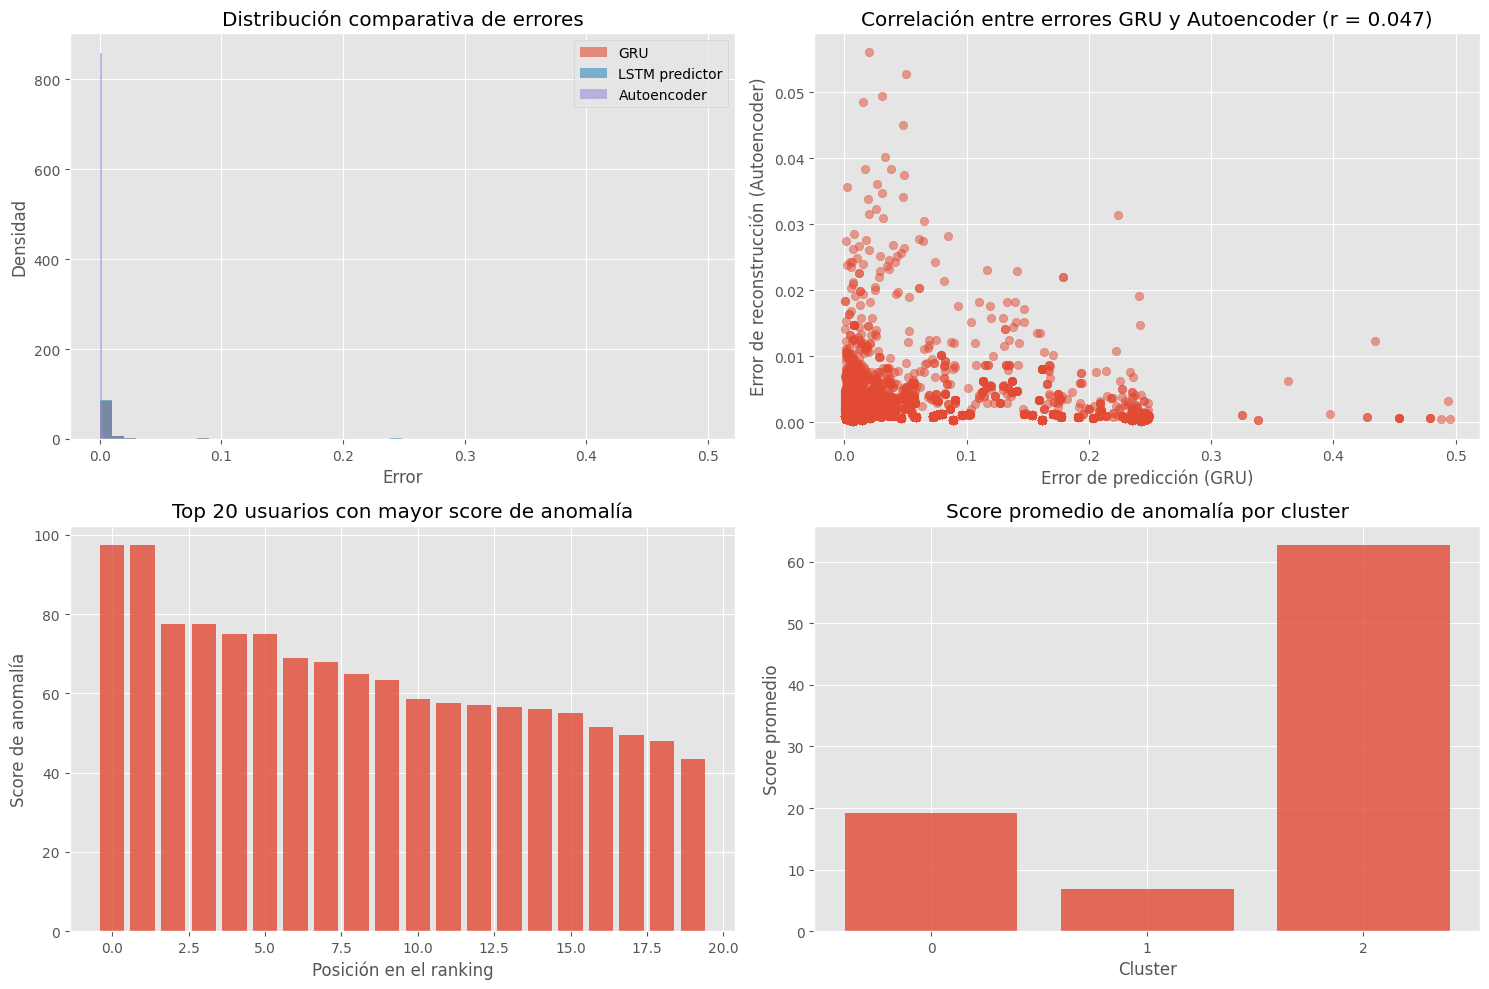


Análisis UEBA completado.


In [ ]:
print("Resumen final del sistema UEBA")
print("=" * 45)
print(f"Usuarios analizados:                 {len(user_series):,}")
print(f"Ventanas temporales (test):          {len(X_test):,}")
print(f"Período analizado:                   {RANGO}")
print(f"Ventana de observación:              {LOOKBACK} horas")

print(f"\nGRU — Anomalías (3σ):                {anomalies_gru_3sigma.sum()}")
print(f"GRU — Anomalías (P99):               {anomalies_gru_p99.sum()}")
print(f"LSTM — Anomalías (3σ):               {anomalies_lstm_3sigma.sum()}")
print(f"LSTM — Anomalías (P99):              {anomalies_lstm_p99.sum()}")
print(f"Autoencoder — Anomalías (3σ):        {anomalies_ae_3sigma.sum()}")
print(f"Autoencoder — Anomalías (P99):       {anomalies_ae_p99.sum()}")

print(f"\nUsuarios con anomalías:              {len(ranking[ranking['anomaly_score'] > 0])}")
print(f"Usuarios críticos (score > 5):       {len(ranking[ranking['anomaly_score'] > 5])}")

# Usar solo observaciones reales y alineadas
gru_errors_real = scores_df['prediction_error'].values
lstm_errors_real = prediction_errors_lstm
ae_errors_real = scores_df['reconstruction_error'].values

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# =========================================================
# Distribución comparativa de errores
# =========================================================
axes[0, 0].hist(gru_errors_real, bins=50, alpha=0.6, label='GRU', density=True)
axes[0, 0].hist(lstm_errors_real, bins=50, alpha=0.6, label='LSTM predictor', density=True)
axes[0, 0].hist(ae_errors_real, bins=50, alpha=0.6, label='Autoencoder', density=True)
axes[0, 0].set_title('Distribución comparativa de errores')
axes[0, 0].set_xlabel('Error')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].legend()

# =========================================================
# Correlación entre errores de GRU y Autoencoder
# =========================================================
correlation = np.corrcoef(gru_errors_real, ae_errors_real)[0, 1]
axes[0, 1].scatter(gru_errors_real, ae_errors_real, alpha=0.5)
axes[0, 1].set_title(f'Correlación entre errores GRU y Autoencoder (r = {correlation:.3f})')
axes[0, 1].set_xlabel('Error de predicción (GRU)')
axes[0, 1].set_ylabel('Error de reconstrucción (Autoencoder)')

# =========================================================
# Ranking de usuarios con mayor score de anomalía
# =========================================================
top_20 = ranking.head(20)
axes[1, 0].bar(range(len(top_20)), top_20['anomaly_score'], alpha=0.8)
axes[1, 0].set_title('Top 20 usuarios con mayor score de anomalía')
axes[1, 0].set_xlabel('Posición en el ranking')
axes[1, 0].set_ylabel('Score de anomalía')

# =========================================================
# Score promedio de anomalía por cluster
# =========================================================
cluster_metrics = ranking.groupby('cluster')['anomaly_score'].mean()
axes[1, 1].bar(cluster_metrics.index.astype(str), cluster_metrics.values, alpha=0.8)
axes[1, 1].set_title('Score promedio de anomalía por cluster')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Score promedio')

plt.tight_layout()
plt.show()

print("\nAnálisis UEBA completado.")

SE HA EXPORTADO EN HTML MEDIANTE EL SIGUIENTE CÓDIGO:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!jq -M 'del(.metadata.widgets)' '/content/drive/MyDrive/TFM/CODIGO_TFM_ADRIANRASERO_260524.ipynb' > 'CODIGO_TFM_ADRIANRASERO_260524.ipynb'
!jupyter nbconvert --to html '/content/CODIGO_TFM_ADRIANRASERO_260524.ipynb'

[NbConvertApp] Converting notebook /content/CODIGO_TFM_ADRIANRASERO_260524.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 25 image(s).
[NbConvertApp] Writing 4759389 bytes to /content/CODIGO_TFM_ADRIANRASERO_260524.html


In [ ]:
from google.colab import files
files.download('/content/CODIGO_TFM_ADRIANRASERO_260524.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>